In [1]:
from util.util import *
from util.param import *
from util.util import *
from util.util_montage import *

In [2]:
debug = False

In [3]:
# Hardcoded path for easier running
folder_path = "/Users/samm/Documents/Coding/github/RNA_SPT_in_cellular_condensates/data"
img_path = "/Users/samm/Documents/Coding/github/RNA_SPT_in_cellular_condensates/result/img"
result_path = "/Users/samm/Documents/Coding/github/RNA_SPT_in_cellular_condensates/result"

os.makedirs(img_path, exist_ok=True)

# Look up all subfolders in the data folder
subfolders = [f.path for f in os.scandir(folder_path) if f.is_dir()]
# Remove "archive" folder if it exists
subfolders = [f for f in subfolders if "archive" not in f]

subfolders.sort()  # Sort the subfolders alphabetically

print(f"Found {len(subfolders)} subfolders in the data folder.")
i = 0
for subfolder in subfolders:
    print(f"    {i}: {subfolder.split('/')[-1]}")
    i += 1

Found 10 subfolders in the data folder.
    0: 2x_4EGI1
    1: 2x_CHX
    2: 2x_Har
    3: 2x_puro
    4: THOR_1x
    5: THOR_2x
    6: THORdel_2x
    7: THORdelta_1x
    8: mRNA-1x
    9: mRNA_2x


In [4]:
# Change this index to select different subfolders
index = 9
legend_bool = True

data_path = subfolders[index]
data_name = data_path.split("/")[-1]
print(f"Selected data for {data_name} in folder: {data_path}")

Selected data for mRNA_2x in folder: /Users/samm/Documents/Coding/github/RNA_SPT_in_cellular_condensates/data/mRNA_2x


In [5]:
file_pairs = find_matching_files(data_path)

if not file_pairs:
    if debug:
        print("❌ No matching file pairs found!")
    pass
else:
    if debug:
        print(f"📂 Loading {len(file_pairs)} experiment datasets...")
    
    all_tracks = []
    all_condensates = []
    
    for rna_path, condensate_path, exp_name in track(file_pairs, description="Loading datasets"):
        df_tracks, df_condensates = load_dataset_pair(rna_path, condensate_path, exp_name)
        
        if df_tracks is not None and df_condensates is not None:
            all_tracks.append(df_tracks)
            all_condensates.append(df_condensates)
    
    if all_tracks and all_condensates:
        # Combine all datasets
        df_tracks_combined = pd.concat(all_tracks, ignore_index=True)
        df_condensates_combined = pd.concat(all_condensates, ignore_index=True)

        if debug:
            print(f"✅ Successfully loaded and combined:")
            print(f"   - {len(df_tracks_combined)} total track points")
            print(f"   - {len(df_condensates_combined)} total condensate entries")
            print(f"   - {df_tracks_combined['experiment'].nunique()} experiments")

        # Display summary statistics
        if debug:
            print("\n📊 Dataset Summary:")
        for exp in df_tracks_combined['experiment'].unique():
            exp_tracks = df_tracks_combined[df_tracks_combined['experiment'] == exp]
            exp_condensates = df_condensates_combined[df_condensates_combined['experiment'] == exp]
            if debug:
                print(f"   {exp}: {exp_tracks['trackID'].nunique()} tracks, "
                      f"{len(exp_condensates)} condensate entries")
    else:
        if debug:
            print("❌ No valid datasets were loaded successfully")
        pass

if debug:
    print("\n🎉 Data loading complete!")

Output()

## Minimum distance calculation from RNA to the boundary of condensates

In [6]:
print("🔄 Calculating distances from RNA to condensate boundaries...")

from shapely.geometry import Point, Polygon
from shapely.strtree import STRtree

### Optimized distance calculation using spatial index
# Prepare output records
records = []

output_csv = os.path.join(result_path, f"{data_name}_rna_condensate_distances.csv")

# Check if output CSV already exists
if os.path.exists(output_csv):
    print(f"⚠️ Output CSV '{output_csv}' already exists. Skipping distance calculation to avoid overwriting.")
    df_distances = pd.read_csv(output_csv)
else:
    if df_tracks_combined.empty or df_condensates_combined.empty:
        print("❌ Combined datasets are empty. Skipping distance calculation.")
    else:
        # Process each experiment separately
        unique_experiments = df_tracks_combined['experiment'].unique()
        print(f"  • Found {len(unique_experiments)} unique experiments to process.")
        n = 0
        for exp in unique_experiments:
            print(f"  • Processing experiment: {exp} ({n + 1}/{len(unique_experiments)})")
            n += 1
            # Filter condensates for the current experiment once
            condensates_exp = df_condensates_combined[df_condensates_combined['experiment'] == exp]
            condensates_by_frame = condensates_exp.groupby('frame')['contour_coord'].apply(list).to_dict()

            # Get all track data for the current experiment
            tracks_exp = df_tracks_combined[df_tracks_combined['experiment'] == exp]
            
            # Iterate through each frame that has condensates
            for frame, contour_list in tqdm(condensates_by_frame.items(), desc=f"    ↳ {exp}"):
                
                # 1. PRE-PROCESS AND CLEAN POLYGONS for the current frame
                shapely_polygons = []
                for cnt_str in contour_list:
                    bx, by = parse_contour_string(cnt_str)
                    if len(bx) >= 3:  # A valid polygon needs at least 3 vertices
                        # Create the polygon
                        poly = Polygon(zip(bx, by))
                        
                        # Clean the polygon of any self-intersections or other invalid topology.
                        # If the polygon is already valid, this has no negative effect.
                        if not poly.is_valid:
                            poly = poly.buffer(0)

                        # Only add non-empty polygons to the list
                        if not poly.is_empty:
                            shapely_polygons.append(poly)

                # If no valid polygons could be created for this frame, skip
                if not shapely_polygons:
                    continue
                
                # 2. BUILD SPATIAL INDEX
                # This index is incredibly fast to build and query
                spatial_index = STRtree(shapely_polygons)
                
                # Get all points (tracks) for the current frame
                try:
                    # Note: Your original 't' seems to be frame number
                    tracks_in_frame = tracks_exp[tracks_exp['t'] == frame]
                except KeyError:
                    continue

                # 3. QUERY & CALCULATE SIGNED DISTANCE EFFICIENTLY
                for idx, row in tracks_in_frame.iterrows():
                    point = Point(row['x'], row['y'])
                                
                    # 1. The query returns the *index* of the nearest polygon in the list.
                    nearest_poly_index = spatial_index.nearest(point)
                    
                    # 2. Use the index to get the actual polygon object from your list.
                    if nearest_poly_index is not None:
                        nearest_poly = shapely_polygons[nearest_poly_index]
                    else:
                        continue # Skip if no polygon was found

                    # 3. Calculate the signed distance.
                    # First, get the raw distance to the polygon's boundary (always positive).
                    min_dist = point.distance(nearest_poly.boundary)
                    
                    # Next, check if the point is inside the polygon.
                    if nearest_poly.contains(point):
                        # If it's inside, make the distance negative.
                        min_dist = -min_dist
                    
                    # Convert to desired units
                    dist_um = min_dist * um_per_pixel
                    
                    records.append({
                        'experiment': exp,
                        'trackID': row['trackID'],
                        't': frame * s_per_frame,
                        'distance_um': dist_um
                    })

    # Create DataFrame and save
    df_distances = pd.DataFrame(records)
    df_distances.to_csv(output_csv, index=False)
    print(f"✅ Saved distances to: {output_csv}")

print("🔄 Generating distance vs. time plots...")

# Load distances if not in memory
try:
    df_distances = df_distances
except NameError:
    df_distances = pd.read_csv(os.path.join(result_path, "rna_condensate_distances.csv"))

# Identify first dwell per track per experiment
first_dwell = df_distances[df_distances['distance_um'] == 0] \
    .groupby(['experiment', 'trackID'])['t'] \
    .min() \
    .reset_index() \
    .rename(columns={'t': 't_dwell'})

print(f"  • Found {len(first_dwell)} first-dwell events across all experiments")

# Merge dwell times back into distances
df_plot = df_distances.merge(first_dwell, on=['experiment', 'trackID'], how='left')

# Keep only points at and after first dwell
df_plot = df_plot[df_plot['t'] >= df_plot['t_dwell']]

print("🔄 Generating distance vs. time plots for each experiment...")

# Load distances if not in memory
try:
    df_distances = df_distances
except NameError:
    df_distances = pd.read_csv(os.path.join(result_path, "rna_condensate_distances.csv"))

# Identify first dwell per track per experiment
first_dwell = df_distances[df_distances['distance_um'] <= 0] \
    .groupby(['experiment', 'trackID'])['t'] \
    .min() \
    .reset_index() \
    .rename(columns={'t': 't_dwell'})

print(f"  • Found {len(first_dwell)} first-dwell events across all experiments")

# Merge dwell times back into distances
df_plot = df_distances.merge(first_dwell, on=['experiment', 'trackID'], how='left')
# Keep only points at and after first dwell
df_plot = df_plot[df_plot['t'] >= df_plot['t_dwell']]

🔄 Calculating distances from RNA to condensate boundaries...
⚠️ Output CSV '/Users/samm/Documents/Coding/github/RNA_SPT_in_cellular_condensates/result/mRNA_2x_rna_condensate_distances.csv' already exists. Skipping distance calculation to avoid overwriting.
🔄 Generating distance vs. time plots...
  • Found 332 first-dwell events across all experiments
🔄 Generating distance vs. time plots for each experiment...
  • Found 8724 first-dwell events across all experiments


In [7]:
# Create separate plot for each experiment
experiments = df_plot['experiment'].unique()
print(f"  • Creating {len(experiments)} separate plots...")

from scipy.signal import find_peaks # For peak detection

df_filtered = pd.DataFrame()  # To collect tracks with peak detection errors
df_error = pd.DataFrame()  # To collect tracks with peak detection errors
df_outlier = pd.DataFrame()  # To collect tracks with peak detection errors

# Maximum jump per frame is 4 pixel frames 
max_jump = 4 * um_per_pixel / s_per_frame

error_count = 0
for exp in experiments:
    print(f"    → Processing experiment: {exp}")
    
    # Filter data for this experiment
    exp_data = df_plot[df_plot['experiment'] == exp]
    
    if exp_data.empty:
        print(f"      ⚠️ No dwell data found for {exp}, skipping...")
        continue
    
    # Create figure for this experiment
    fig, ax = plt.subplots(2, 1, figsize=(10, 14))
    
    track_count = 0
    # Plot each track in this experiment
    for track in np.sort(exp_data['trackID'].unique()):
        # if track_count >= 10:
        #     print(f"      ⚠️ More than 10 tracks in {exp}, limiting to first 10 for clarity.")
        #     break
        print(f"      • Plotting track {int(track)}...", end="\r")
        track_data = exp_data[exp_data['trackID'] == track]
        
        # Use find_peaks to highlight peaks with huge prominence
        x = np.array(track_data['t'] - track_data['t_dwell'])
        y = np.array(track_data['distance_um'])
        
        dx = np.diff(x)
        dy = np.diff(y)
        # Calculate derivative (dy/dx)
        derivative = dy / dx
        
        # Use find_peaks to highlight peaks with huge prominence
        try:
            peaks, _ = find_peaks(y,
                                  height=0.4, # only consider peaks above 0.4 um (arbitrary)
                                  prominence=0.7) # only consider peaks with at least 0.7 um prominence (arbitrary)
            # ax.plot(x[peaks], y[peaks], "x", color='red')
            # Continue to the next track if peak is found
            if len(peaks) >= 1:
                error_count += 1
                df_error = pd.concat([df_error, track_data], ignore_index=True)
                continue

        except Exception as e:
            print(f"      ❌ Error finding peaks for track {track} in {exp}: {e}")
            pass
        
        # Use different colors for better visibility
        ax[0].plot(x, y,
                alpha=0.5,
                linewidth=1.5,
                label=f"Track {int(track)}")

        ax[0].scatter(x, y,
                   s=10,
                   alpha=0.7,
                   zorder=10)

        # Plot the derivative if it exists
        if 'derivative' in locals():
            ax[1].plot(x[:-1], derivative, alpha=0.5, linewidth=1.5, label=f"Track {int(track)}")
            
            if any(abs(derivative) > max_jump):
                df_outlier = pd.concat([df_outlier, track_data], ignore_index=True)
        
        df_filtered = pd.concat([df_filtered, track_data], ignore_index=True)
        track_count += 1
    
    ax[0].axhline(0, color='gray', linestyle='--', linewidth=1, zorder=12)
    
    ax[1].axhline(max_jump, color='orange', linestyle='--', linewidth=1, zorder=12)
    ax[1].axhline(-max_jump, color='orange', linestyle='--', linewidth=1, zorder=12)

    ax[0].set_xlabel("")
    ax[0].set_ylabel("Distance to condensate boundary (μm)", fontsize=12, fontweight='bold')
    ax[0].tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
    
    ax[1].set_xlabel("Time since first dwell (s)", fontsize=12, fontweight='bold')
    ax[1].set_ylabel("Distance Derivative (μm/s)", fontsize=12, fontweight='bold')
    
    
    ax[0].set_title(f"RNA Distance from Condensate Boundary Over Time\n{exp} ({track_count} tracks)", 
                fontsize=14, fontweight='bold')
    ax[0].grid(True, linestyle='--', alpha=0.3)

    # # Add legend with reasonable limit
    # max_legend_entries = 15
    # if track_count <= max_legend_entries:
    #     ax[0].legend(fontsize=9, ncol=2, loc='upper right', framealpha=0.9)
    # else:
    #     print(f"      ⚠️ Too many tracks ({track_count}) for legend in {exp}")
    
    # Add summary statistics as text box
    max_dist = exp_data['distance_um'].max()
    mean_dist = exp_data['distance_um'].mean()
    textstr = f'Max distance: {max_dist:.2f} μm\nMean distance: {mean_dist:.2f} μm'
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
    
    ax[0].text(0.02, 0.98, textstr, transform=ax[0].transAxes, fontsize=10, verticalalignment='top', bbox=props)
    
    plt.tight_layout()
    
    # Save with experiment-specific filename
    safe_exp_name = exp.replace(" ", "_").replace("/", "_").replace("\\", "_")
    output_png = os.path.join(img_path, f"distance_vs_time_{safe_exp_name}.png")
    fig.savefig(output_png, dpi=300, bbox_inches='tight')
    print(f"      ✅ Saved: distance_vs_time_{safe_exp_name}.png")
    
    # plt.show()
    plt.close()  # Close to free memory

  • Creating 26 separate plots...
    → Processing experiment: 20220508-FLmRNA_2x_FOV-17
      ✅ Saved: distance_vs_time_20220508-FLmRNA_2x_FOV-17.png
    → Processing experiment: 20220508-FLmRNA_2x_FOV-5
      ✅ Saved: distance_vs_time_20220508-FLmRNA_2x_FOV-5.png
    → Processing experiment: 20220508-FLmRNA_2x_FOV-25
      ✅ Saved: distance_vs_time_20220508-FLmRNA_2x_FOV-25.png
    → Processing experiment: 20220508-FLmRNA_2x_FOV-15
      ✅ Saved: distance_vs_time_20220508-FLmRNA_2x_FOV-15.png
    → Processing experiment: 20220508-FLmRNA_2x_FOV-7
      ✅ Saved: distance_vs_time_20220508-FLmRNA_2x_FOV-7.png
    → Processing experiment: 20220508-FLmRNA_2x_FOV-1
      ✅ Saved: distance_vs_time_20220508-FLmRNA_2x_FOV-1.png
    → Processing experiment: 20220508-FLmRNA_2x_FOV-21
      ✅ Saved: distance_vs_time_20220508-FLmRNA_2x_FOV-21.png
    → Processing experiment: 20220508-FLmRNA_2x_FOV-9
      ✅ Saved: distance_vs_time_20220508-FLmRNA_2x_FOV-9.png
    → Processing experiment: 20220508-

In [8]:
# ### Added section to create a separate plot for tracks with peak detection errors
# # Create the plot for tracks with peak detection errors
# if not df_error.empty:
#     fig, ax = plt.subplots(figsize=(10, 7))
    
#     for exp in df_error['experiment'].unique():
#         exp_data = df_error[df_error['experiment'] == exp]
#         for track in exp_data['trackID'].unique():
#             track_data = exp_data[exp_data['trackID'] == track]
#             x = np.array(track_data['t'] - track_data['t_dwell'])
#             y = np.array(track_data['distance_um'])
#             ax.plot(x, y,
#                     alpha=0.5,
#                     linewidth=1.5)

#     ax.set_xlabel("Time since first dwell (s)", fontsize=12, fontweight='bold')
#     ax.set_ylabel("Distance to condensate boundary (μm)", fontsize=12, fontweight='bold')
#     ax.set_title(f"RNA Distance from Condensate Boundary Over Time\n(Tracks with Peak Detection Errors)", 
#                 fontsize=14, fontweight='bold')
#     ax.grid(True, linestyle='--', alpha=0.3)
    
#     plt.tight_layout()

#     # Use a safe experiment name for the error plot
#     error_exp_names = "_".join([str(e).replace(" ", "_").replace("/", "_").replace("\\", "_") for e in df_error['experiment'].unique()])
#     error_output_png_filename = f"peak_detection_errors_{error_exp_names}.png"
#     output_png = os.path.join(img_path, error_output_png_filename)
#     fig.savefig(output_png, dpi=300, bbox_inches='tight')
#     print(f"      ✅ Saved: {error_output_png_filename}")

#     # plt.show()
#     plt.close()  # Close to free memory

In [9]:
if not df_outlier.empty:
    n_outliers = df_outlier['trackID'].nunique()
    print(f"🔔 Found {n_outliers} tracks with outlier jumps exceeding {max_jump} μm.")

🔔 Found 261 tracks with outlier jumps exceeding 4.68 μm.


In [10]:
def plot_trajectory_snapshots(df_tracks,
                                exp_results,
                                trace_df,
                                t_max=3,
                                title=None,
                                save_path=None,
                                um_per_pixel=0.1,  # Conversion factor
                                window_size_um=5,  # Desired window size in micrometers
                                scale_bar_um=1,
                                gradient_color=False
                                ):   # Desired scale bar length in micrometers
    """
    Creates a single, zoomed-in snapshot for one RNA track interacting with one condensate.

    This function is designed to plot a single interaction event, assuming the input
    DataFrames are pre-filtered for one specific track and one specific condensate.

    Parameters:
    - df_tracks (pd.DataFrame): DataFrame containing the track data.
    - exp_results (dict): A dictionary with metadata for the event.
    - save_path (str): The full file path to save the snapshot.
    - um_per_pixel (float): Conversion factor from micrometers to pixels.
    - window_size_um (float): The fixed size of the square zoom window in micrometers.
    - scale_bar_um (float): The length of the scale bar in micrometers.
    """
    # Parameters for the figure layout
    window_size_px = window_size_um / um_per_pixel  # Convert window size to pixels

    exp, result = list(exp_results.items())[0]
    num_col = 2
    print(f"Length of exp_results: {num_col}")
    experiment = list(exp_results.keys())[0]
    final_frame = result['final_frame']
    contour_boundaries = result['contour_boundaries']
    interacting_tracks = result['interacting_tracks']

    if not interacting_tracks:
        print(f"❌ No interacting tracks found for {experiment}, skipping snapshot.")
        return
    
    for track_id in interacting_tracks:
        track_data = df_tracks[
            (df_tracks['trackID'] == track_id) & 
            (df_tracks['t'] <= final_frame)
        ].sort_values('t')
        
        if len(track_data) < 2:
            print(f"⚠️ Track {track_id} has insufficient data points, skipping.")
            continue
        
        # Find the closest condensate for this track
        closest_condensate = None
        min_distance = float('inf')
        
        for cx, cy in contour_boundaries:
            for _, point in track_data.iterrows():
                distances = np.sqrt((cx - point['x'])**2 + (cy - point['y'])**2)
                if np.any(distances < min_distance):
                    min_distance = np.min(distances)
                    closest_condensate = (cx, cy)
        
        if closest_condensate is None:
            print(f"⚠️ No condensate found for track {track_id}, skipping.")
            continue
        
        cx, cy = closest_condensate
        
        # Calculate the center of the combined bounding box of the track and condensate
        min_x_cond, max_x_cond = np.min(cx), np.max(cx)
        min_y_cond, max_y_cond = np.min(cy), np.max(cy)
        
        min_x_track, max_x_track = track_data['x'].min(), track_data['x'].max()
        min_y_track, max_y_track = track_data['y'].min(), track_data['y'].max()
        
        center_x = (min(min_x_cond, min_x_track) + max(max_x_cond, max_x_track)) / 2
        center_y = (min(min_y_cond, min_y_track) + max(max_y_cond, max_y_track)) / 2
        
        # Set up a fixed-size zoom window in pixels
        half_window_px = window_size_px / 2
        zoom_xmin = int(center_x - half_window_px)
        zoom_xmax = int(center_x + half_window_px)
        zoom_ymin = int(center_y - half_window_px)
        zoom_ymax = int(center_y + half_window_px)
        
        if gradient_color:
            color_map = plt.get_cmap('viridis')
            max_time = 20  
            num_points = max_time * 10  # 10 fps for max_time seconds
            frame_colors = [color_map(i / (num_points - 1)) for i in range(num_points)]
        
        num_points_track = len(track_data)
        num_points_trace = len(trace_df)
        if num_points_track != num_points_trace:
            print(f"⚠️ Mismatch in number of points: track_data has {num_points_track}, trace_df has {num_points_trace}")
        
        # Create figure
        fig, ax = plt.subplots(1, num_col, figsize=(num_col*4, 4))
        
        # Plot condensate boundary
        ax[0].plot(cx, cy, lw=3, c="#2E86AB", alpha=0.9)
        ax[0].plot([cx[-1], cx[0]], [cy[-1], cy[0]], c="#2E86AB", lw=3, alpha=0.9)
        
        # Plot interacting track
        if gradient_color:
            num_points = len(track_data)
            for i in range(num_points - 1):
                frame = int(track_data['t'].iloc[i])
                # Safeguard against index out of range
                if frame <= len(frame_colors):
                    ax[0].plot(track_data['x'].iloc[i:i+2], track_data['y'].iloc[i:i+2], lw=2, c=frame_colors[frame-1], alpha=0.8)
                else:
                    # If frame is out of range, use the last available color
                    ax[0].plot(track_data['x'].iloc[i:i+2], track_data['y'].iloc[i:i+2], lw=2, c=frame_colors[-1], alpha=0.8)
            
            first_frame = int(track_data['t'].iloc[0])
            final_frame = int(track_data['t'].iloc[-1])

            ax[0].plot(track_data.iloc[0]['x'], track_data.iloc[0]['y'], marker='o', markersize=6, color=frame_colors[first_frame-1], markerfacecolor='white', markeredgewidth=2)
            ax[0].plot(track_data.iloc[-1]['x'], track_data.iloc[-1]['y'], marker='s', markersize=5, color=frame_colors[final_frame-1], markerfacecolor=frame_colors[final_frame-1], markeredgewidth=1, alpha=0.8)

        else:
            ax[0].plot(track_data['x'], track_data['y'], lw=2, c="#F24236", alpha=0.8)
            ax[0].plot(track_data.iloc[0]['x'], track_data.iloc[0]['y'], marker='o', markersize=6, color="#D35400", markerfacecolor='white', markeredgewidth=2)
            ax[0].plot(track_data.iloc[-1]['x'], track_data.iloc[-1]['y'], marker='s', markersize=5, color="#D35400", markerfacecolor="#D35400", markeredgewidth=1, alpha=0.8)
        
        # Plot the trajectory after first dwell
        first_dwell_time = trace_df['t_original'].iloc[0]
        print(f"First dwell time: {first_dwell_time}, until {first_dwell_time + t_max}")
        print(f"First time point int track_data: {track_data['t'].iloc[0]}")
        post_dwell_data = track_data[(track_data['t'] >= first_dwell_time * 10) & (track_data['t'] < (first_dwell_time + t_max) * 10)] # Convert to frame number assuming 10 fps

        if gradient_color is False:
            if not post_dwell_data.empty:
                ax[0].plot(post_dwell_data['x'], post_dwell_data['y'], lw=2, c='tab:green', alpha=0.8, zorder=12)
                ax[0].plot(post_dwell_data.iloc[0]['x'], post_dwell_data.iloc[0]['y'], marker='o', markersize=6, color='tab:green', markerfacecolor='white', markeredgewidth=2, zorder=13)
                ax[0].plot(post_dwell_data.iloc[-1]['x'], post_dwell_data.iloc[-1]['y'], marker='s', markersize=5, color='tab:green', markerfacecolor='tab:blue', markeredgewidth=1, alpha=0.8, zorder=13)

        # Add scale bar
        scale_bar_length_px = scale_bar_um / um_per_pixel
        scale_bar_x_start = zoom_xmax - (0.5 * window_size_px)  # Position 5% from left
        scale_bar_y = zoom_ymin + (0.05 * window_size_px)   # Position 5% from top
        ax[0].plot([scale_bar_x_start, scale_bar_x_start + scale_bar_length_px], [scale_bar_y, scale_bar_y], lw=7, c="black")
        # ax[0].text(scale_bar_x_start + scale_bar_length_px / 2, scale_bar_y - (0.075 * window_size_px), f"{scale_bar_um} μm", fontsize=12, ha='center', color='black')

        # Set zoom limitss
        ax[0].set_xlim(zoom_xmin, zoom_xmax)
        ax[0].set_ylim(zoom_ymin, zoom_ymax)
        ax[0].set_aspect('equal', adjustable='box')
        ax[0].axis('off')
        
        
        # Plot the trajectory distance
        if gradient_color:
            color_map = plt.get_cmap('viridis')
            num_points = len(trace_df)
            for i in range(num_points - 1):
                frame = int(trace_df['t'].iloc[i]*10)
                # Safeguard against index out of range
                if frame <= len(frame_colors):
                    ax[1].plot(trace_df['t'].iloc[i:i+2], trace_df['distance_um'].iloc[i:i+2], lw=2, c=frame_colors[frame-1], alpha=0.8)
                else:
                    # If frame is out of range, use the last available color
                    ax[1].plot(trace_df['t'].iloc[i:i+2], trace_df['distance_um'].iloc[i:i+2], lw=2, c=frame_colors[-1], alpha=0.8)
        else:
            ax[1].plot(trace_df['t'], trace_df['distance_um'], lw=2, c='grey', alpha=0.8)
        ax[1].set_xlabel("Time (s)", fontsize=12)
        ax[1].set_ylabel("Distance (μm)", fontsize=12)
        ax[1].tick_params(axis='both', which='major', labelsize=10)
        ax[1].axhline(y=0, color='gray', linestyle='--', lw=1)
        
        ax[1].set_xlim(0, trace_df['t'].max())
        ax[1].set_yticks(np.arange(-0.5, 0.6, 0.2))

        if title is not None:
            fig.suptitle(title, fontsize=16)

        plt.tight_layout()
        if save_path is not None:
            plt.savefig(save_path, dpi=300, bbox_inches='tight', transparent=True)
        plt.show()

      ✅ Saved: outliers_20220508-FLmRNA_2x_FOV-1_20220508-FLmRNA_2x_FOV-15_20220508-FLmRNA_2x_FOV-17_20220508-FLmRNA_2x_FOV-21_20220508-FLmRNA_2x_FOV-25_20220508-FLmRNA_2x_FOV-5_20220508-FLmRNA_2x_FOV-7_20220508-FLmRNA_2x_FOV-9_part_1.png
      ✅ Saved: outliers_20220508-FLmRNA_2x_FOV_20220508-FLmRNA_2x_FOV-13_20220508-FLmRNA_2x_FOV-19_20220508-FLmRNA_2x_FOV-3_20220508-FLmRNA_2x_FOV-9_part_2.png
      ✅ Saved: outliers_20220508-FLmRNA_2x_FOV-11_20220508-FLmRNA_2x_FOV-23_20220508-FLmRNA_2x_FOV-24_20220508-FLmRNA_2x_FOV-3_part_3.png
      ✅ Saved: outliers_20220508-FLmRNA_2x_FOV-16_20220508-FLmRNA_2x_FOV-24_20220508-FLmRNA_2x_FOV-4_20220508-FLmRNA_2x_FOV-6_part_4.png
      ✅ Saved: outliers_20220508-FLmRNA_2x_FOV-10_20220508-FLmRNA_2x_FOV-12_20220508-FLmRNA_2x_FOV-14_20220508-FLmRNA_2x_FOV-18_20220508-FLmRNA_2x_FOV-20_20220508-FLmRNA_2x_FOV-6_20220508-FLmRNA_2x_FOV-8_part_5.png
      ✅ Saved: outliers_20220508-FLmRNA_2x_FOV-18_20220508-FLmRNA_2x_FOV-2_20220508-FLmRNA_2x_FOV-22_part_6.png

/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 198, trace_df has 181
First dwell time: 1.7000000000000002, until 4.7
First time point int track_data: 0


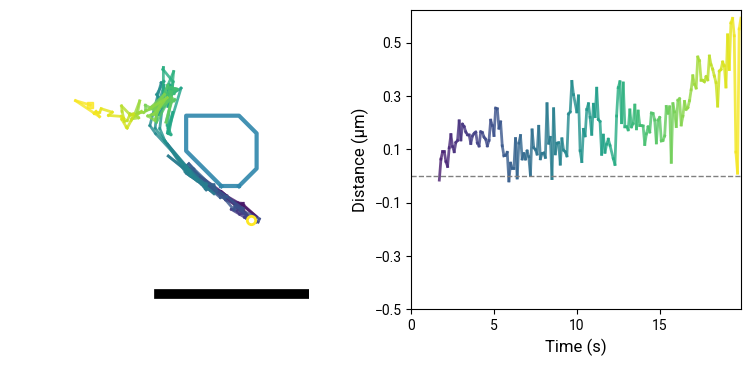

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-17_track_332.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-17, Track ID: 1800
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-17
    ✅ 1/1 tracks interacting with 749 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


First dwell time: 6.5, until 9.5
First time point int track_data: 65


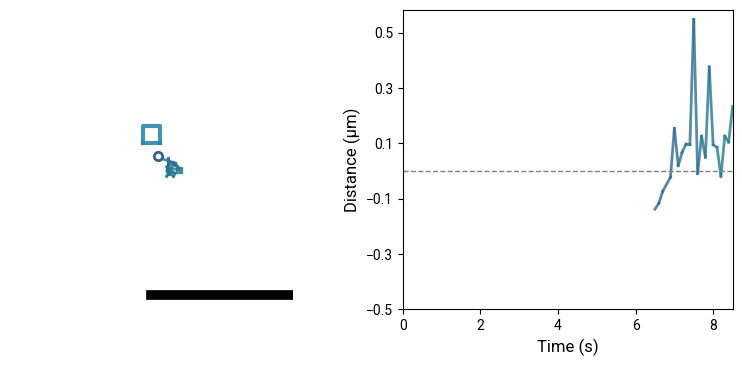

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-17_track_1800.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-17, Track ID: 2169
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-17
    ✅ 1/1 tracks interacting with 749 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 118, trace_df has 117
First dwell time: 8.200000000000001, until 11.200000000000001
First time point int track_data: 81


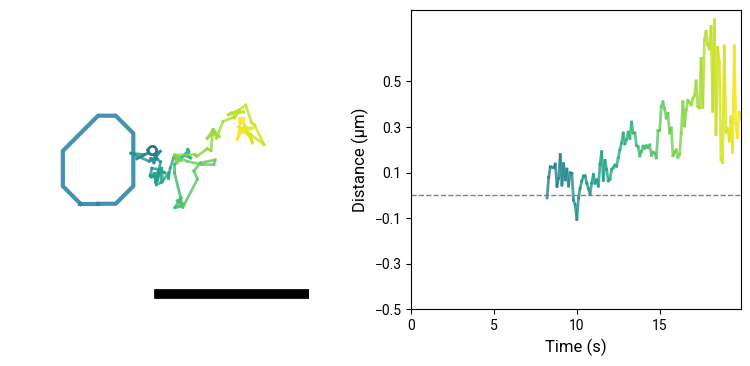

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-17_track_2169.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-17, Track ID: 3946
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-17
    ✅ 1/1 tracks interacting with 749 condensates
Length of exp_results: 2
⚠️ Mismatch in number of points: track_data has 8, trace_df has 6
First dwell time: 17.400000000000002, until 20.400000000000002
First time point int track_data: 172


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


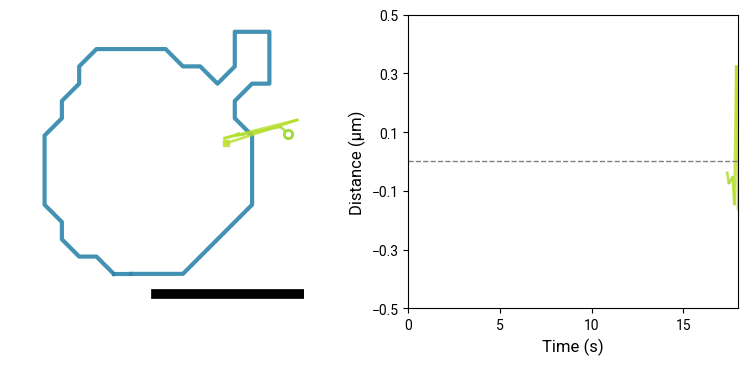

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-17_track_3946.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-5, Track ID: 399
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-5
    ✅ 1/1 tracks interacting with 594 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 51, trace_df has 41
First dwell time: 1.0, until 4.0
First time point int track_data: 0


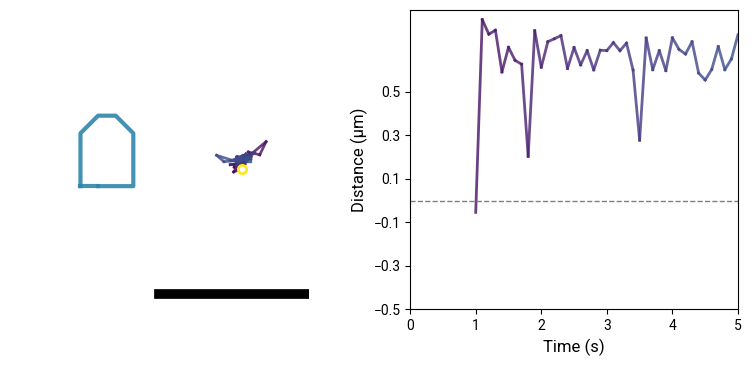

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-5_track_399.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-5, Track ID: 617
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-5
    ✅ 1/1 tracks interacting with 598 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


First dwell time: 0.0, until 3.0
First time point int track_data: 0


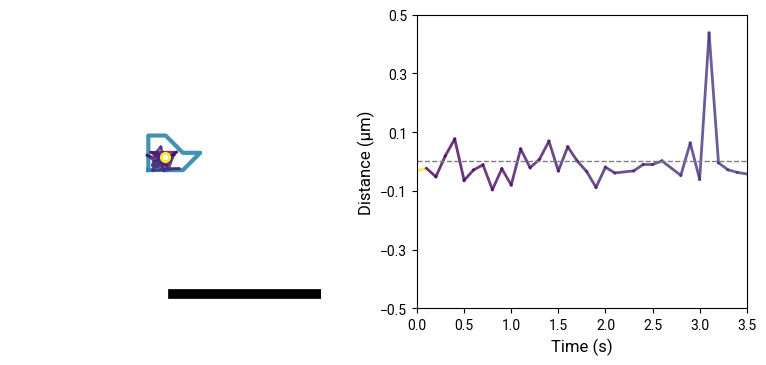

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-5_track_617.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-5, Track ID: 3358
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-5
    ✅ 1/1 tracks interacting with 583 condensates
Length of exp_results: 2
⚠️ Mismatch in number of points: track_data has 19, trace_df has 12


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


First dwell time: 10.0, until 13.0
First time point int track_data: 93


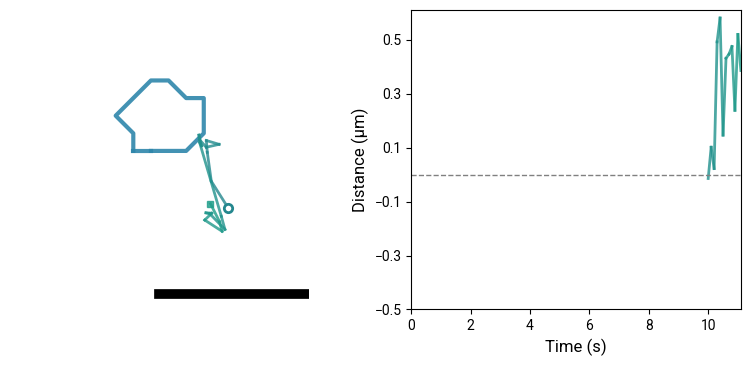

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-5_track_3358.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-25, Track ID: 220
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-25
    ✅ 1/1 tracks interacting with 706 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 200, trace_df has 180
First dwell time: 2.0, until 5.0
First time point int track_data: 0


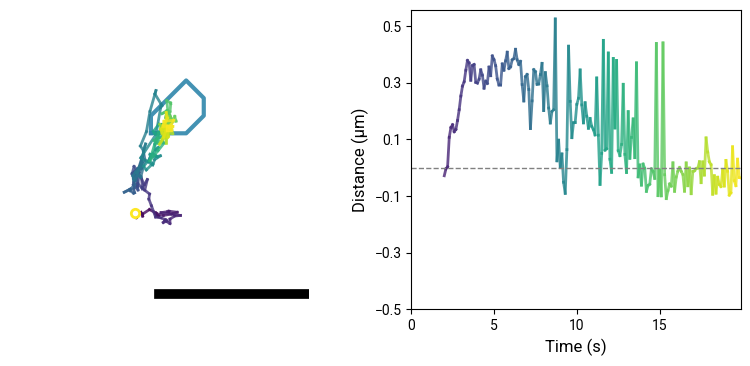

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-25_track_220.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-25, Track ID: 354
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-25
    ✅ 1/1 tracks interacting with 706 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 200, trace_df has 191
First dwell time: 0.9, until 3.9
First time point int track_data: 0


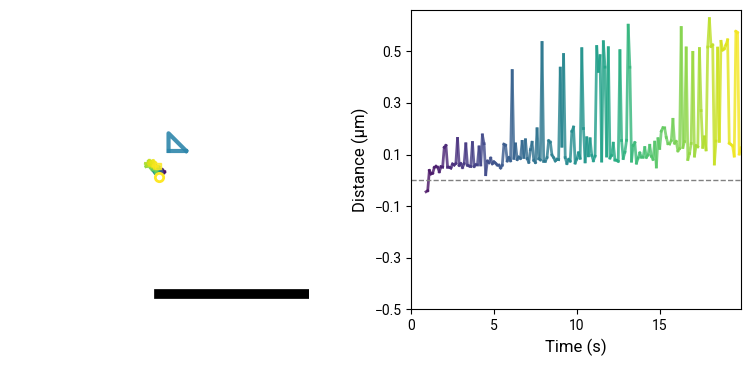

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-25_track_354.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-25, Track ID: 588
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-25
    ✅ 1/1 tracks interacting with 706 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


First dwell time: 0.0, until 3.0
First time point int track_data: 0


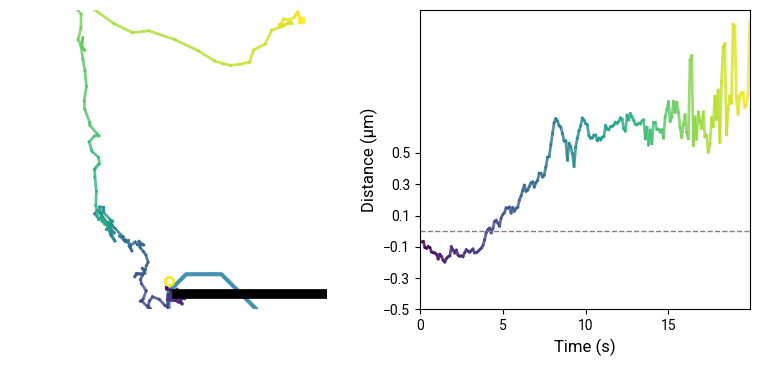

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-25_track_588.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-25, Track ID: 3640
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-25
    ✅ 1/1 tracks interacting with 698 condensates
Length of exp_results: 2
⚠️ Mismatch in number of points: track_data has 14, trace_df has 10
First dwell time: 9.2, until 12.2
First time point int track_data: 88


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


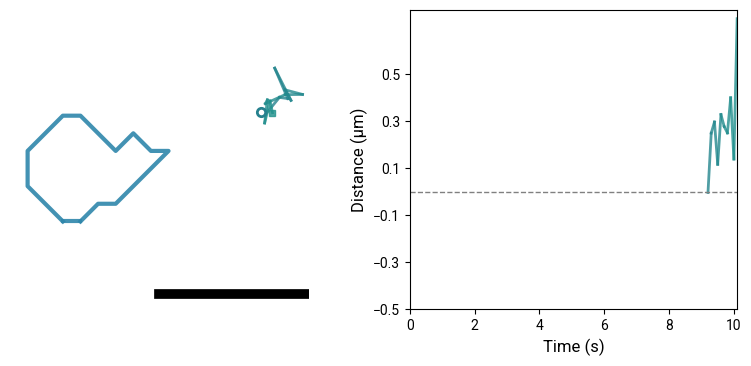

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-25_track_3640.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-25, Track ID: 3916
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-25
    ✅ 1/1 tracks interacting with 710 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 75, trace_df has 52
First dwell time: 12.5, until 15.5
First time point int track_data: 102


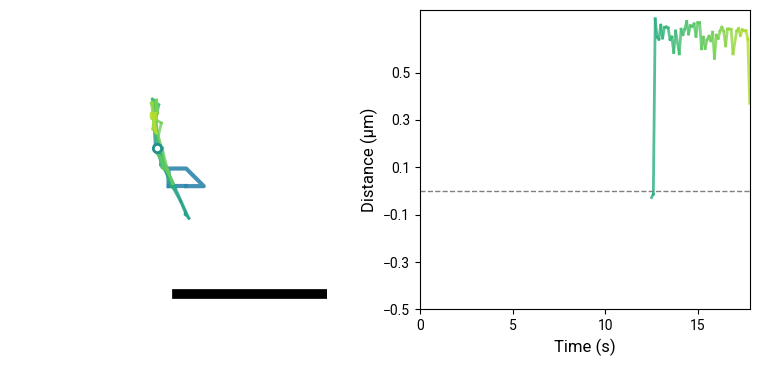

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-25_track_3916.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-25, Track ID: 4084
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-25
    ✅ 1/1 tracks interacting with 697 condensates
Length of exp_results: 2
⚠️ Mismatch in number of points: track_data has 8, trace_df has 2
First dwell time: 11.1, until 14.1
First time point int track_data: 104


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


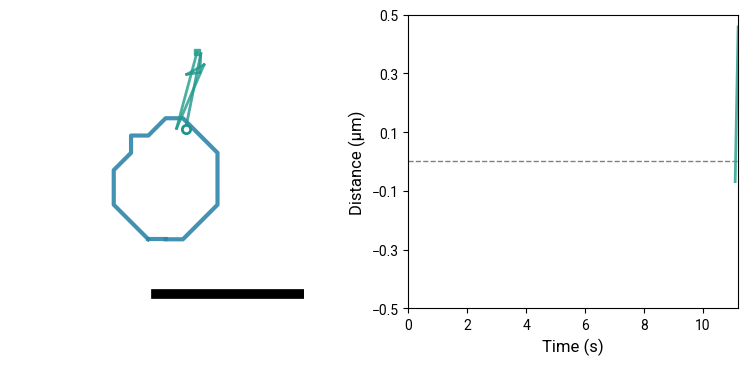

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-25_track_4084.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-25, Track ID: 4090
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-25
    ✅ 1/1 tracks interacting with 706 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


First dwell time: 10.5, until 13.5
First time point int track_data: 105


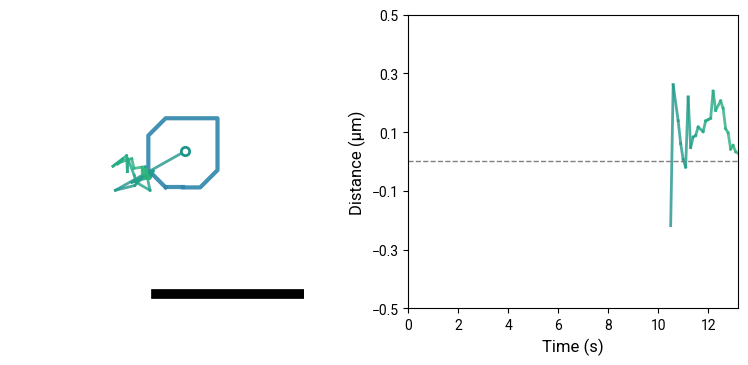

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-25_track_4090.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-25, Track ID: 4550
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-25
    ✅ 1/1 tracks interacting with 706 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 70, trace_df has 37
First dwell time: 16.3, until 19.3
First time point int track_data: 130


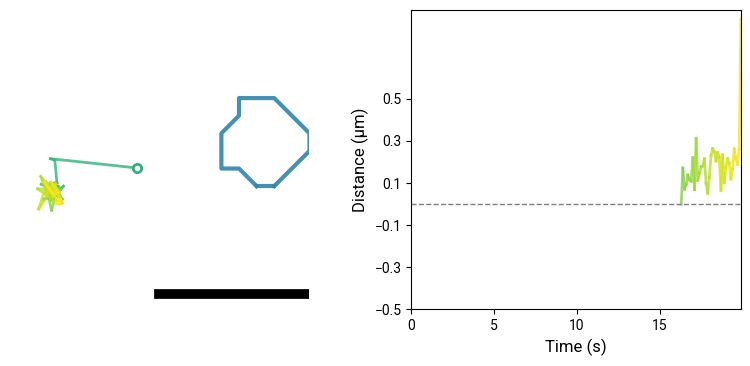

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-25_track_4550.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-25, Track ID: 5136
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-25
    ✅ 1/1 tracks interacting with 683 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 26, trace_df has 4
First dwell time: 17.8, until 20.8
First time point int track_data: 156


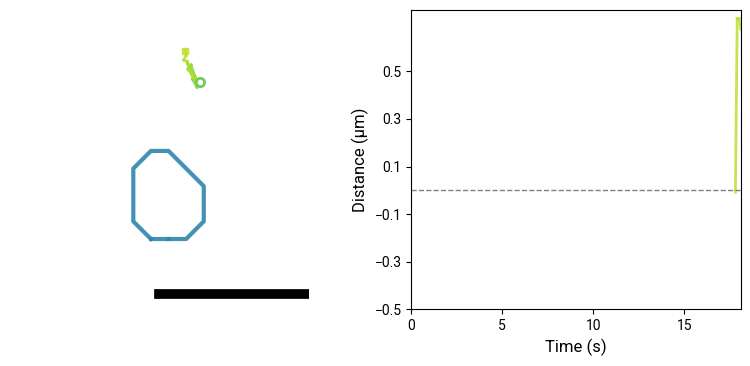

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-25_track_5136.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-15, Track ID: 98
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-15
    ✅ 1/1 tracks interacting with 696 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 50, trace_df has 44
First dwell time: 0.9, until 3.9
First time point int track_data: 3


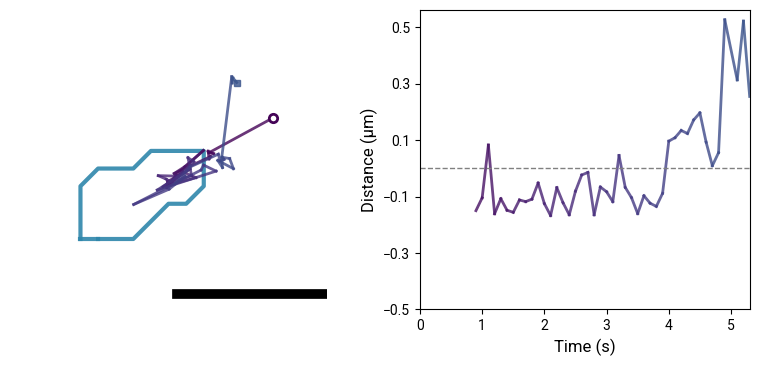

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-15_track_98.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-15, Track ID: 633
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-15
    ✅ 1/1 tracks interacting with 706 condensates
Length of exp_results: 2
⚠️ Mismatch in number of points: track_data has 18, trace_df has 2
First dwell time: 1.8, until 4.8
First time point int track_data: 0


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


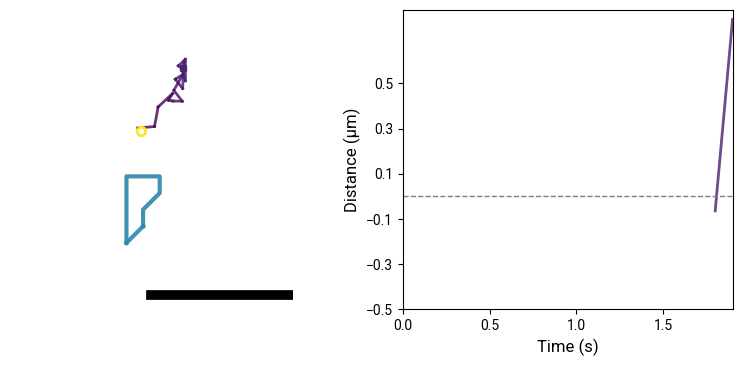

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-15_track_633.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-15, Track ID: 991
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-15
    ✅ 1/1 tracks interacting with 691 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 72, trace_df has 23
First dwell time: 6.7, until 9.7
First time point int track_data: 18


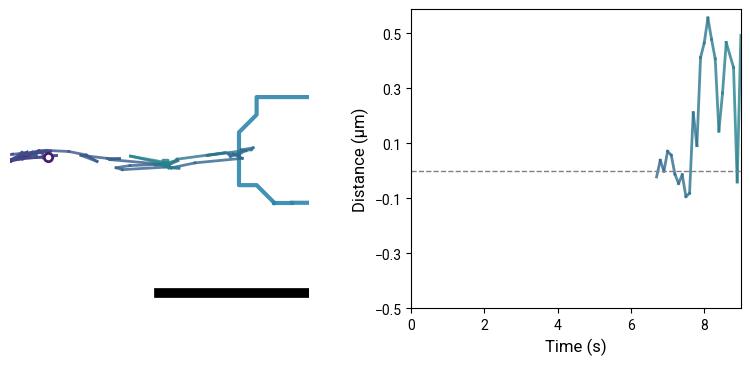

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-15_track_991.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-15, Track ID: 1027
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-15
    ✅ 1/1 tracks interacting with 699 condensates
Length of exp_results: 2
⚠️ Mismatch in number of points: track_data has 13, trace_df has 12


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


First dwell time: 2.5, until 5.5
First time point int track_data: 24


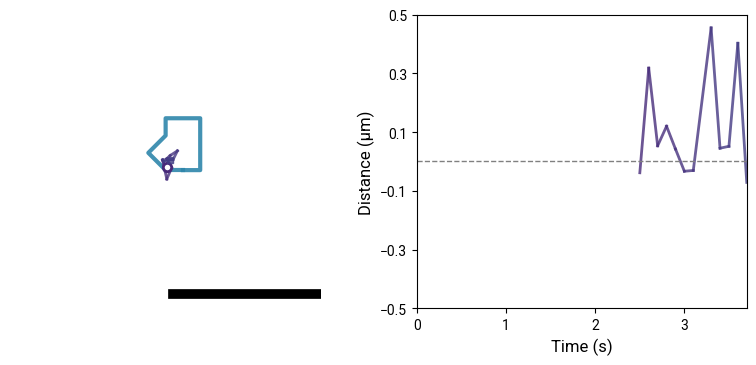

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-15_track_1027.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-15, Track ID: 1494
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-15
    ✅ 1/1 tracks interacting with 701 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


First dwell time: 3.8, until 6.8
First time point int track_data: 38


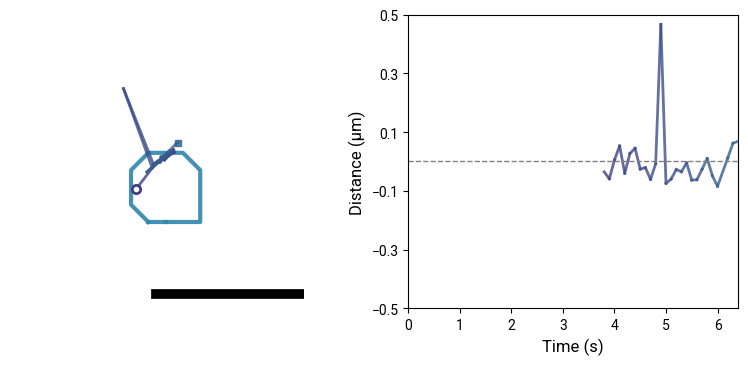

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-15_track_1494.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-15, Track ID: 1987
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-15
    ✅ 1/1 tracks interacting with 673 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 28, trace_df has 21
First dwell time: 6.1000000000000005, until 9.100000000000001
First time point int track_data: 53


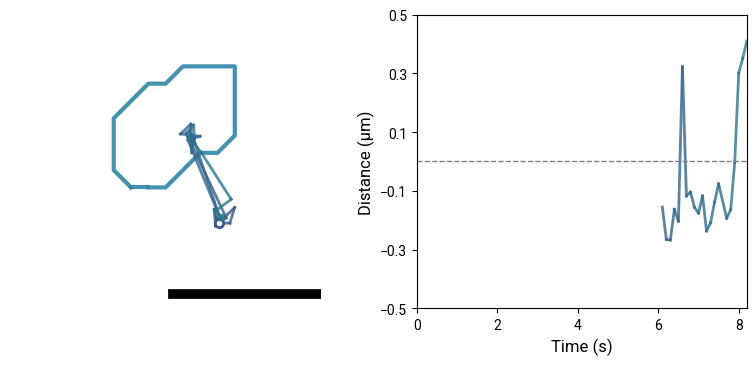

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-15_track_1987.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-15, Track ID: 2530
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-15
    ✅ 1/1 tracks interacting with 685 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 29, trace_df has 26
First dwell time: 9.7, until 12.7
First time point int track_data: 94


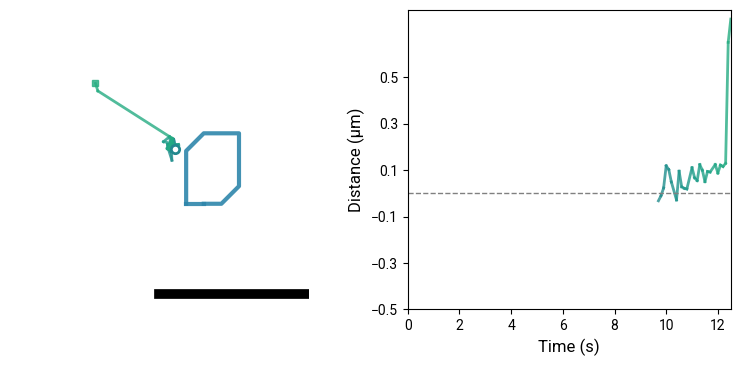

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-15_track_2530.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-15, Track ID: 3708
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-15
    ✅ 1/1 tracks interacting with 679 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 41, trace_df has 3
First dwell time: 19.6, until 22.6
First time point int track_data: 157


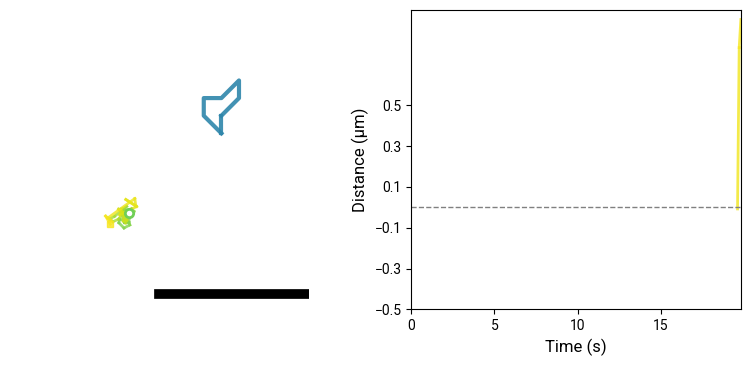

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-15_track_3708.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-7, Track ID: 123
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-7
    ✅ 1/1 tracks interacting with 745 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 153, trace_df has 112
First dwell time: 4.1000000000000005, until 7.1000000000000005
First time point int track_data: 0


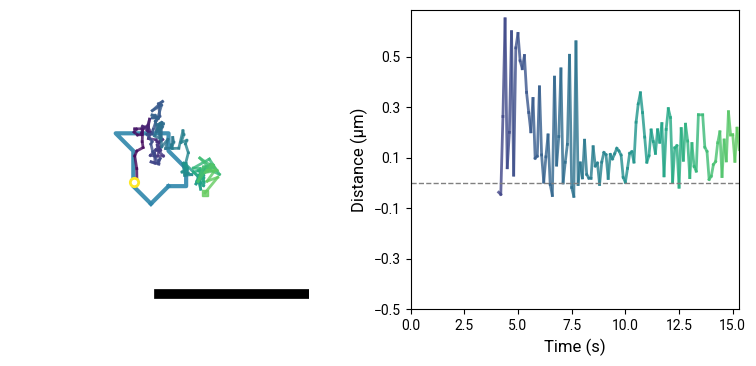

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-7_track_123.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-7, Track ID: 750
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-7
    ✅ 1/1 tracks interacting with 740 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 48, trace_df has 41
First dwell time: 0.8, until 3.8
First time point int track_data: 0


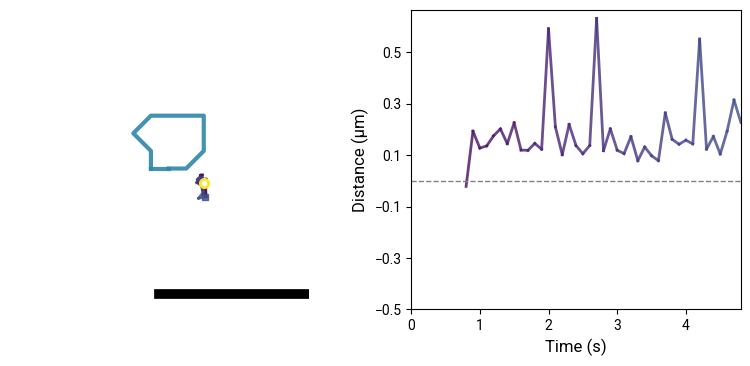

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-7_track_750.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-7, Track ID: 1338
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-7
    ✅ 1/1 tracks interacting with 750 condensates
Length of exp_results: 2
⚠️ Mismatch in number of points: track_data has 12, trace_df has 9
First dwell time: 2.0, until 5.0
First time point int track_data: 17


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


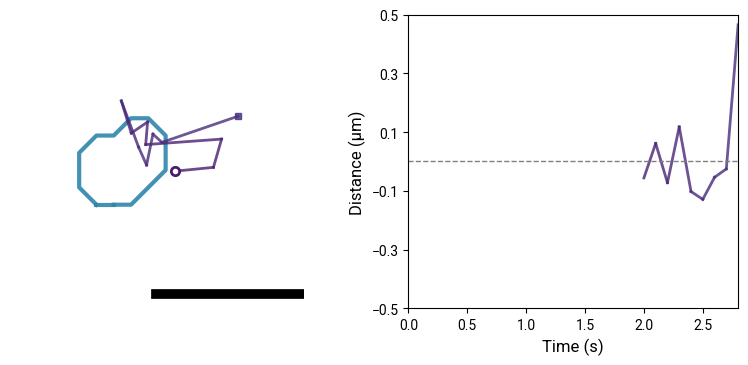

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-7_track_1338.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-7, Track ID: 2131
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-7
    ✅ 1/1 tracks interacting with 730 condensates
Length of exp_results: 2
First dwell time: 5.6000000000000005, until 8.600000000000001
First time point int track_data: 56


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


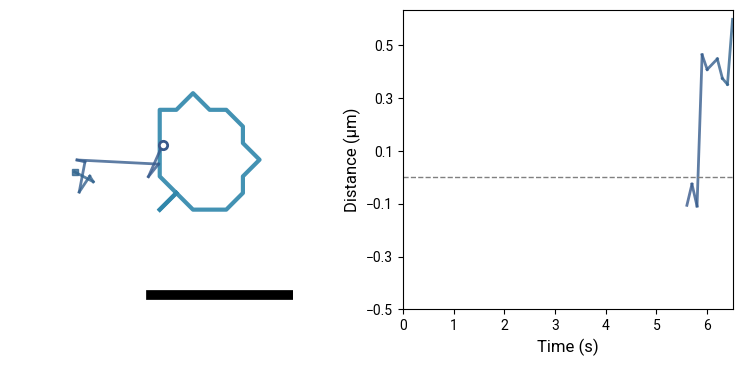

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-7_track_2131.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-7, Track ID: 2207
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-7
    ✅ 1/1 tracks interacting with 747 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 42, trace_df has 20
First dwell time: 7.300000000000001, until 10.3
First time point int track_data: 51


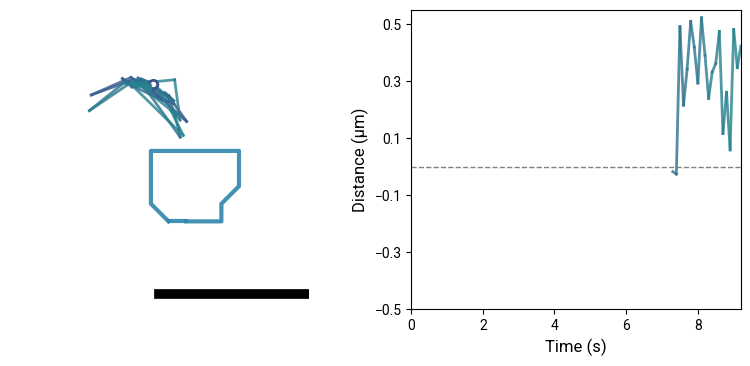

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-7_track_2207.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-7, Track ID: 3788
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-7
    ✅ 1/1 tracks interacting with 725 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 42, trace_df has 40
First dwell time: 13.6, until 16.6
First time point int track_data: 134


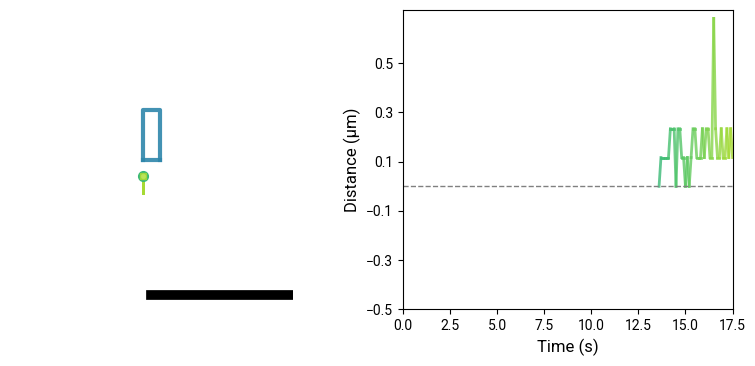

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-7_track_3788.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-7, Track ID: 4656
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-7
    ✅ 1/1 tracks interacting with 719 condensates
Length of exp_results: 2
First dwell time: 18.8, until 21.8
First time point int track_data: 188


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


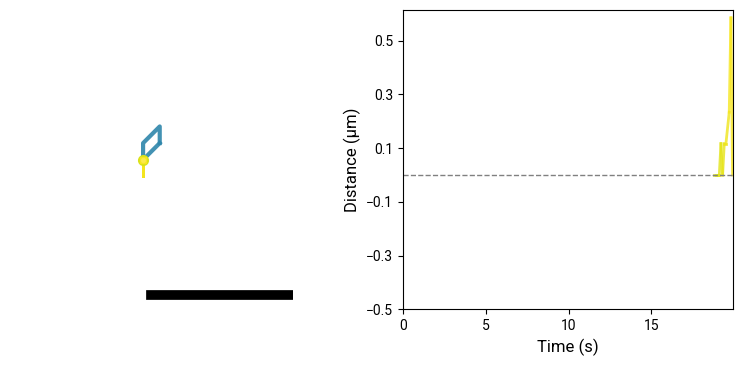

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-7_track_4656.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-1, Track ID: 69
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-1
    ✅ 1/1 tracks interacting with 996 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 160, trace_df has 102
First dwell time: 5.800000000000001, until 8.8
First time point int track_data: 0


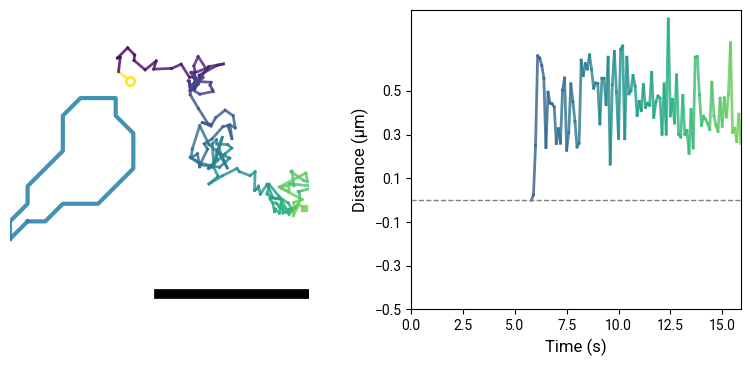

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-1_track_69.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-1, Track ID: 112
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-1
    ✅ 1/1 tracks interacting with 987 condensates
Length of exp_results: 2
⚠️ Mismatch in number of points: track_data has 8, trace_df has 7
First dwell time: 0.6000000000000001, until 3.6
First time point int track_data: 5


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


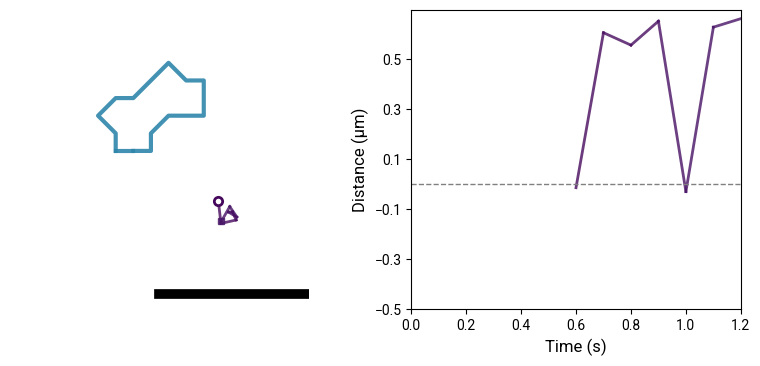

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-1_track_112.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-1, Track ID: 383
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-1
    ✅ 1/1 tracks interacting with 1000 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 114, trace_df has 107
First dwell time: 0.7000000000000001, until 3.7
First time point int track_data: 0


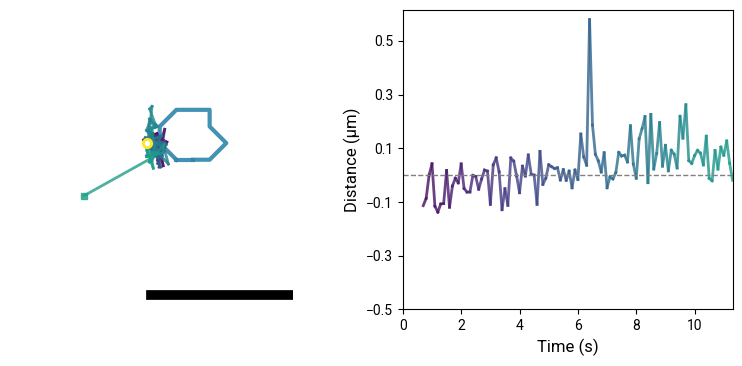

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-1_track_383.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-1, Track ID: 408
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-1
    ✅ 1/1 tracks interacting with 994 condensates
Length of exp_results: 2
First dwell time: 0.1, until 3.1
First time point int track_data: 1


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


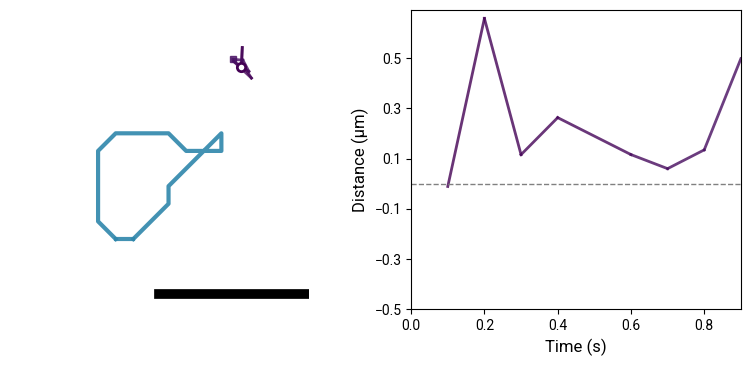

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-1_track_408.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-1, Track ID: 803
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-1
    ✅ 1/1 tracks interacting with 989 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 81, trace_df has 10
First dwell time: 9.6, until 12.6
First time point int track_data: 25


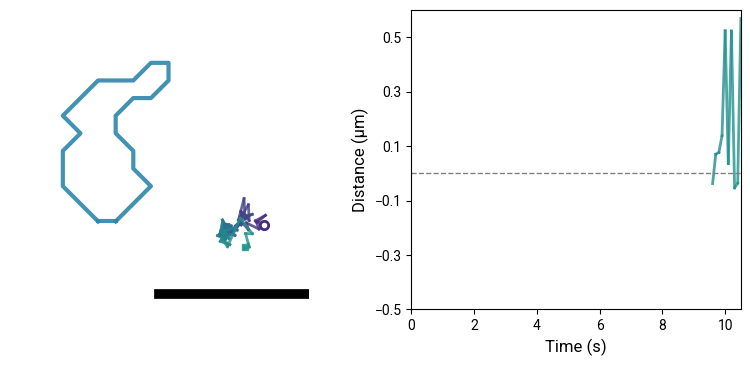

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-1_track_803.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-1, Track ID: 1633
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-1
    ✅ 1/1 tracks interacting with 987 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


First dwell time: 7.4, until 10.4
First time point int track_data: 74


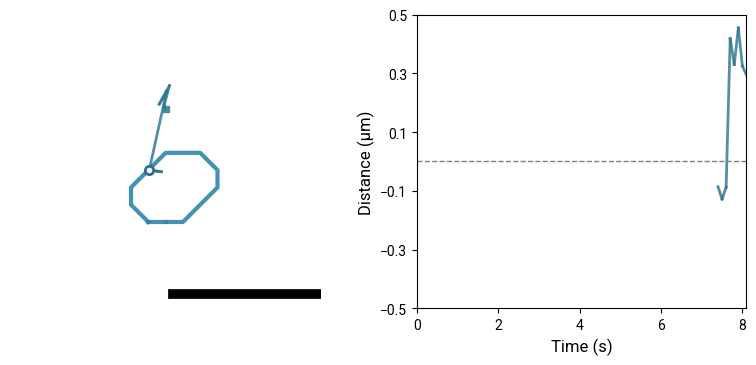

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-1_track_1633.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-1, Track ID: 1848
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-1
    ✅ 1/1 tracks interacting with 988 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 78, trace_df has 21
First dwell time: 15.8, until 18.8
First time point int track_data: 96


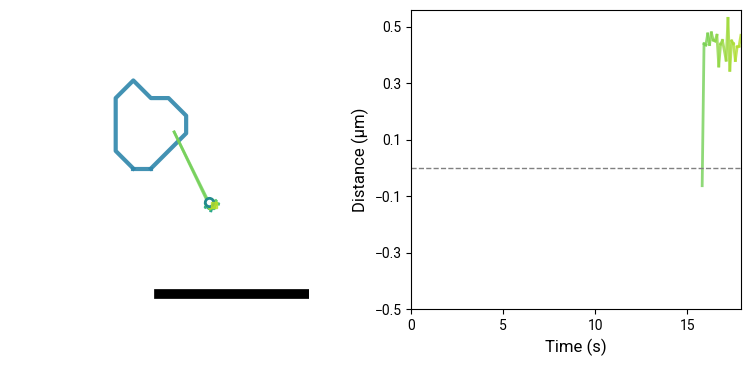

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-1_track_1848.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-1, Track ID: 2168
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-1
    ✅ 1/1 tracks interacting with 973 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 28, trace_df has 17
First dwell time: 13.4, until 16.4
First time point int track_data: 123


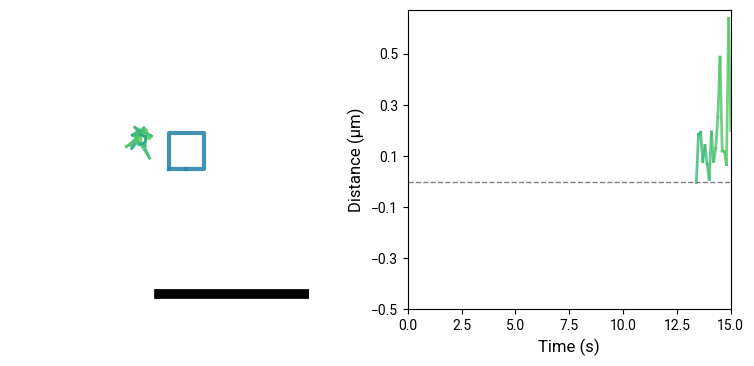

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-1_track_2168.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-21, Track ID: 996
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-21
    ✅ 1/1 tracks interacting with 654 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 30, trace_df has 29
First dwell time: 1.3, until 4.3
First time point int track_data: 12


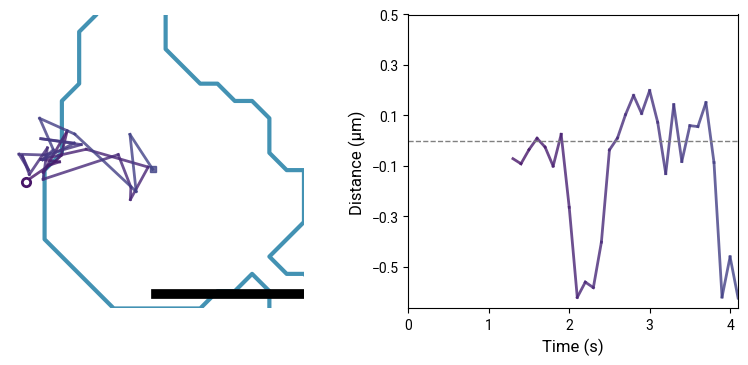

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-21_track_996.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-21, Track ID: 1706
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-21
    ✅ 1/1 tracks interacting with 634 condensates
Length of exp_results: 2
First dwell time: 2.3000000000000003, until 5.300000000000001
First time point int track_data: 23


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


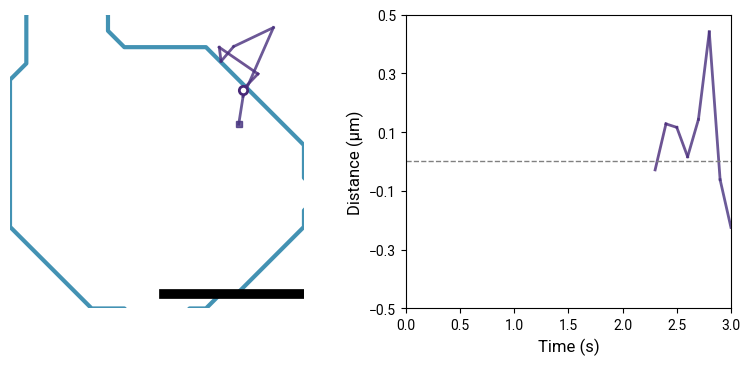

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-21_track_1706.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-21, Track ID: 1896
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-21
    ✅ 1/1 tracks interacting with 647 condensates
Length of exp_results: 2
First dwell time: 3.2, until 6.2
First time point int track_data: 32


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


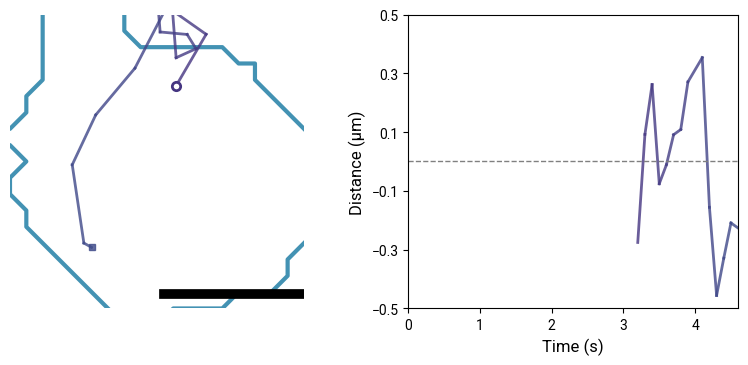

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-21_track_1896.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-21, Track ID: 1907
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-21
    ✅ 1/1 tracks interacting with 658 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 32, trace_df has 21
First dwell time: 3.9, until 6.9
First time point int track_data: 27


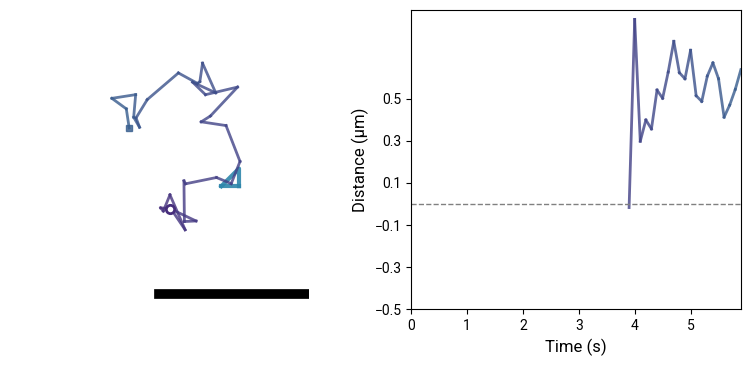

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-21_track_1907.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-21, Track ID: 3461
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-21
    ✅ 1/1 tracks interacting with 645 condensates
Length of exp_results: 2
⚠️ Mismatch in number of points: track_data has 11, trace_df has 8
First dwell time: 7.6, until 10.6
First time point int track_data: 72


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


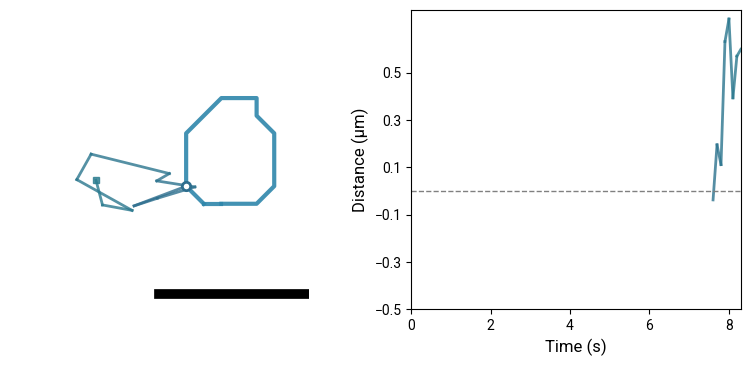

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-21_track_3461.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-21, Track ID: 3594
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-21
    ✅ 1/1 tracks interacting with 647 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 118, trace_df has 58
First dwell time: 14.2, until 17.2
First time point int track_data: 82


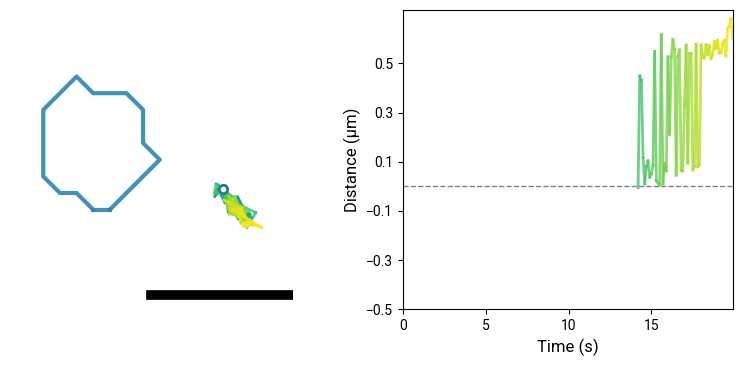

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-21_track_3594.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-21, Track ID: 4045
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-21
    ✅ 1/1 tracks interacting with 653 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 35, trace_df has 11
First dwell time: 11.5, until 14.5
First time point int track_data: 91


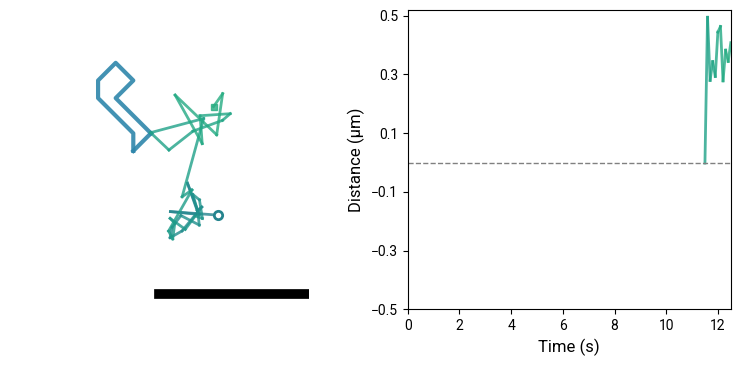

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-21_track_4045.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-21, Track ID: 4580
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-21
    ✅ 1/1 tracks interacting with 653 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 25, trace_df has 15
First dwell time: 11.1, until 14.1
First time point int track_data: 101


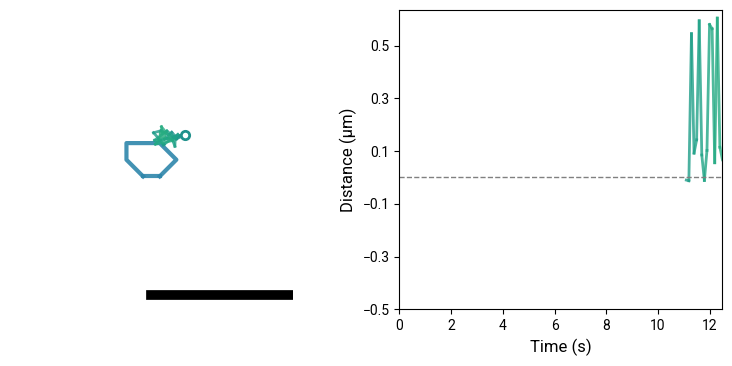

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-21_track_4580.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-21, Track ID: 5470
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-21
    ✅ 1/1 tracks interacting with 647 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


First dwell time: 12.5, until 15.5
First time point int track_data: 125


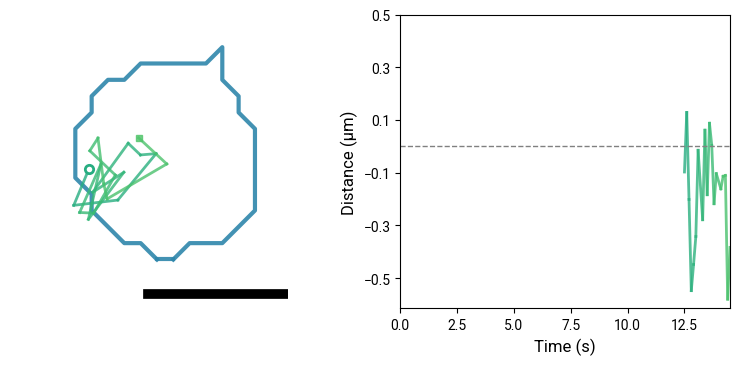

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-21_track_5470.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-21, Track ID: 5948
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-21
    ✅ 1/1 tracks interacting with 643 condensates
Length of exp_results: 2
⚠️ Mismatch in number of points: track_data has 32, trace_df has 31


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


First dwell time: 14.8, until 17.8
First time point int track_data: 147


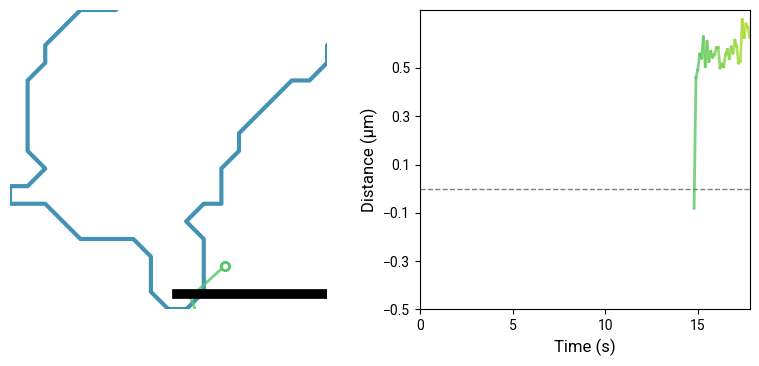

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-21_track_5948.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-9, Track ID: 282
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-9
    ✅ 1/1 tracks interacting with 490 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 200, trace_df has 188
First dwell time: 1.2000000000000002, until 4.2
First time point int track_data: 0


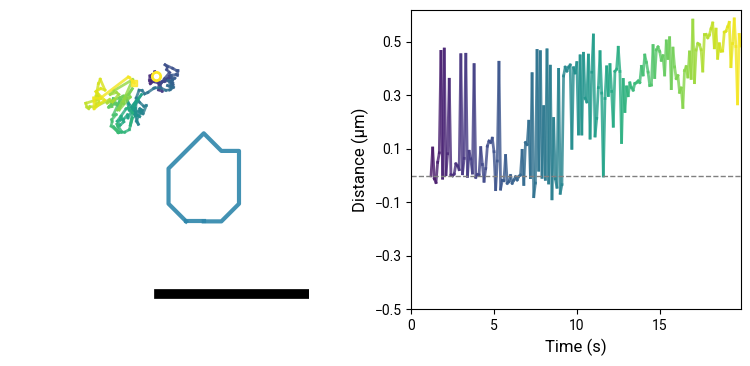

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-9_track_282.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-9, Track ID: 385
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-9
    ✅ 1/1 tracks interacting with 500 condensates
Length of exp_results: 2
First dwell time: 0.0, until 3.0
First time point int track_data: 0


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


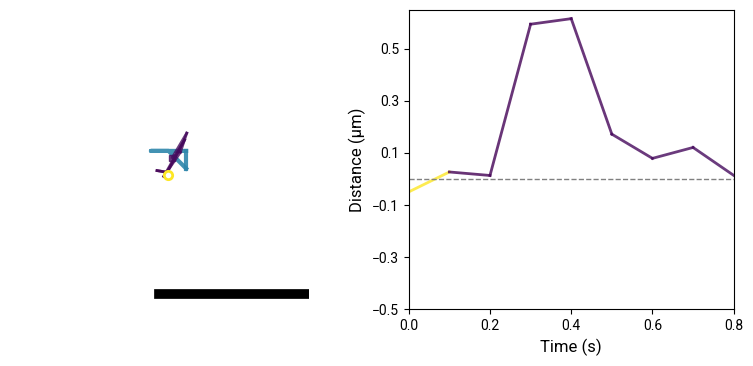

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-9_track_385.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-9, Track ID: 426
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-9
    ✅ 1/1 tracks interacting with 491 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 74, trace_df has 10
First dwell time: 6.6000000000000005, until 9.600000000000001
First time point int track_data: 0


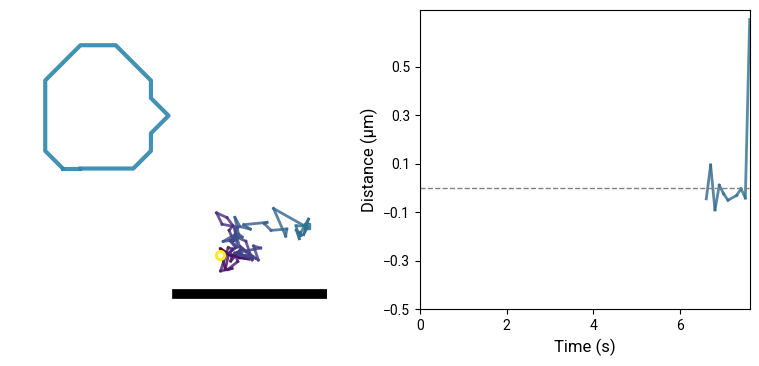

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-9_track_426.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-9, Track ID: 454
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-9
    ✅ 1/1 tracks interacting with 498 condensates
Length of exp_results: 2
⚠️ Mismatch in number of points: track_data has 11, trace_df has 9
First dwell time: 0.3, until 3.3
First time point int track_data: 1


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


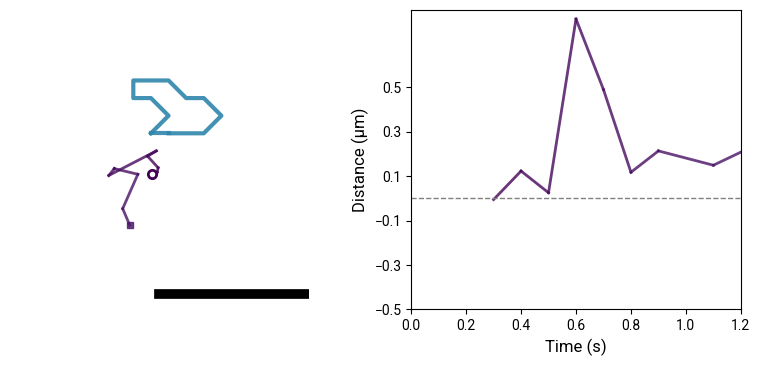

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-9_track_454.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-9, Track ID: 1228
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-9
    ✅ 1/1 tracks interacting with 490 condensates
Length of exp_results: 2
⚠️ Mismatch in number of points: track_data has 10, trace_df has 8
First dwell time: 3.1, until 6.1
First time point int track_data: 29


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


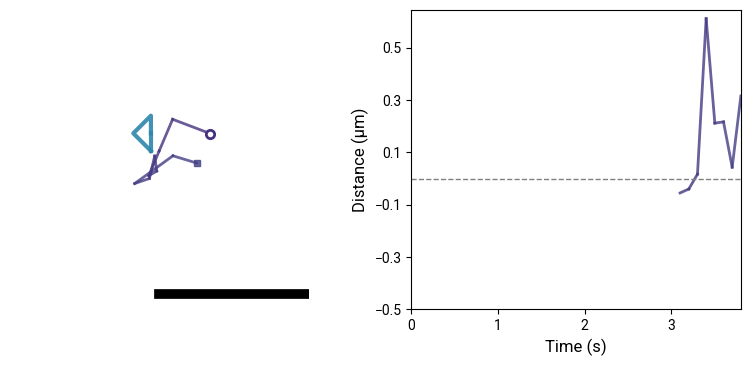

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-9_track_1228.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-9, Track ID: 2224
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-9
    ✅ 1/1 tracks interacting with 491 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 31, trace_df has 27
First dwell time: 7.7, until 10.7
First time point int track_data: 73


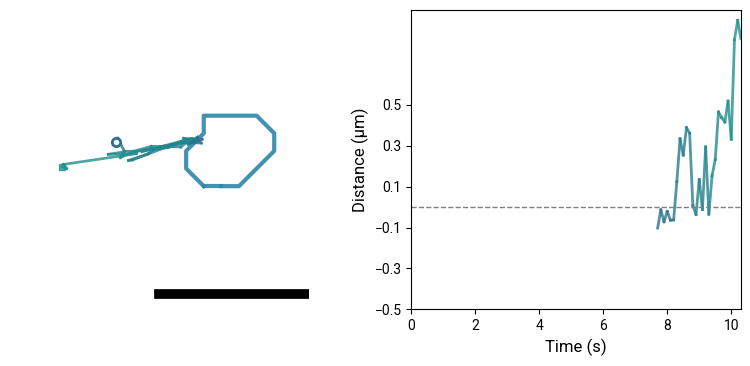

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-9_track_2224.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-9, Track ID: 2231
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-9
    ✅ 1/1 tracks interacting with 483 condensates
Length of exp_results: 2
⚠️ Mismatch in number of points: track_data has 8, trace_df has 3
First dwell time: 8.3, until 11.3
First time point int track_data: 78


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


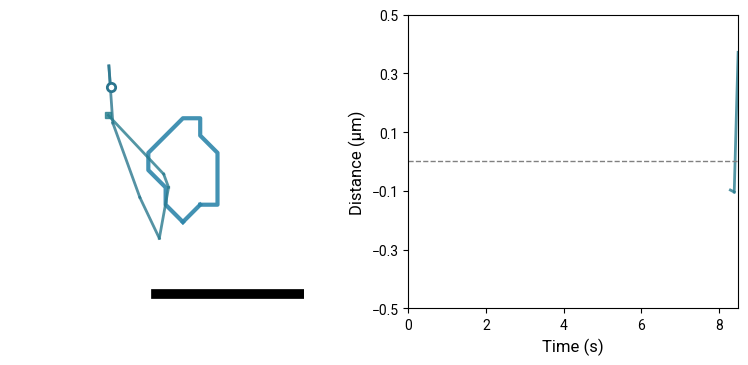

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-9_track_2231.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-9, Track ID: 2247
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-9
    ✅ 1/1 tracks interacting with 500 condensates
Length of exp_results: 2
⚠️ Mismatch in number of points: track_data has 18, trace_df has 12
First dwell time: 8.0, until 11.0
First time point int track_data: 74


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


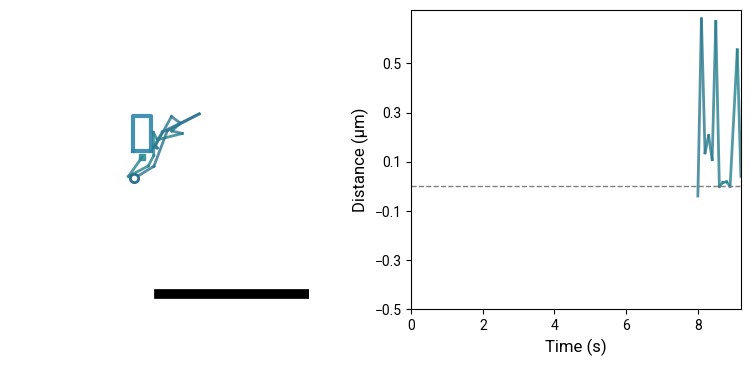

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-9_track_2247.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-9, Track ID: 2697
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-9
    ✅ 1/1 tracks interacting with 480 condensates
Length of exp_results: 2
⚠️ Mismatch in number of points: track_data has 34, trace_df has 32
First dwell time: 9.0, until 12.0
First time point int track_data: 88


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


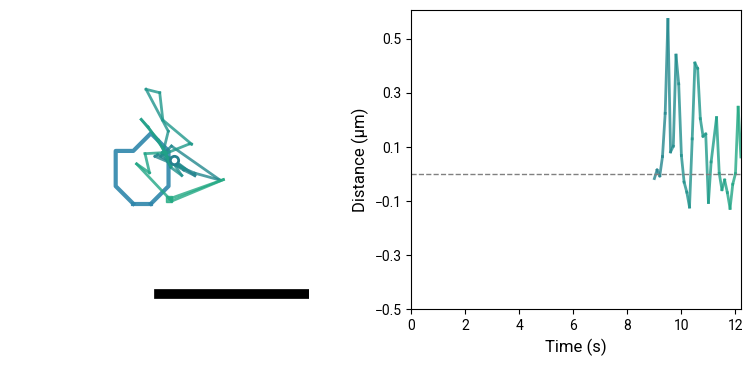

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-9_track_2697.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-9, Track ID: 2717
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-9
    ✅ 1/1 tracks interacting with 484 condensates
Length of exp_results: 2
⚠️ Mismatch in number of points: track_data has 27, trace_df has 6
First dwell time: 10.9, until 13.9
First time point int track_data: 88


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


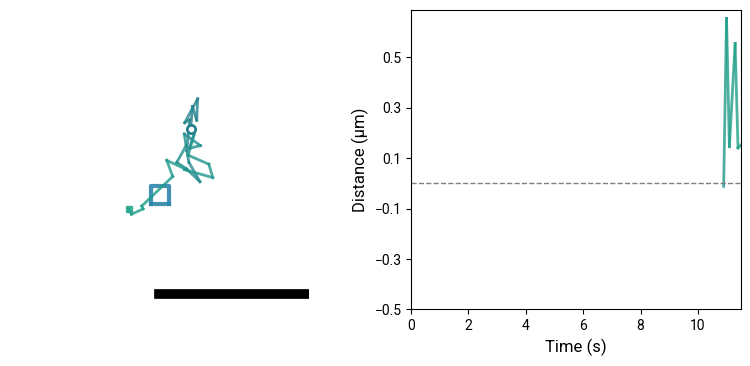

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-9_track_2717.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-9, Track ID: 3296
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-9
    ✅ 1/1 tracks interacting with 490 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 27, trace_df has 23
First dwell time: 12.2, until 15.2
First time point int track_data: 118


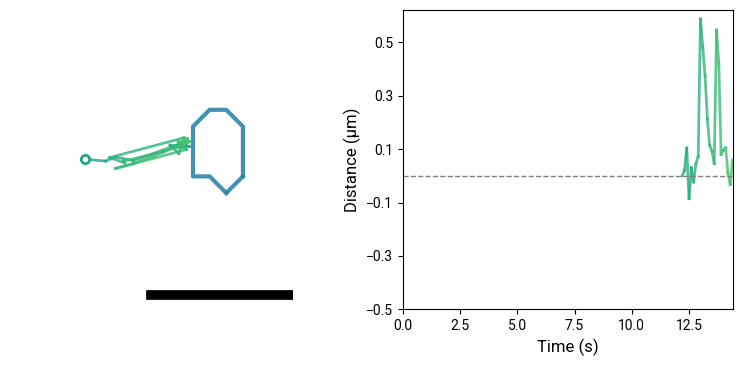

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-9_track_3296.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-9, Track ID: 3877
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-9
    ✅ 1/1 tracks interacting with 490 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 52, trace_df has 44
First dwell time: 15.6, until 18.6
First time point int track_data: 148


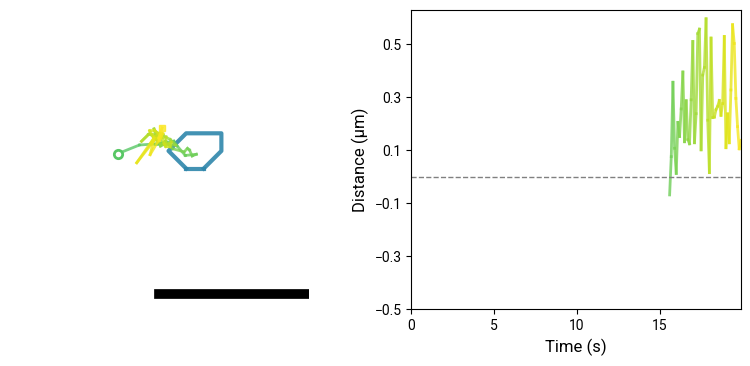

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-9_track_3877.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-9, Track ID: 4185
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-9
    ✅ 1/1 tracks interacting with 490 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 36, trace_df has 3
First dwell time: 19.700000000000003, until 22.700000000000003
First time point int track_data: 164


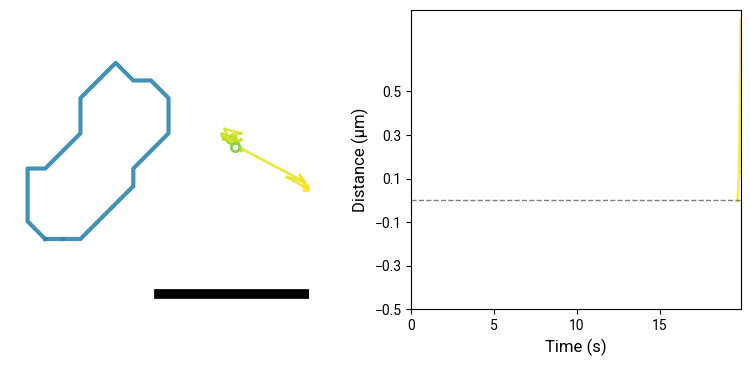

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-9_track_4185.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-9, Track ID: 4198
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-9
    ✅ 1/1 tracks interacting with 481 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 26, trace_df has 23
First dwell time: 15.7, until 18.7
First time point int track_data: 154


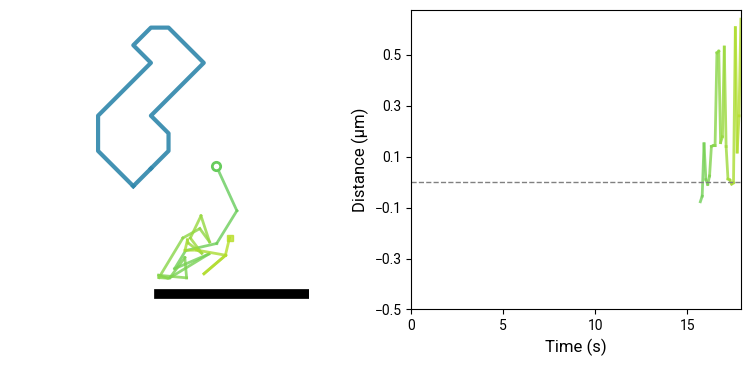

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-9_track_4198.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-9, Track ID: 4701
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-9
    ✅ 1/1 tracks interacting with 487 condensates
Length of exp_results: 2
First dwell time: 17.400000000000002, until 20.400000000000002
First time point int track_data: 174


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


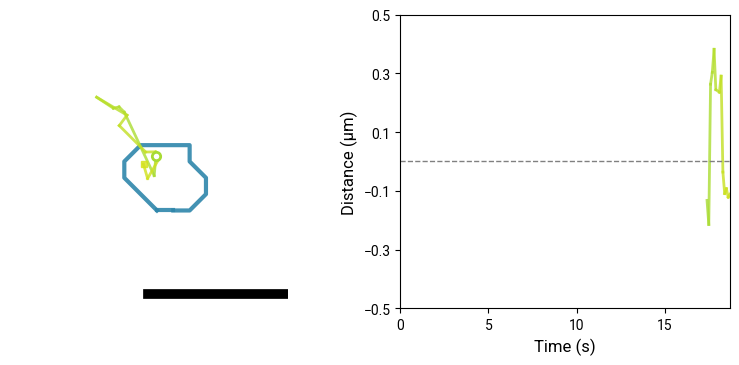

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-9_track_4701.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-13, Track ID: 1478
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-13
    ✅ 1/1 tracks interacting with 741 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 153, trace_df has 152
First dwell time: 4.800000000000001, until 7.800000000000001
First time point int track_data: 47


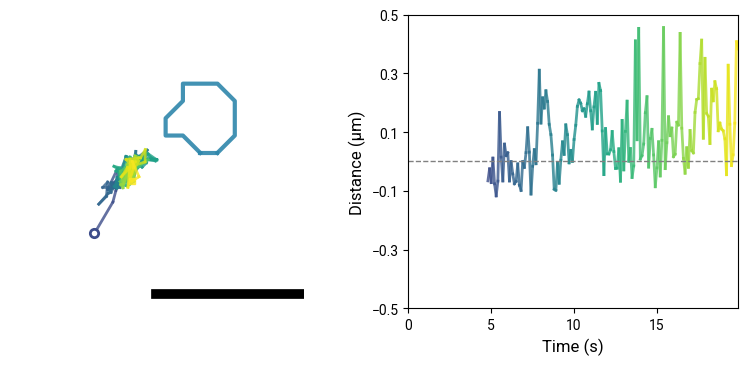

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-13_track_1478.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-13, Track ID: 1585
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-13
    ✅ 1/1 tracks interacting with 735 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 22, trace_df has 16
First dwell time: 6.4, until 9.4
First time point int track_data: 58


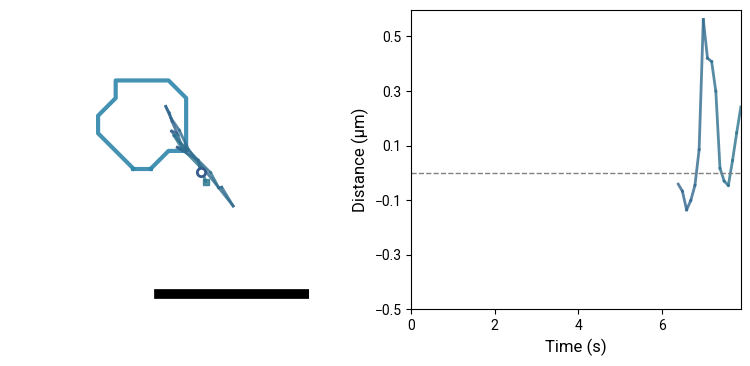

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-13_track_1585.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-13, Track ID: 3102
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-13
    ✅ 1/1 tracks interacting with 751 condensates
Length of exp_results: 2
First dwell time: 12.1, until 15.1
First time point int track_data: 121


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


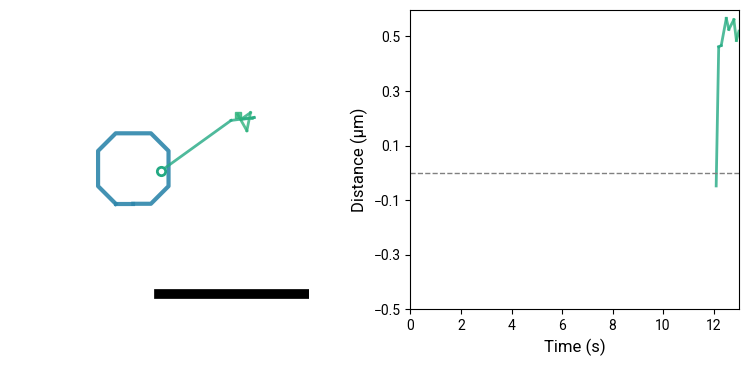

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-13_track_3102.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-19, Track ID: 282
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-19
    ✅ 1/1 tracks interacting with 784 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


First dwell time: 0.0, until 3.0
First time point int track_data: 0


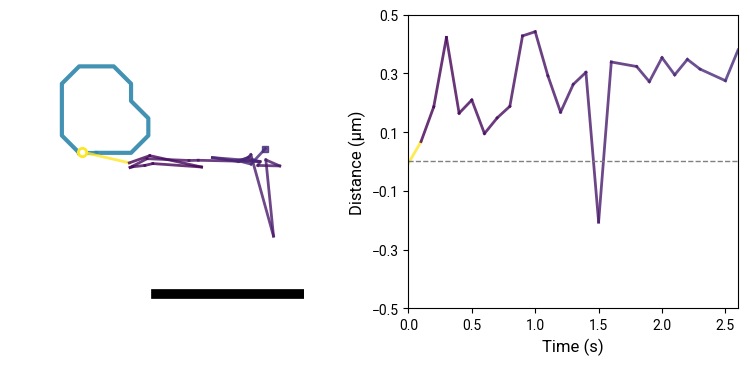

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-19_track_282.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-19, Track ID: 370
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-19
    ✅ 1/1 tracks interacting with 784 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 200, trace_df has 196
First dwell time: 0.4, until 3.4
First time point int track_data: 0


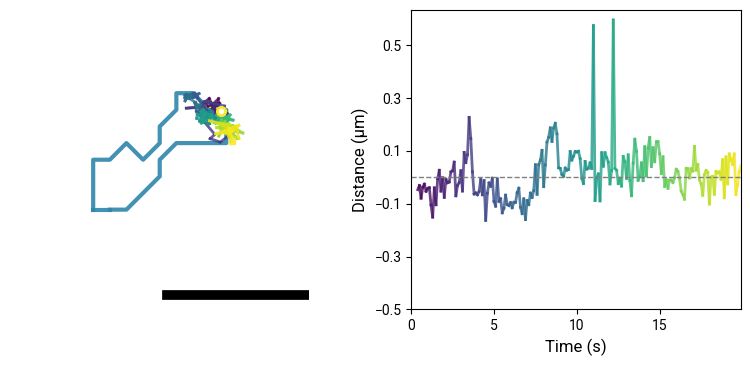

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-19_track_370.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-19, Track ID: 467
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-19
    ✅ 1/1 tracks interacting with 774 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 35, trace_df has 2
First dwell time: 3.4000000000000004, until 6.4
First time point int track_data: 0


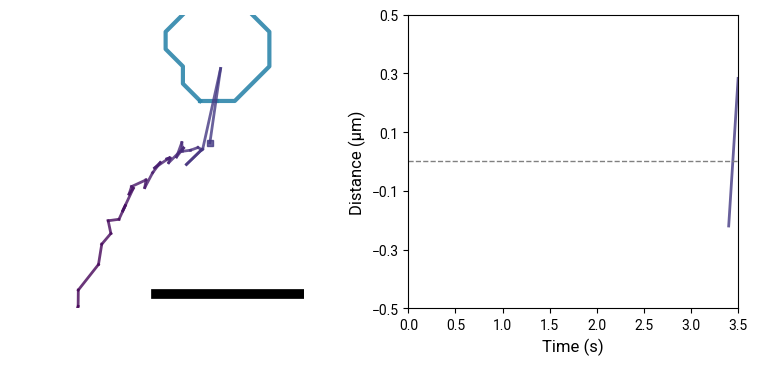

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-19_track_467.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-19, Track ID: 703
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-19
    ✅ 1/1 tracks interacting with 775 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 166, trace_df has 3
First dwell time: 16.3, until 19.3
First time point int track_data: 0


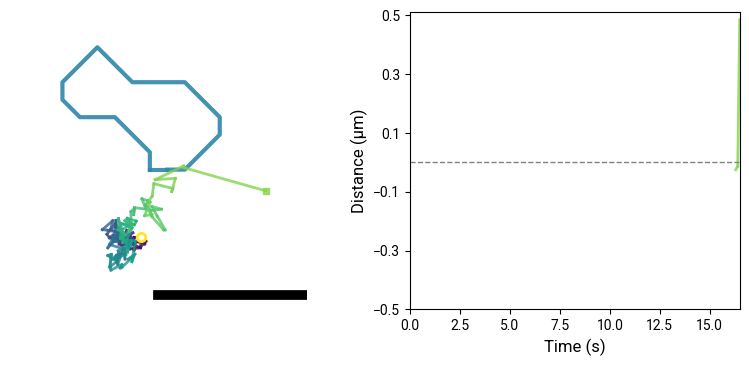

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-19_track_703.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-19, Track ID: 1105
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-19
    ✅ 1/1 tracks interacting with 777 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 19, trace_df has 3
First dwell time: 2.7, until 5.7
First time point int track_data: 11


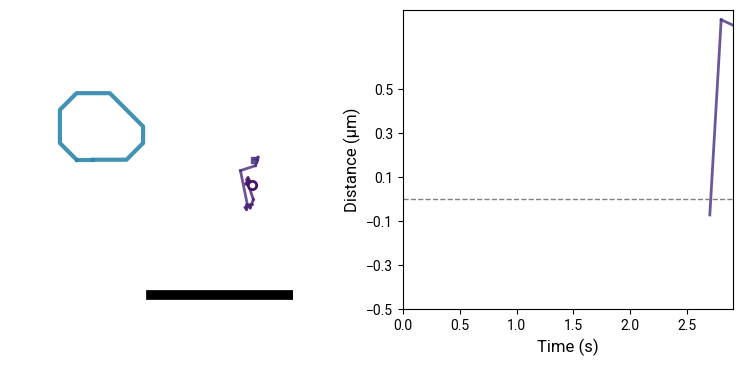

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-19_track_1105.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-19, Track ID: 1782
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-19
    ✅ 1/1 tracks interacting with 775 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 74, trace_df has 23
First dwell time: 8.700000000000001, until 11.700000000000001
First time point int track_data: 36


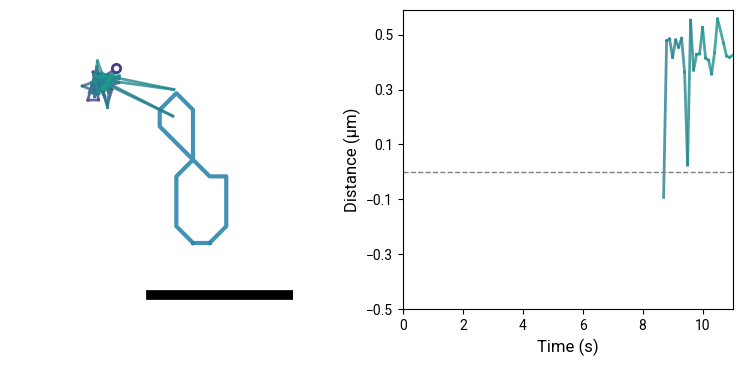

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-19_track_1782.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-19, Track ID: 2070
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-19
    ✅ 1/1 tracks interacting with 773 condensates
Length of exp_results: 2
⚠️ Mismatch in number of points: track_data has 18, trace_df has 13
First dwell time: 5.800000000000001, until 8.8
First time point int track_data: 52


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


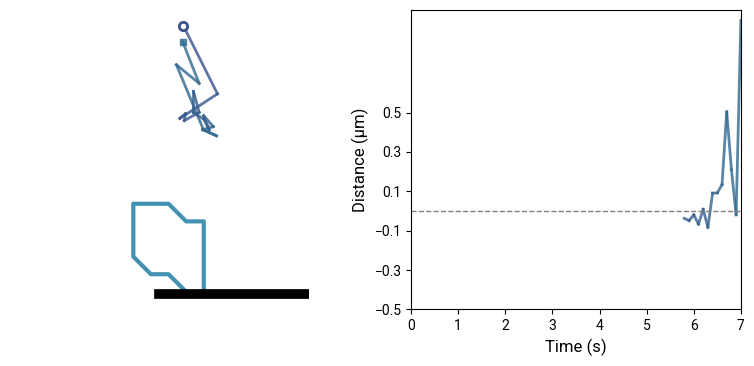

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-19_track_2070.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-19, Track ID: 2089
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-19
    ✅ 1/1 tracks interacting with 774 condensates
Length of exp_results: 2
First dwell time: 4.6000000000000005, until 7.6000000000000005
First time point int track_data: 46


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


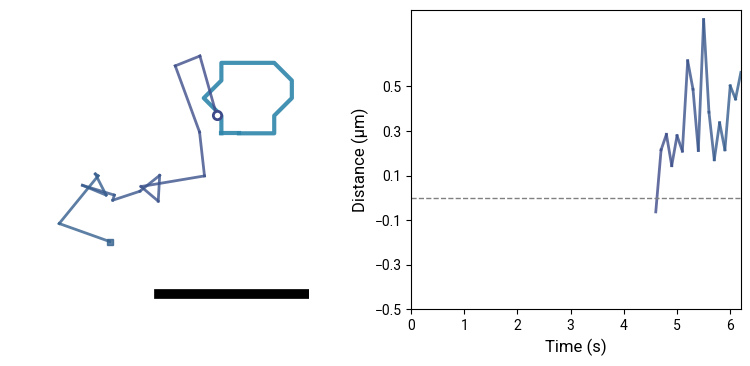

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-19_track_2089.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-19, Track ID: 2493
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-19
    ✅ 1/1 tracks interacting with 785 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


First dwell time: 6.1000000000000005, until 9.100000000000001
First time point int track_data: 61


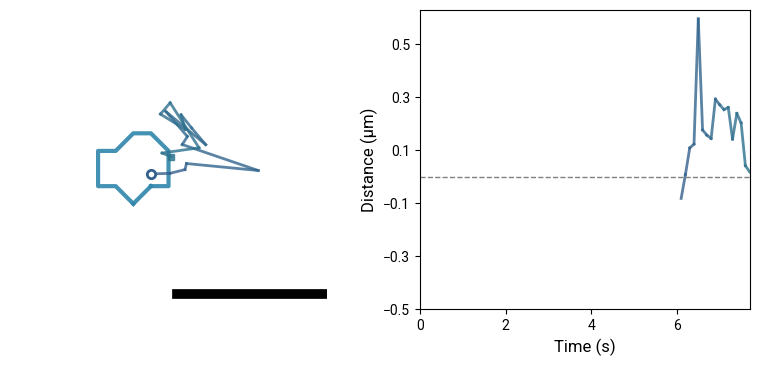

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-19_track_2493.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-19, Track ID: 2797
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-19
    ✅ 1/1 tracks interacting with 787 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 24, trace_df has 19
First dwell time: 8.1, until 11.1
First time point int track_data: 76


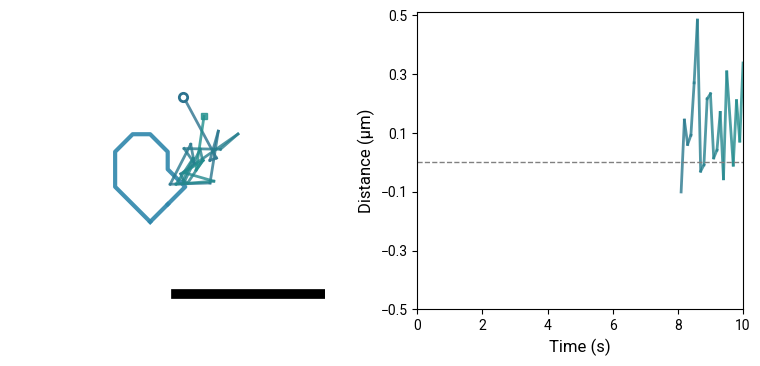

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-19_track_2797.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-19, Track ID: 3141
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-19
    ✅ 1/1 tracks interacting with 782 condensates
Length of exp_results: 2
⚠️ Mismatch in number of points: track_data has 10, trace_df has 8
First dwell time: 8.8, until 11.8
First time point int track_data: 86


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


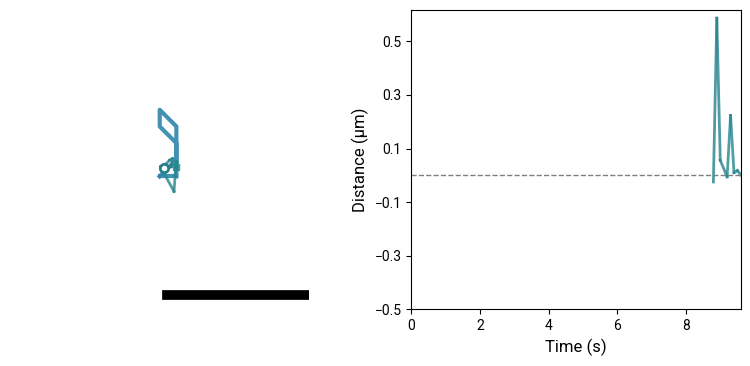

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-19_track_3141.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-19, Track ID: 3563
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-19
    ✅ 1/1 tracks interacting with 779 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


First dwell time: 10.3, until 13.3
First time point int track_data: 103


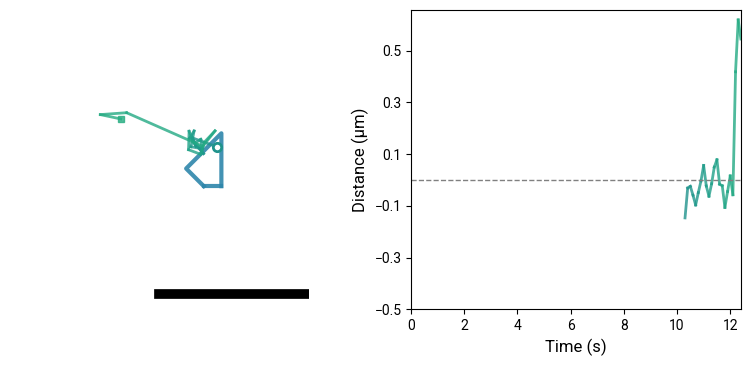

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-19_track_3563.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV, Track ID: 117
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV
    ✅ 1/1 tracks interacting with 965 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 199, trace_df has 187
First dwell time: 1.2000000000000002, until 4.2
First time point int track_data: 0


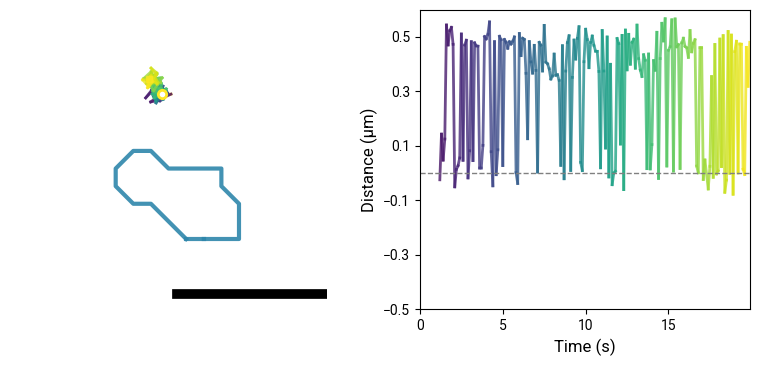

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV_track_117.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV, Track ID: 318
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV
    ✅ 1/1 tracks interacting with 998 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 90, trace_df has 30
First dwell time: 6.1000000000000005, until 9.100000000000001
First time point int track_data: 0


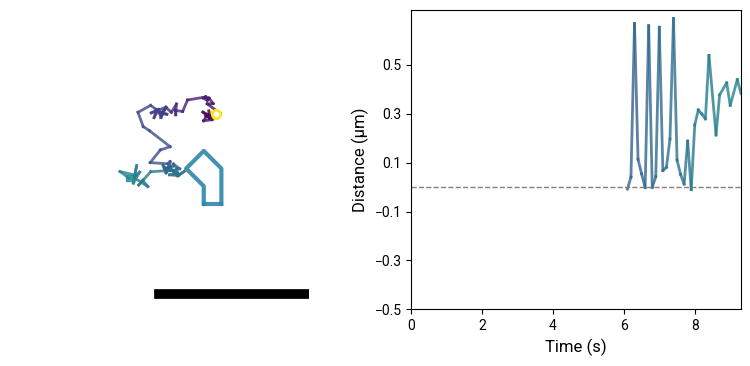

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV_track_318.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV, Track ID: 750
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV
    ✅ 1/1 tracks interacting with 988 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 21, trace_df has 9
First dwell time: 1.2000000000000002, until 4.2
First time point int track_data: 0


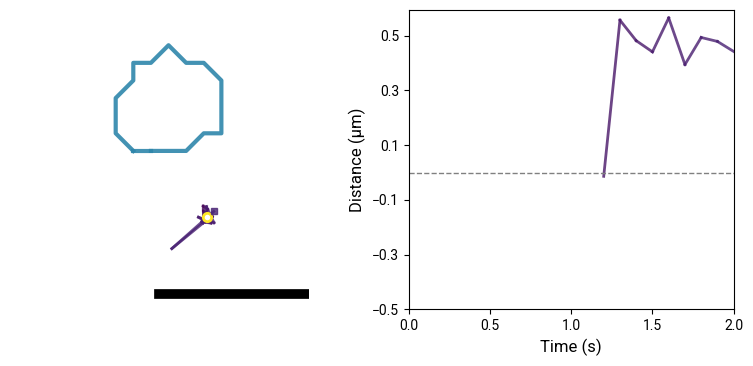

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV_track_750.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV, Track ID: 774
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV
    ✅ 1/1 tracks interacting with 983 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 112, trace_df has 100
First dwell time: 1.3, until 4.3
First time point int track_data: 0


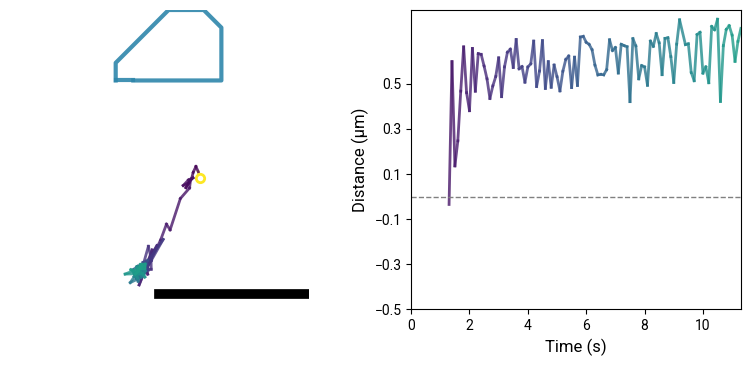

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV_track_774.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV, Track ID: 981
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV
    ✅ 1/1 tracks interacting with 984 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


First dwell time: 0.6000000000000001, until 3.6
First time point int track_data: 6


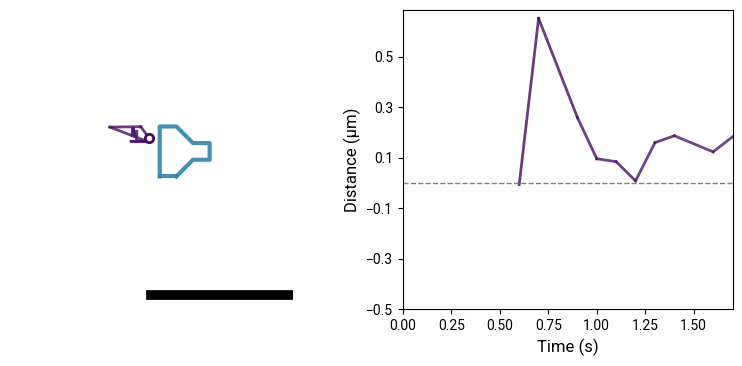

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV_track_981.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV, Track ID: 1444
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV
    ✅ 1/1 tracks interacting with 980 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 16, trace_df has 6
First dwell time: 3.3000000000000003, until 6.300000000000001
First time point int track_data: 23


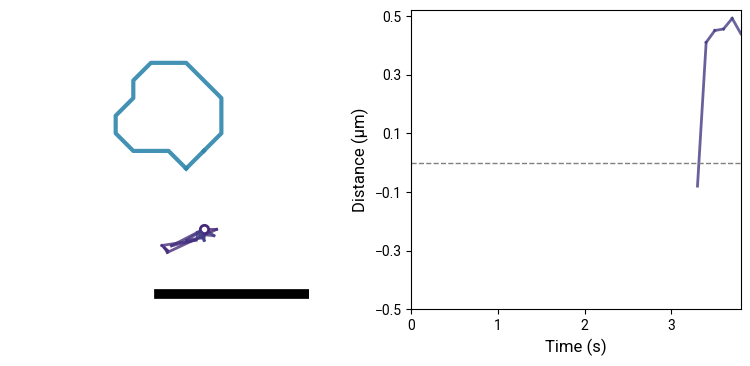

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV_track_1444.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-3, Track ID: 46
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-3
    ✅ 1/1 tracks interacting with 1180 condensates
Length of exp_results: 2
⚠️ Mismatch in number of points: track_data has 9, trace_df has 7
First dwell time: 0.8, until 3.8
First time point int track_data: 5


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


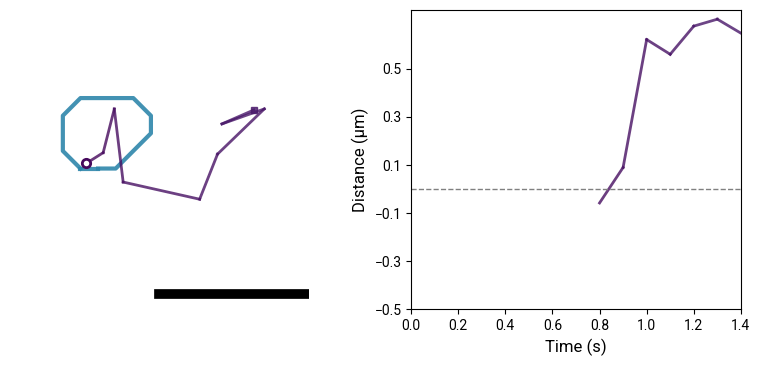

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-3_track_46.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-3, Track ID: 87
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-3
    ✅ 1/1 tracks interacting with 1165 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 38, trace_df has 33
First dwell time: 0.8, until 3.8
First time point int track_data: 2


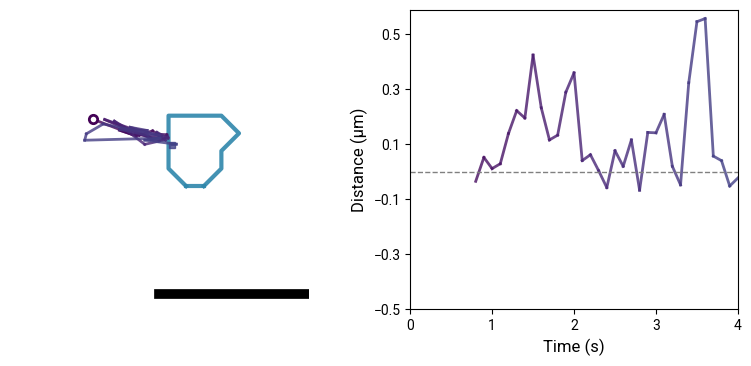

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-3_track_87.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-3, Track ID: 150
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-3
    ✅ 1/1 tracks interacting with 1147 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 200, trace_df has 192
First dwell time: 0.8, until 3.8
First time point int track_data: 0


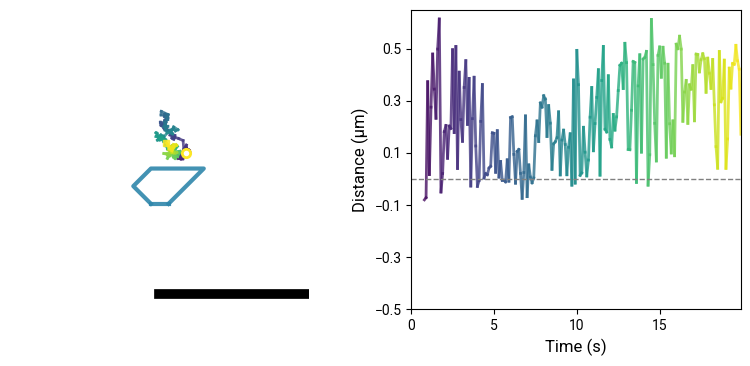

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-3_track_150.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-3, Track ID: 192
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-3
    ✅ 1/1 tracks interacting with 1158 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 71, trace_df has 69
First dwell time: 0.2, until 3.2
First time point int track_data: 0


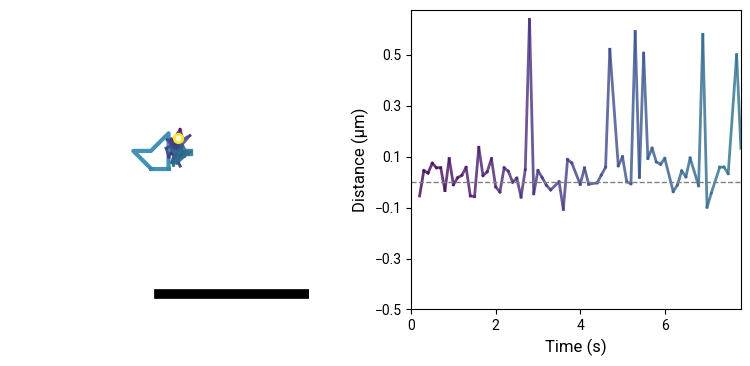

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-3_track_192.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-3, Track ID: 272
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-3
    ✅ 1/1 tracks interacting with 1175 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 48, trace_df has 44
First dwell time: 0.4, until 3.4
First time point int track_data: 0


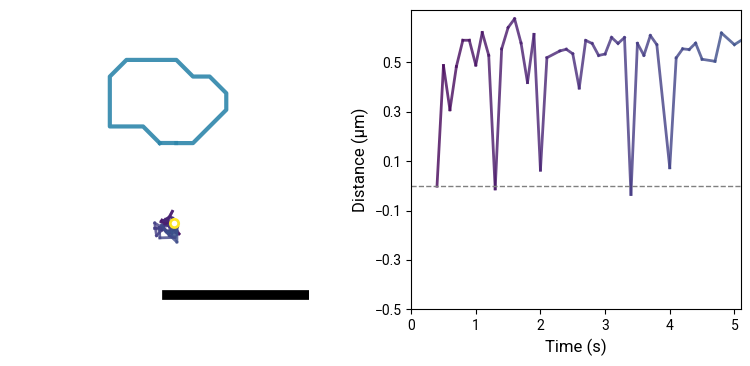

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-3_track_272.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-3, Track ID: 344
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-3
    ✅ 1/1 tracks interacting with 1135 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 155, trace_df has 23
First dwell time: 13.2, until 16.2
First time point int track_data: 0


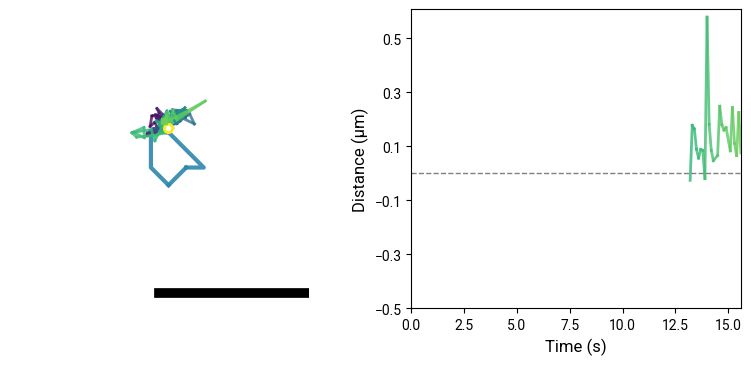

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-3_track_344.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-3, Track ID: 439
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-3
    ✅ 1/1 tracks interacting with 1147 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


First dwell time: 0.0, until 3.0
First time point int track_data: 0


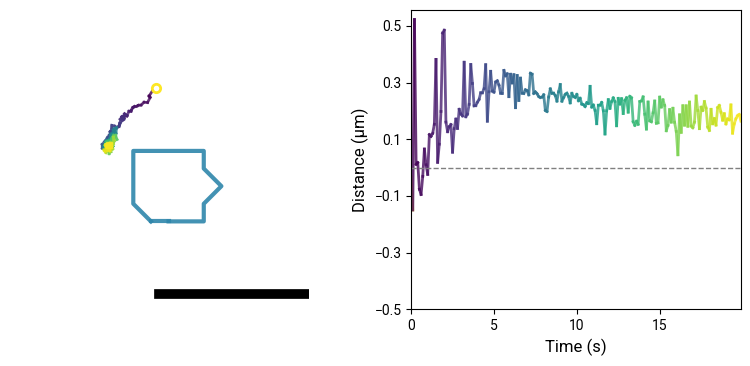

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-3_track_439.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-3, Track ID: 450
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-3
    ✅ 1/1 tracks interacting with 1161 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


First dwell time: 0.0, until 3.0
First time point int track_data: 0


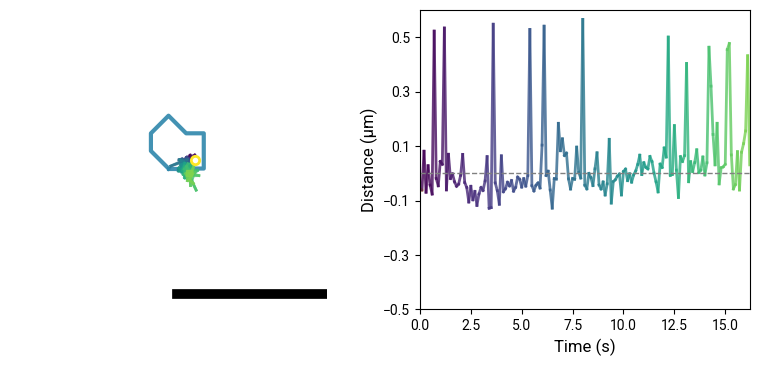

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-3_track_450.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-3, Track ID: 485
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-3
    ✅ 1/1 tracks interacting with 1185 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 49, trace_df has 39
First dwell time: 1.0, until 4.0
First time point int track_data: 0


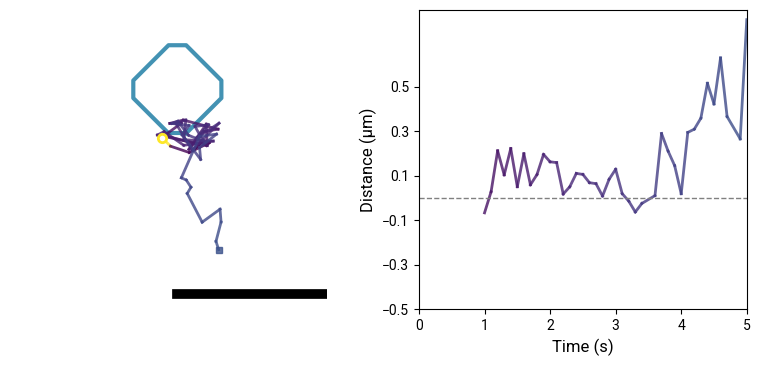

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-3_track_485.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-3, Track ID: 680
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-3
    ✅ 1/1 tracks interacting with 1147 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 200, trace_df has 180
First dwell time: 2.0, until 5.0
First time point int track_data: 0


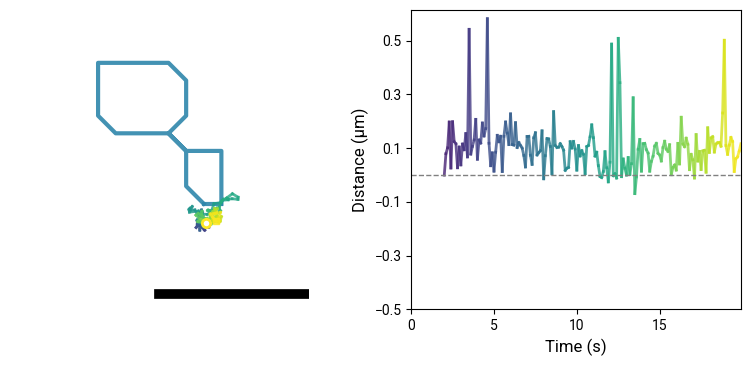

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-3_track_680.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-3, Track ID: 683
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-3
    ✅ 1/1 tracks interacting with 1147 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 200, trace_df has 123
First dwell time: 7.7, until 10.7
First time point int track_data: 0


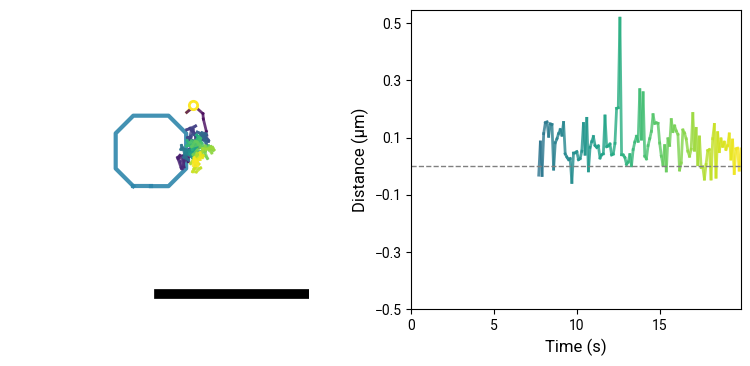

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-3_track_683.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-3, Track ID: 817
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-3
    ✅ 1/1 tracks interacting with 1175 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 43, trace_df has 38
First dwell time: 1.0, until 4.0
First time point int track_data: 4


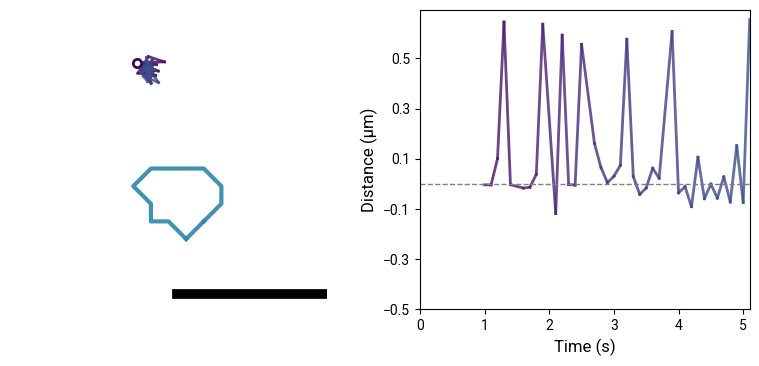

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-3_track_817.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-3, Track ID: 864
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-3
    ✅ 1/1 tracks interacting with 1190 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 18, trace_df has 14
First dwell time: 1.4, until 4.4
First time point int track_data: 10


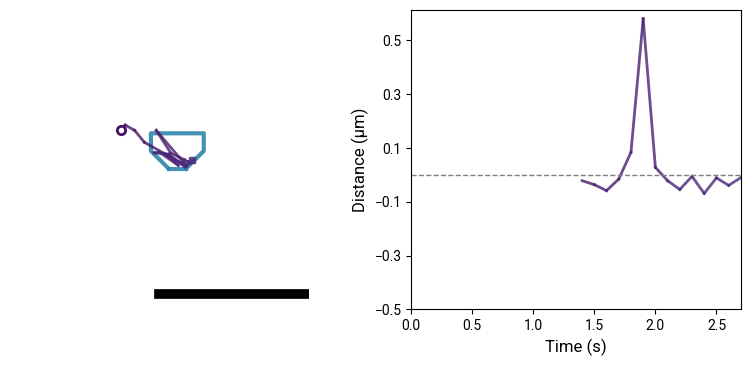

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-3_track_864.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-3, Track ID: 1786
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-3
    ✅ 1/1 tracks interacting with 1146 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 49, trace_df has 39
First dwell time: 3.9, until 6.9
First time point int track_data: 29


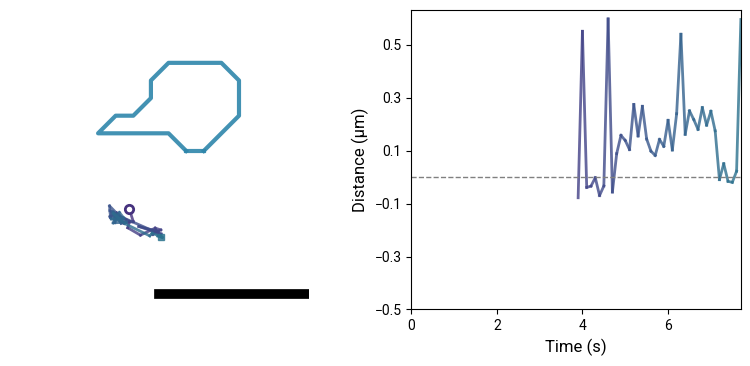

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-3_track_1786.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-3, Track ID: 1803
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-3
    ✅ 1/1 tracks interacting with 1193 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


First dwell time: 2.4000000000000004, until 5.4
First time point int track_data: 24


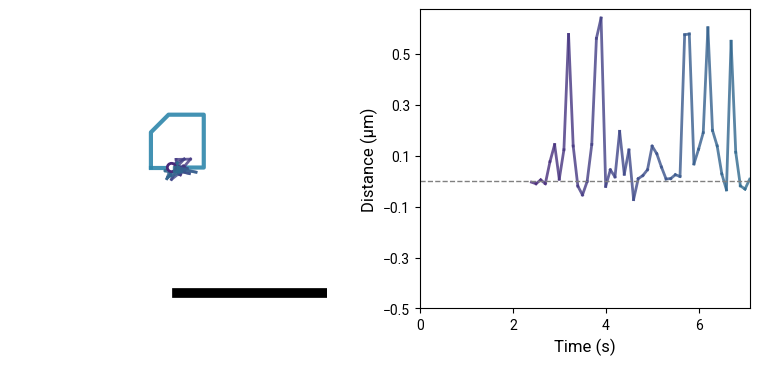

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-3_track_1803.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-3, Track ID: 2496
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-3
    ✅ 1/1 tracks interacting with 1147 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


First dwell time: 4.5, until 7.5
First time point int track_data: 45


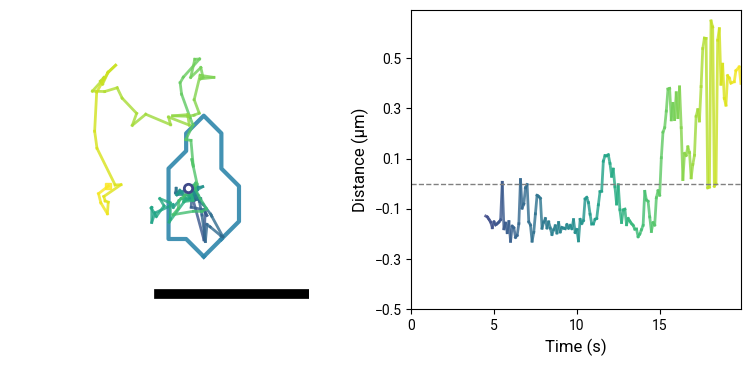

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-3_track_2496.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-3, Track ID: 3481
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-3
    ✅ 1/1 tracks interacting with 1184 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 14, trace_df has 12
First dwell time: 8.3, until 11.3
First time point int track_data: 81


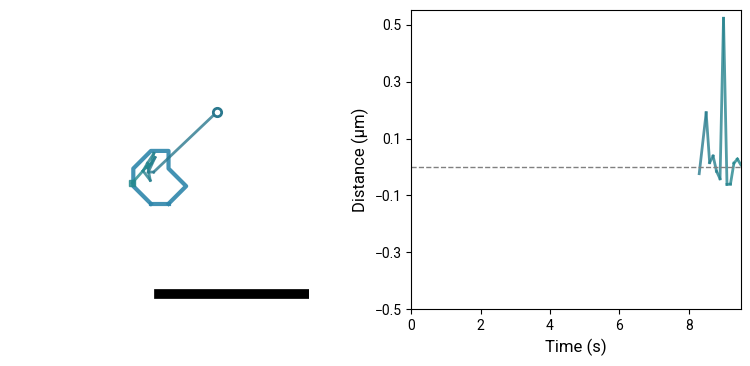

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-3_track_3481.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-3, Track ID: 3492
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-3
    ✅ 1/1 tracks interacting with 1134 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 20, trace_df has 18
First dwell time: 8.4, until 11.4
First time point int track_data: 82


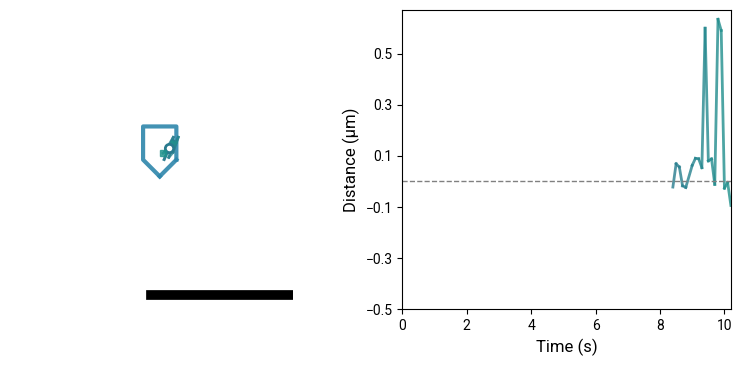

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-3_track_3492.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-3, Track ID: 3526
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-3
    ✅ 1/1 tracks interacting with 1180 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


First dwell time: 7.800000000000001, until 10.8
First time point int track_data: 78


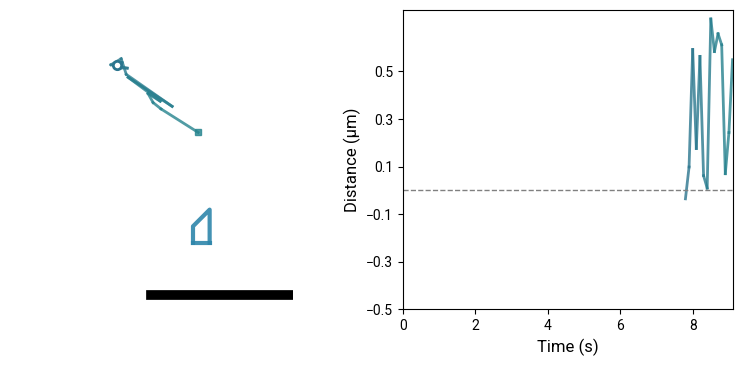

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-3_track_3526.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-3, Track ID: 3532
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-3
    ✅ 1/1 tracks interacting with 1166 condensates
Length of exp_results: 2
⚠️ Mismatch in number of points: track_data has 17, trace_df has 16


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


First dwell time: 7.6, until 10.6
First time point int track_data: 75


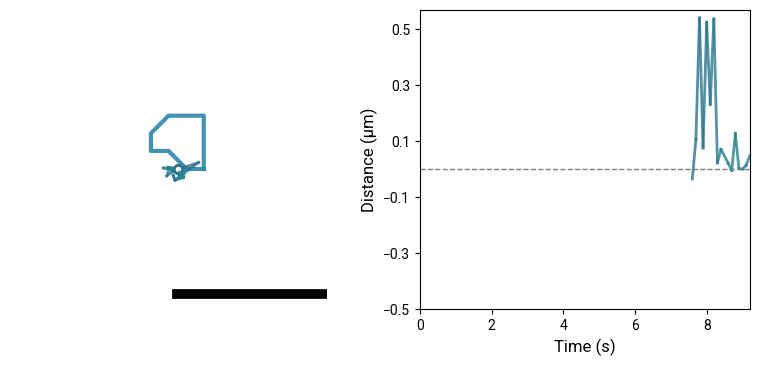

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-3_track_3532.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-3, Track ID: 3549
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-3
    ✅ 1/1 tracks interacting with 1141 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 16, trace_df has 15
First dwell time: 6.800000000000001, until 9.8
First time point int track_data: 67


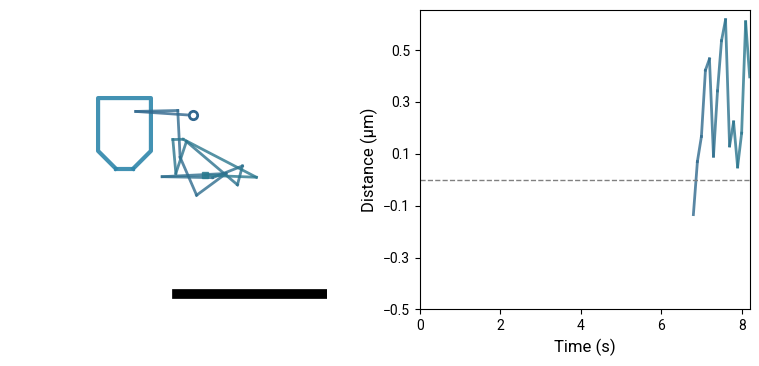

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-3_track_3549.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-3, Track ID: 4014
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-3
    ✅ 1/1 tracks interacting with 1150 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


First dwell time: 8.5, until 11.5
First time point int track_data: 85


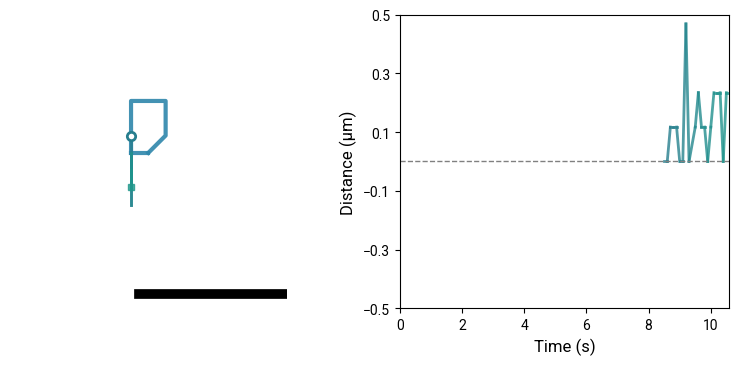

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-3_track_4014.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-3, Track ID: 4374
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-3
    ✅ 1/1 tracks interacting with 1173 condensates
Length of exp_results: 2
⚠️ Mismatch in number of points: track_data has 9, trace_df has 7
First dwell time: 10.3, until 13.3
First time point int track_data: 101


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


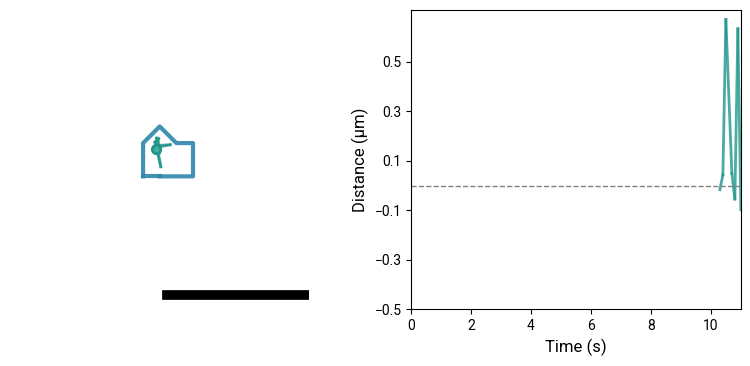

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-3_track_4374.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-3, Track ID: 4606
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-3
    ✅ 1/1 tracks interacting with 1180 condensates
Length of exp_results: 2
First dwell time: 11.3, until 14.3
First time point int track_data: 113


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


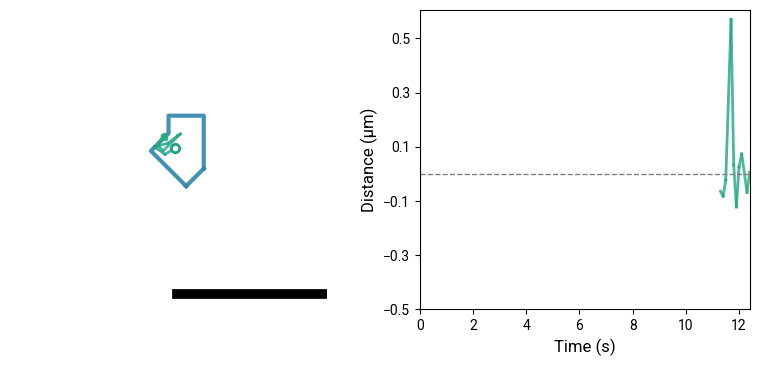

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-3_track_4606.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-3, Track ID: 5257
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-3
    ✅ 1/1 tracks interacting with 1148 condensates
Length of exp_results: 2
⚠️ Mismatch in number of points: track_data has 12, trace_df has 5
First dwell time: 15.2, until 18.2
First time point int track_data: 145


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


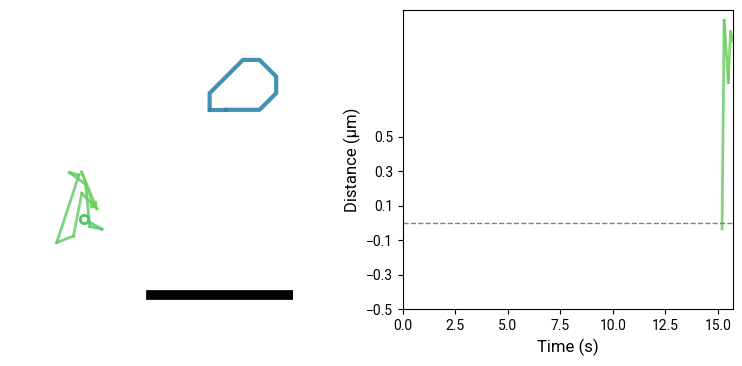

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-3_track_5257.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-3, Track ID: 5560
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-3
    ✅ 1/1 tracks interacting with 1156 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 8, trace_df has 5
First dwell time: 13.8, until 16.8
First time point int track_data: 135


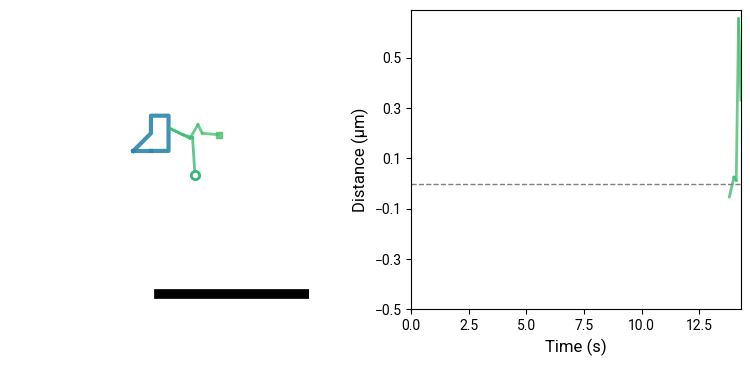

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-3_track_5560.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-3, Track ID: 5800
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-3
    ✅ 1/1 tracks interacting with 1147 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


First dwell time: 15.8, until 18.8
First time point int track_data: 158


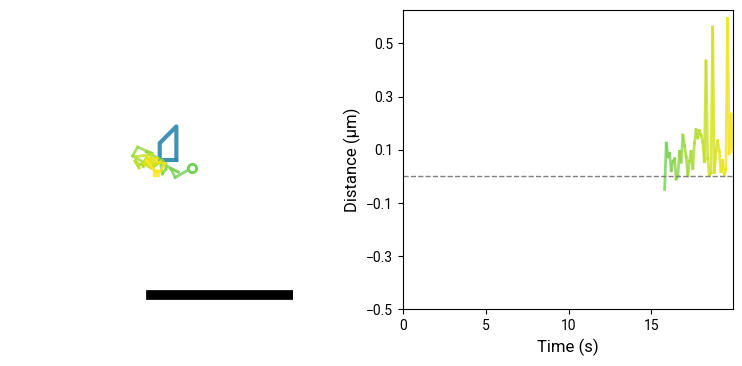

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-3_track_5800.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-23, Track ID: 22
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-23
    ✅ 1/1 tracks interacting with 543 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 90, trace_df has 35
First dwell time: 5.6000000000000005, until 8.600000000000001
First time point int track_data: 0


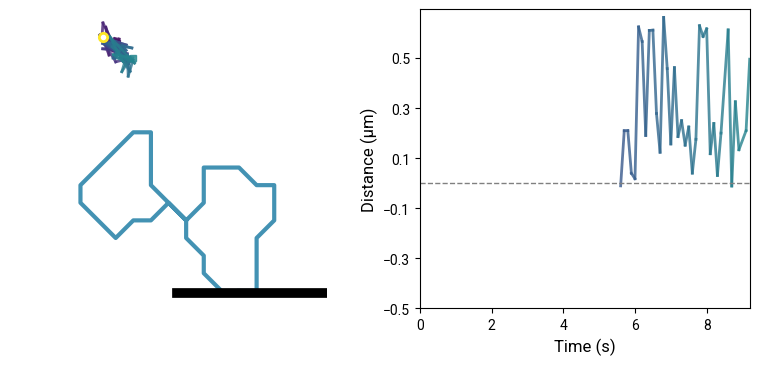

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-23_track_22.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-23, Track ID: 71
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-23
    ✅ 1/1 tracks interacting with 556 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 56, trace_df has 11
First dwell time: 4.6000000000000005, until 7.6000000000000005
First time point int track_data: 0


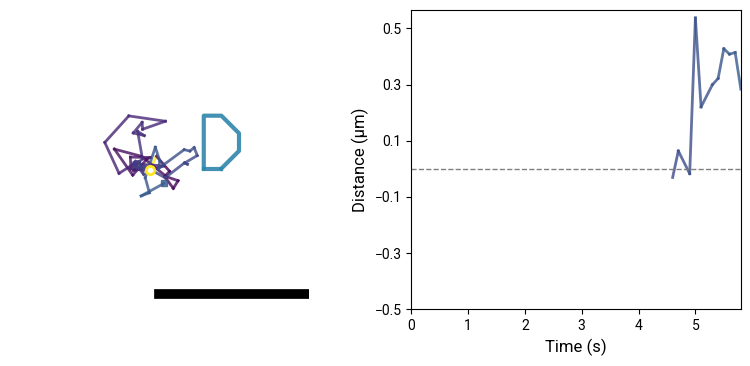

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-23_track_71.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-23, Track ID: 97
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-23
    ✅ 1/1 tracks interacting with 557 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 165, trace_df has 142
First dwell time: 2.3000000000000003, until 5.300000000000001
First time point int track_data: 0


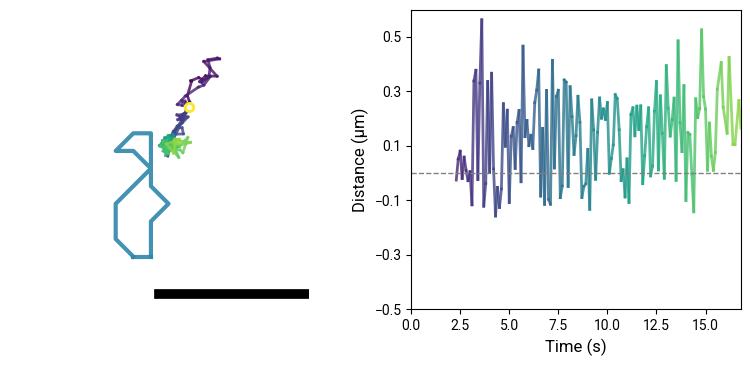

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-23_track_97.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-23, Track ID: 452
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-23
    ✅ 1/1 tracks interacting with 544 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 39, trace_df has 15
First dwell time: 2.4000000000000004, until 5.4
First time point int track_data: 0


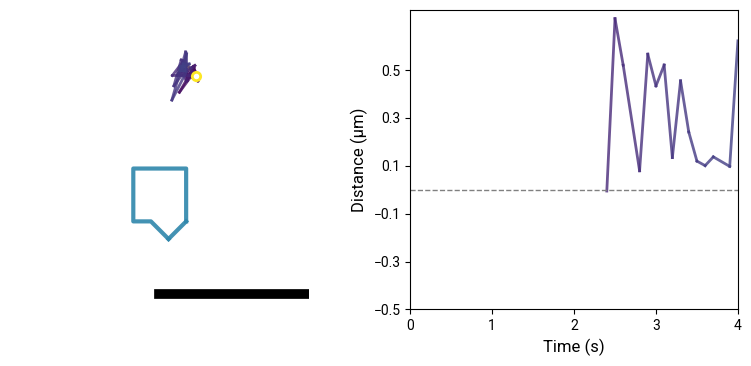

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-23_track_452.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-23, Track ID: 460
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-23
    ✅ 1/1 tracks interacting with 545 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 197, trace_df has 194
First dwell time: 0.3, until 3.3
First time point int track_data: 0


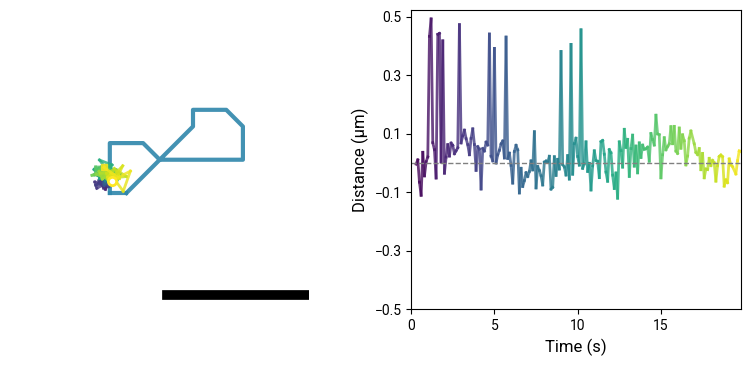

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-23_track_460.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-23, Track ID: 545
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-23
    ✅ 1/1 tracks interacting with 549 condensates
Length of exp_results: 2
First dwell time: 0.0, until 3.0
First time point int track_data: 0


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


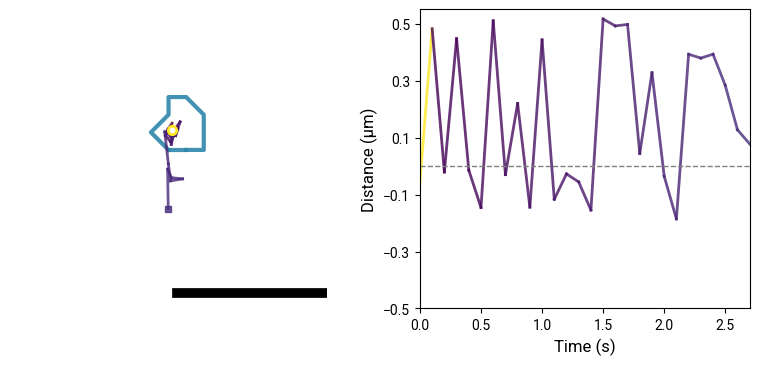

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-23_track_545.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-23, Track ID: 749
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-23
    ✅ 1/1 tracks interacting with 558 condensates
Length of exp_results: 2
First dwell time: 0.3, until 3.3
First time point int track_data: 3


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


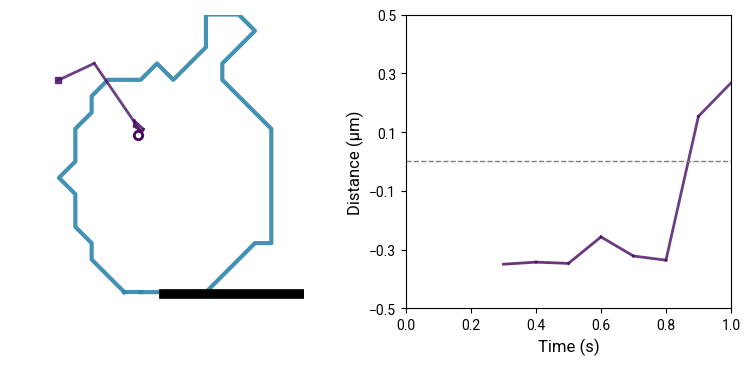

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-23_track_749.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-23, Track ID: 1366
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-23
    ✅ 1/1 tracks interacting with 548 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


First dwell time: 2.7, until 5.7
First time point int track_data: 27


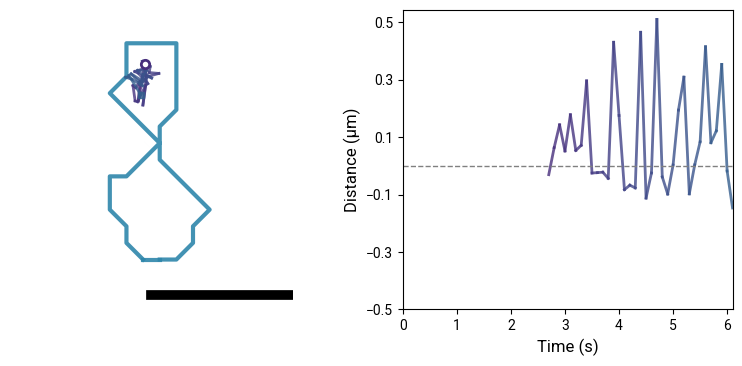

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-23_track_1366.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-23, Track ID: 1493
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-23
    ✅ 1/1 tracks interacting with 542 condensates
Length of exp_results: 2
First dwell time: 3.3000000000000003, until 6.300000000000001
First time point int track_data: 33


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


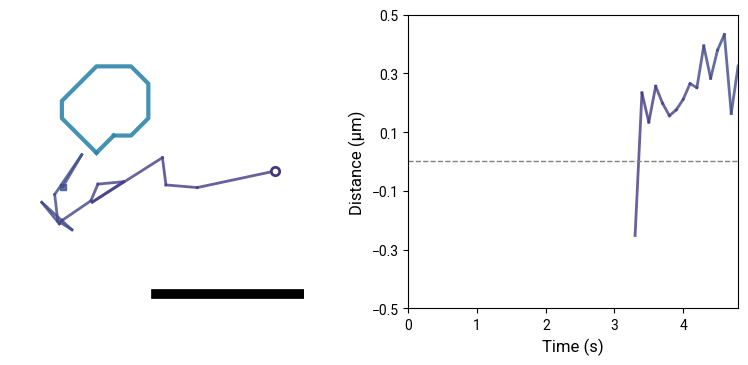

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-23_track_1493.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-23, Track ID: 1733
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-23
    ✅ 1/1 tracks interacting with 556 condensates
Length of exp_results: 2
⚠️ Mismatch in number of points: track_data has 13, trace_df has 3
First dwell time: 5.6000000000000005, until 8.600000000000001
First time point int track_data: 45


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


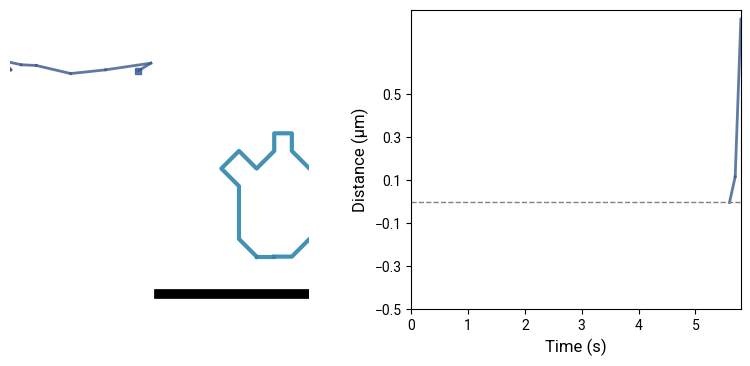

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-23_track_1733.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-23, Track ID: 3399
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-23
    ✅ 1/1 tracks interacting with 548 condensates
Length of exp_results: 2
⚠️ Mismatch in number of points: track_data has 13, trace_df has 11
First dwell time: 11.3, until 14.3
First time point int track_data: 111


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


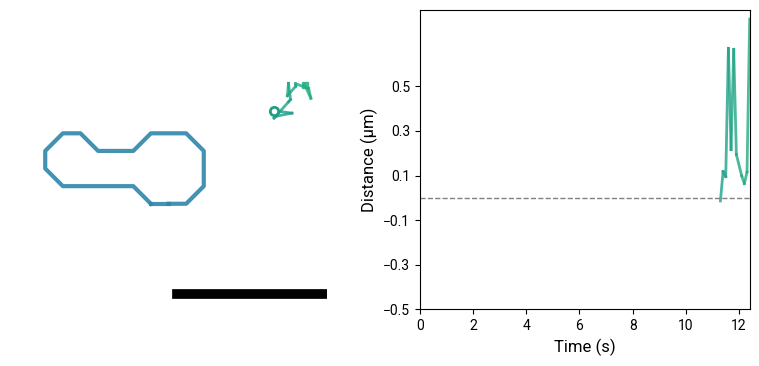

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-23_track_3399.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-23, Track ID: 3836
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-23
    ✅ 1/1 tracks interacting with 541 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


First dwell time: 14.5, until 17.5
First time point int track_data: 145


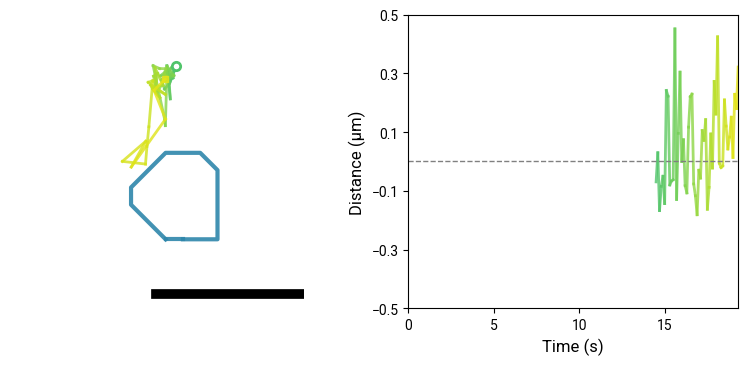

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-23_track_3836.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-23, Track ID: 4207
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-23
    ✅ 1/1 tracks interacting with 548 condensates
Length of exp_results: 2
First dwell time: 17.400000000000002, until 20.400000000000002
First time point int track_data: 174


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


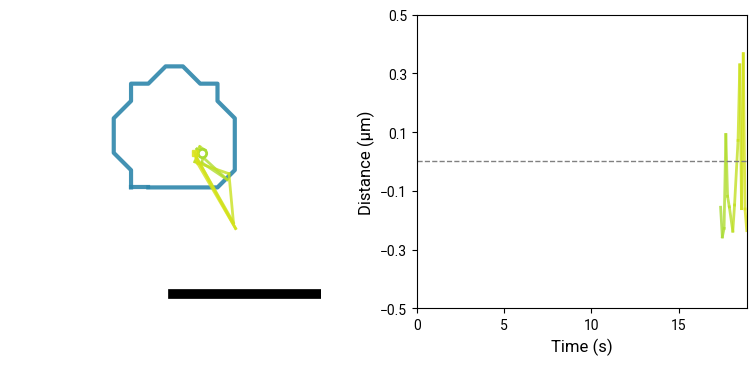

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-23_track_4207.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-11, Track ID: 67
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-11
    ✅ 1/1 tracks interacting with 989 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 103, trace_df has 102
First dwell time: 0.1, until 3.1
First time point int track_data: 0


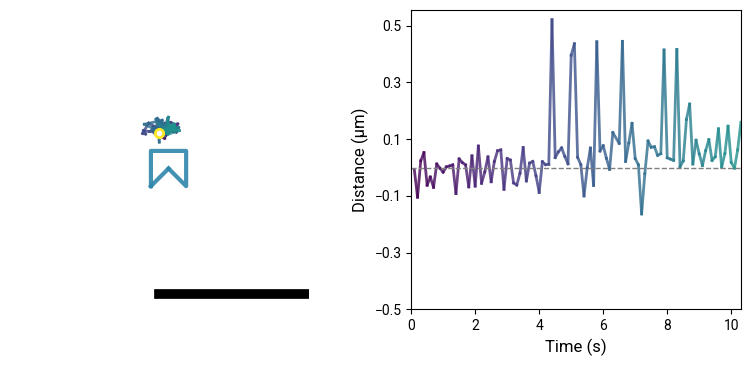

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-11_track_67.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-11, Track ID: 186
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-11
    ✅ 1/1 tracks interacting with 977 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 163, trace_df has 148
First dwell time: 1.5, until 4.5
First time point int track_data: 0


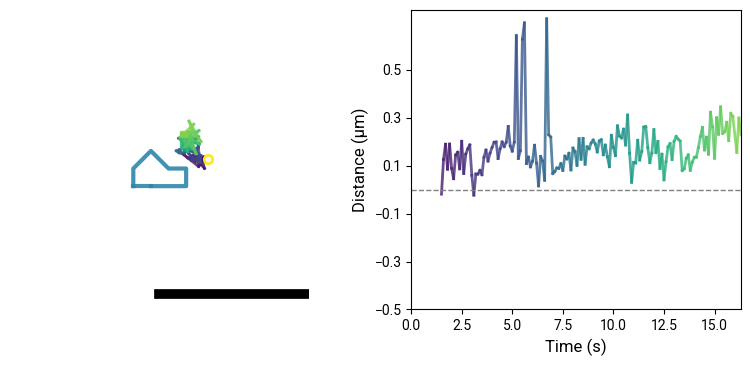

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-11_track_186.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-11, Track ID: 659
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-11
    ✅ 1/1 tracks interacting with 998 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 42, trace_df has 33
First dwell time: 1.1, until 4.1
First time point int track_data: 1


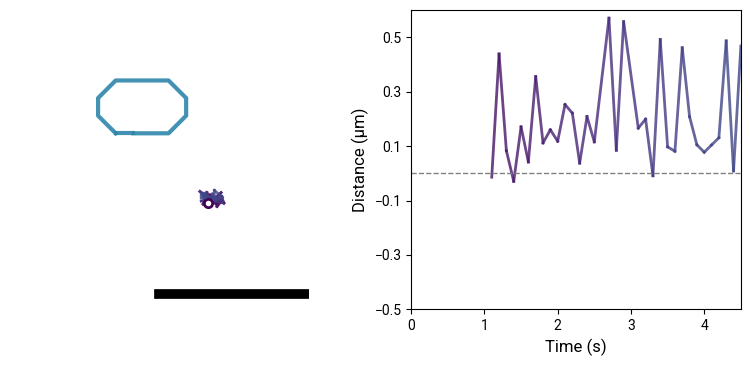

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-11_track_659.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-11, Track ID: 660
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-11
    ✅ 1/1 tracks interacting with 982 condensates
Length of exp_results: 2
⚠️ Mismatch in number of points: track_data has 11, trace_df has 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


First dwell time: 1.0, until 4.0
First time point int track_data: 0


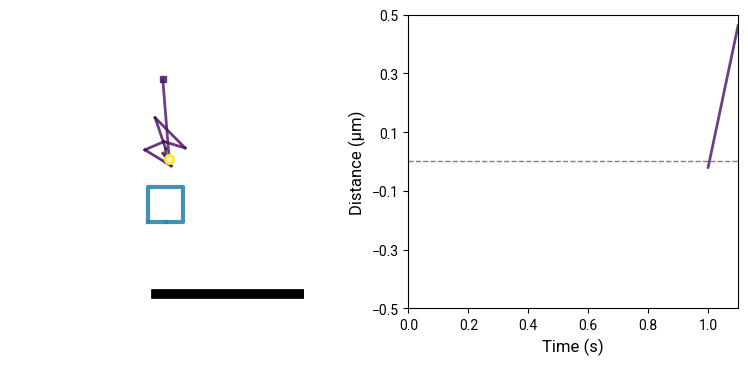

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-11_track_660.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-11, Track ID: 988
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-11
    ✅ 1/1 tracks interacting with 998 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


First dwell time: 1.7000000000000002, until 4.7
First time point int track_data: 17


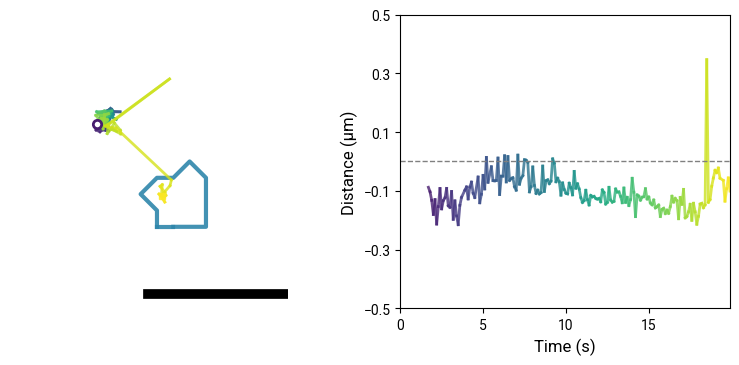

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-11_track_988.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-11, Track ID: 1225
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-11
    ✅ 1/1 tracks interacting with 989 condensates
Length of exp_results: 2
⚠️ Mismatch in number of points: track_data has 16, trace_df has 5


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


First dwell time: 3.9, until 6.9
First time point int track_data: 26


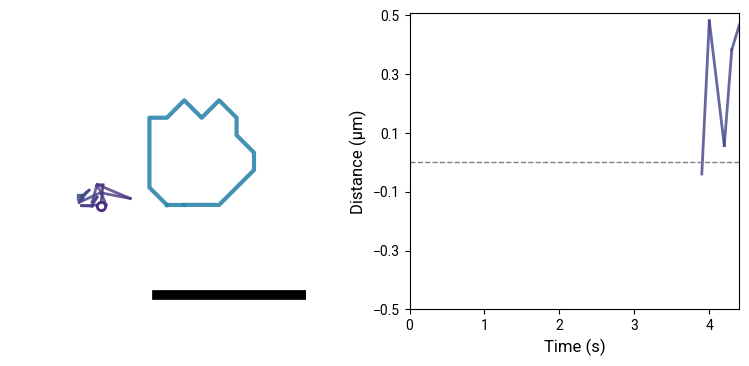

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-11_track_1225.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-11, Track ID: 2013
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-11
    ✅ 1/1 tracks interacting with 989 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 79, trace_df has 64
First dwell time: 7.800000000000001, until 10.8
First time point int track_data: 63


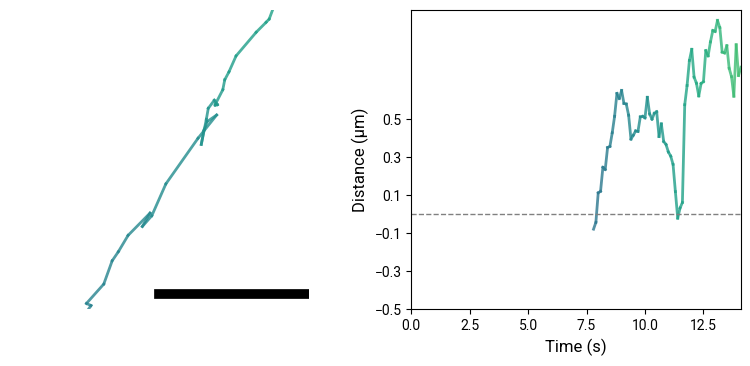

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-11_track_2013.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-11, Track ID: 2426
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-11
    ✅ 1/1 tracks interacting with 1006 condensates
Length of exp_results: 2
First dwell time: 6.7, until 9.7
First time point int track_data: 67


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


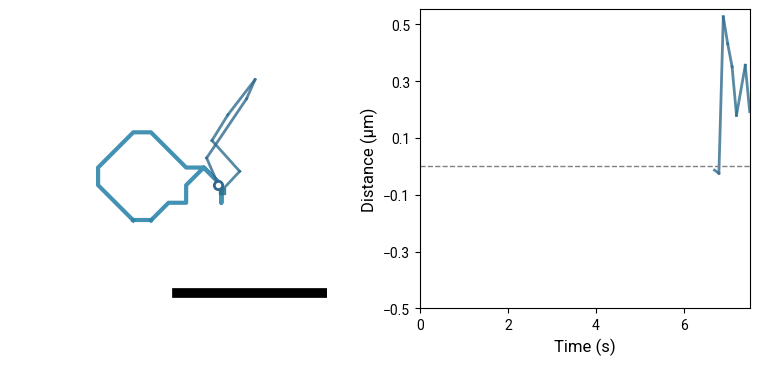

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-11_track_2426.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-11, Track ID: 4239
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-11
    ✅ 1/1 tracks interacting with 971 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 31, trace_df has 9
First dwell time: 17.900000000000002, until 20.900000000000002
First time point int track_data: 155


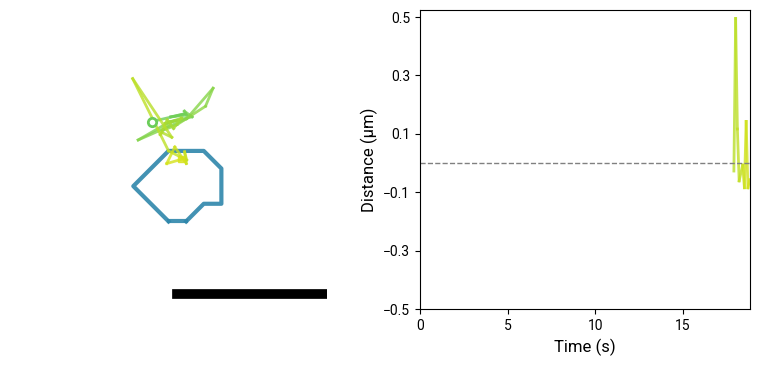

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-11_track_4239.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-24, Track ID: 432
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-24
    ✅ 1/1 tracks interacting with 715 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 200, trace_df has 51
First dwell time: 14.9, until 17.9
First time point int track_data: 0


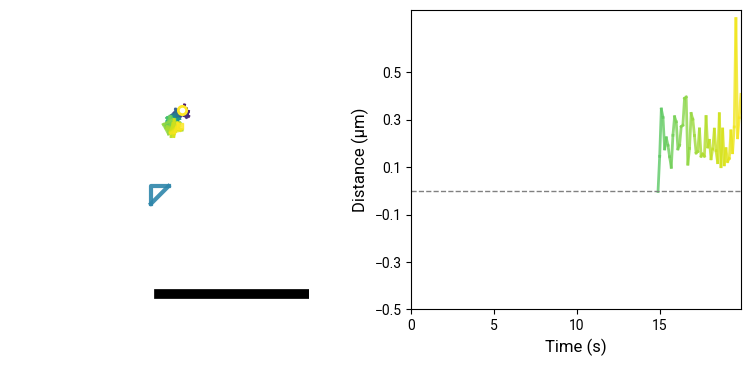

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-24_track_432.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-24, Track ID: 686
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-24
    ✅ 1/1 tracks interacting with 731 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 108, trace_df has 99
First dwell time: 0.9, until 3.9
First time point int track_data: 0


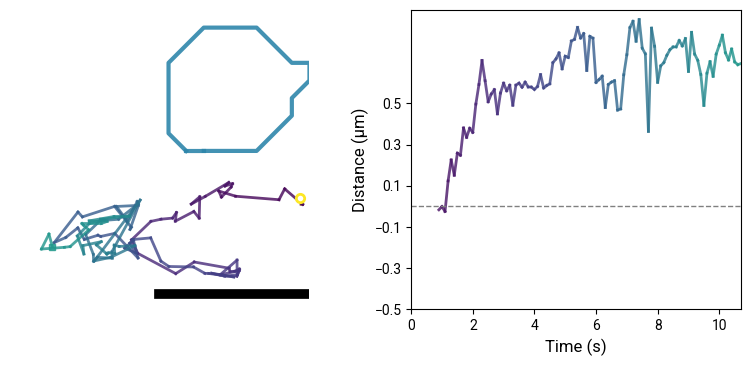

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-24_track_686.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-24, Track ID: 748
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-24
    ✅ 1/1 tracks interacting with 724 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


First dwell time: 0.0, until 3.0
First time point int track_data: 0


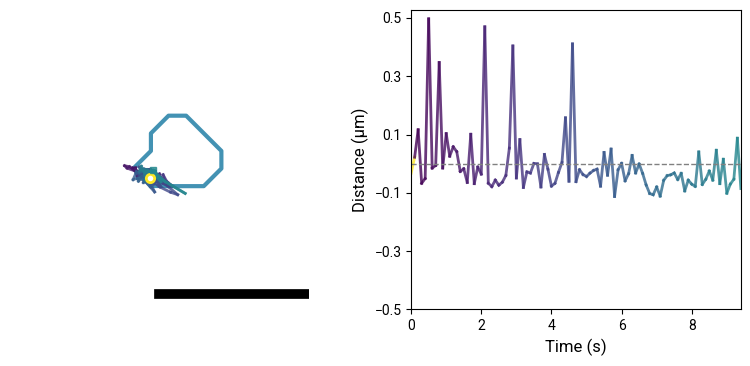

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-24_track_748.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-24, Track ID: 1149
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-24
    ✅ 1/1 tracks interacting with 727 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


First dwell time: 1.8, until 4.8
First time point int track_data: 18


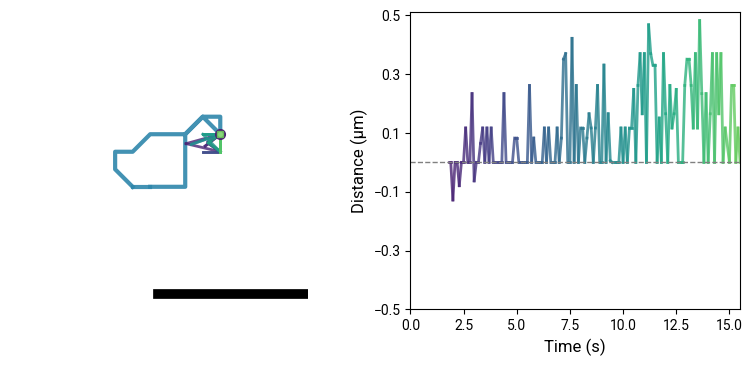

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-24_track_1149.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-24, Track ID: 1816
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-24
    ✅ 1/1 tracks interacting with 726 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 36, trace_df has 5
First dwell time: 6.2, until 9.2
First time point int track_data: 31


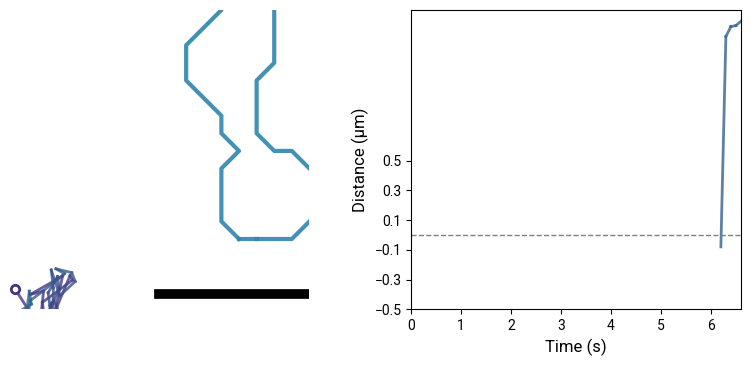

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-24_track_1816.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-24, Track ID: 2027
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-24
    ✅ 1/1 tracks interacting with 730 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


First dwell time: 3.3000000000000003, until 6.300000000000001
First time point int track_data: 33


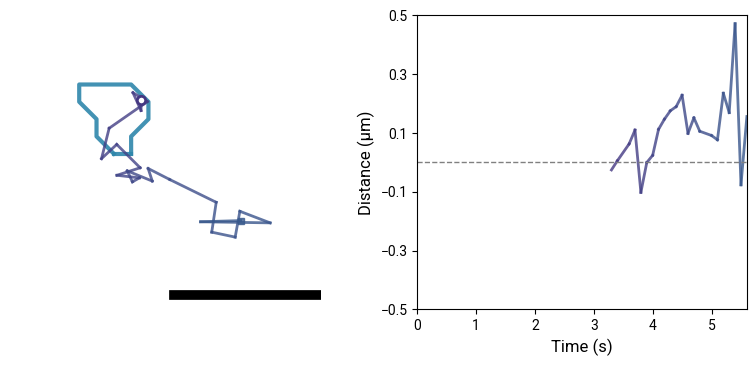

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-24_track_2027.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-24, Track ID: 2156
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-24
    ✅ 1/1 tracks interacting with 728 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 35, trace_df has 32
First dwell time: 4.3, until 7.3
First time point int track_data: 40


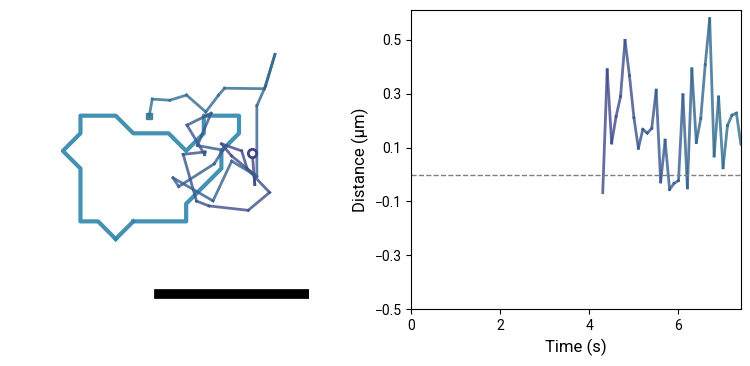

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-24_track_2156.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-24, Track ID: 2169
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-24
    ✅ 1/1 tracks interacting with 732 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 23, trace_df has 22
First dwell time: 4.0, until 7.0
First time point int track_data: 39


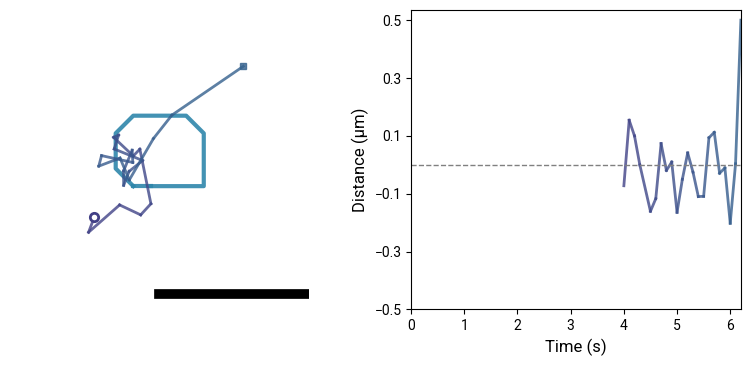

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-24_track_2169.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-24, Track ID: 2852
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-24
    ✅ 1/1 tracks interacting with 725 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 56, trace_df has 34
First dwell time: 7.800000000000001, until 10.8
First time point int track_data: 56


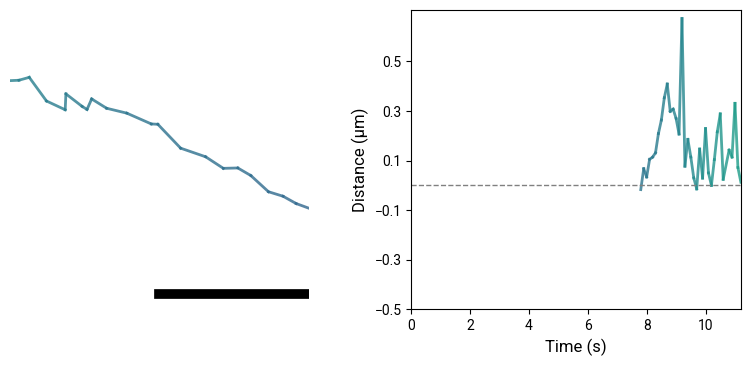

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-24_track_2852.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-24, Track ID: 3310
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-24
    ✅ 1/1 tracks interacting with 716 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 19, trace_df has 10
First dwell time: 8.700000000000001, until 11.700000000000001
First time point int track_data: 78


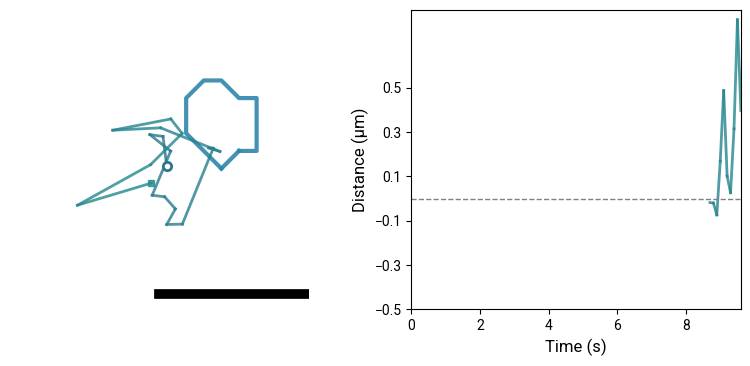

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-24_track_3310.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-24, Track ID: 3866
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-24
    ✅ 1/1 tracks interacting with 739 condensates
Length of exp_results: 2
⚠️ Mismatch in number of points: track_data has 9, trace_df has 6
First dwell time: 9.3, until 12.3
First time point int track_data: 90


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


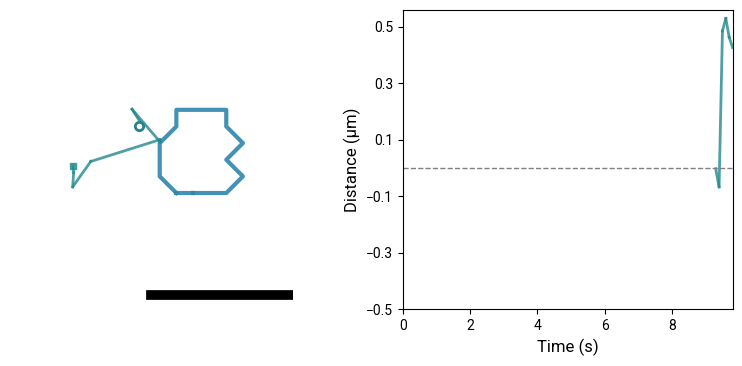

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-24_track_3866.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-24, Track ID: 4903
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-24
    ✅ 1/1 tracks interacting with 714 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


First dwell time: 12.6, until 15.6
First time point int track_data: 126


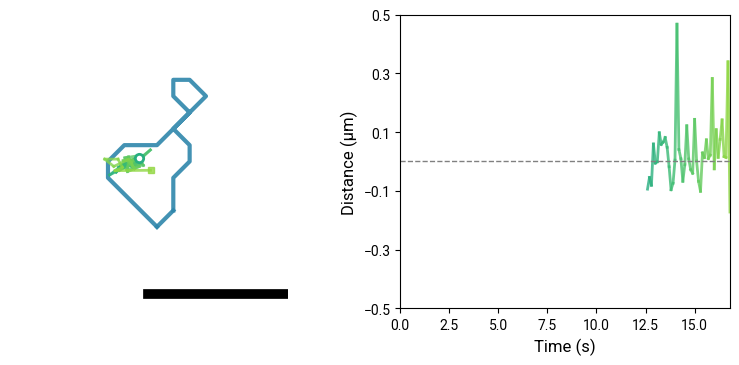

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-24_track_4903.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-24, Track ID: 5294
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-24
    ✅ 1/1 tracks interacting with 717 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 14, trace_df has 9
First dwell time: 14.6, until 17.6
First time point int track_data: 140


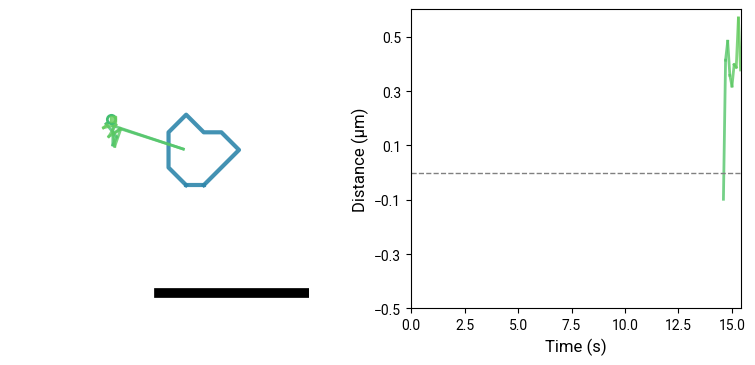

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-24_track_5294.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-24, Track ID: 5353
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-24
    ✅ 1/1 tracks interacting with 714 condensates
Length of exp_results: 2
⚠️ Mismatch in number of points: track_data has 18, trace_df has 13


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


First dwell time: 15.1, until 18.1
First time point int track_data: 145


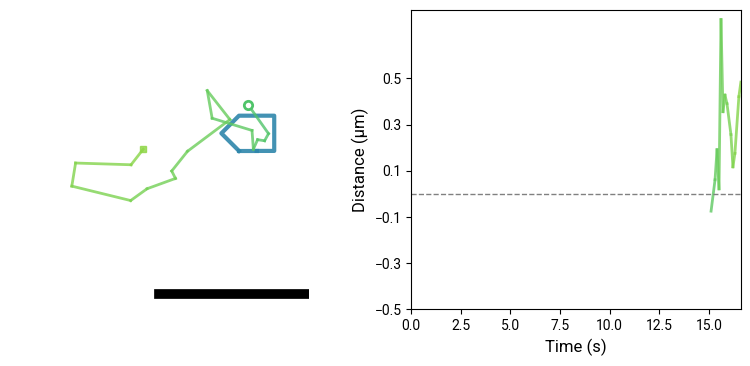

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-24_track_5353.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-24, Track ID: 5695
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-24
    ✅ 1/1 tracks interacting with 715 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


First dwell time: 17.7, until 20.7
First time point int track_data: 177


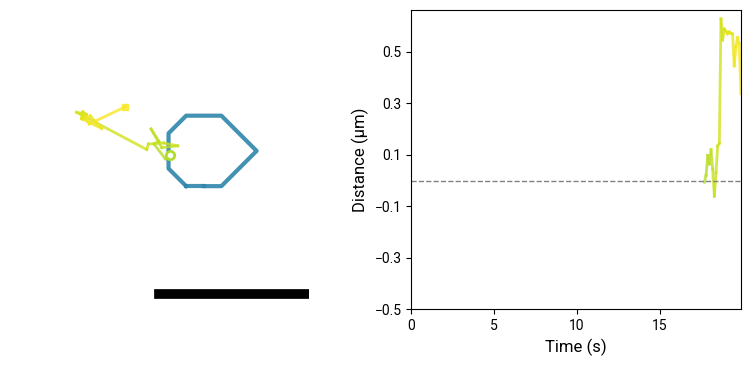

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-24_track_5695.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-24, Track ID: 5852
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-24
    ✅ 1/1 tracks interacting with 713 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


First dwell time: 16.0, until 19.0
First time point int track_data: 160


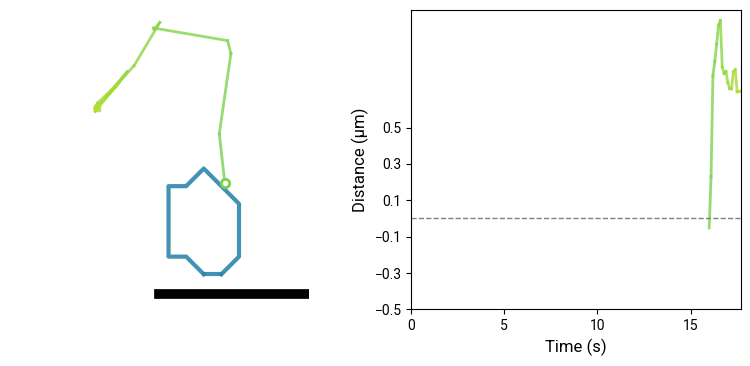

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-24_track_5852.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-24, Track ID: 6308
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-24
    ✅ 1/1 tracks interacting with 715 condensates
Length of exp_results: 2
⚠️ Mismatch in number of points: track_data has 8, trace_df has 5
First dwell time: 19.5, until 22.5
First time point int track_data: 192


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


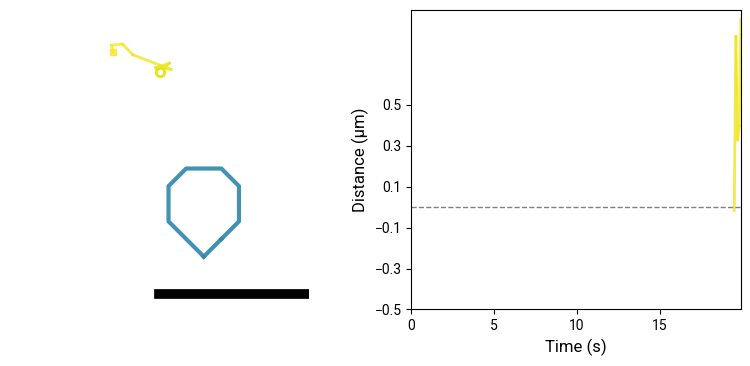

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-24_track_6308.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-4, Track ID: 323
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-4
    ✅ 1/1 tracks interacting with 972 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 146, trace_df has 133
First dwell time: 1.3, until 4.3
First time point int track_data: 0


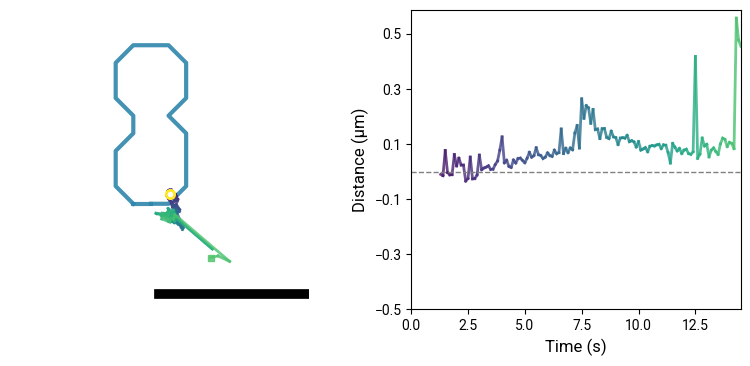

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-4_track_323.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-4, Track ID: 413
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-4
    ✅ 1/1 tracks interacting with 979 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 88, trace_df has 87
First dwell time: 0.1, until 3.1
First time point int track_data: 0


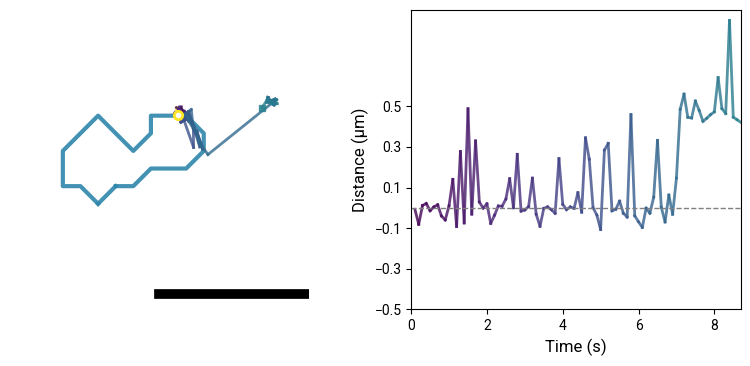

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-4_track_413.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-4, Track ID: 414
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-4
    ✅ 1/1 tracks interacting with 981 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 31, trace_df has 26
First dwell time: 0.5, until 3.5
First time point int track_data: 0


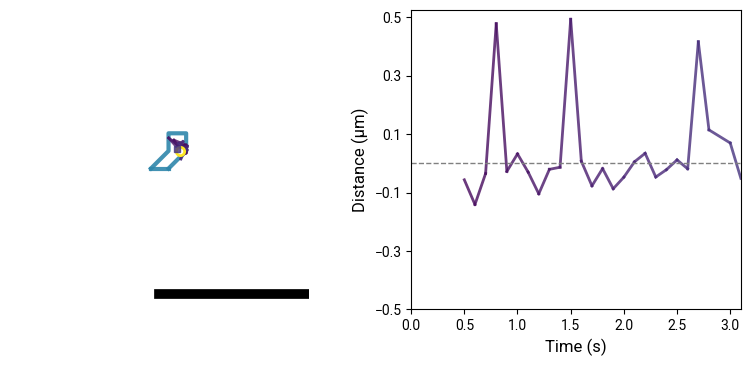

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-4_track_414.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-4, Track ID: 563
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-4
    ✅ 1/1 tracks interacting with 965 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 97, trace_df has 27
First dwell time: 7.300000000000001, until 10.3
First time point int track_data: 0


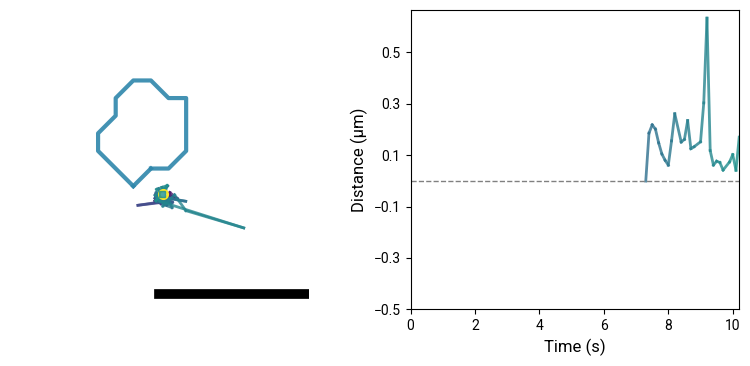

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-4_track_563.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-4, Track ID: 894
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-4
    ✅ 1/1 tracks interacting with 965 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 200, trace_df has 12
First dwell time: 18.8, until 21.8
First time point int track_data: 0


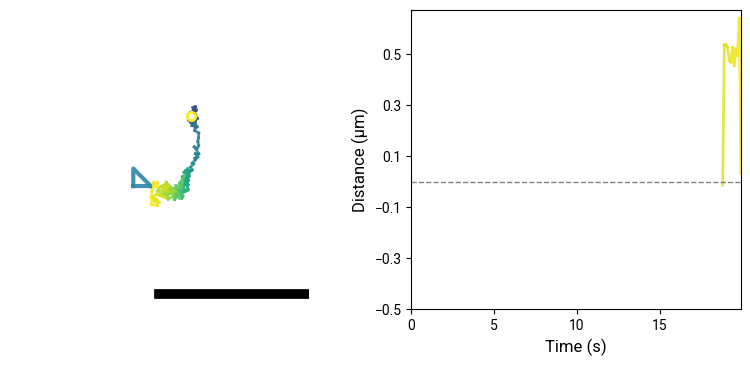

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-4_track_894.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-4, Track ID: 1052
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-4
    ✅ 1/1 tracks interacting with 982 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 167, trace_df has 81
First dwell time: 8.6, until 11.6
First time point int track_data: 0


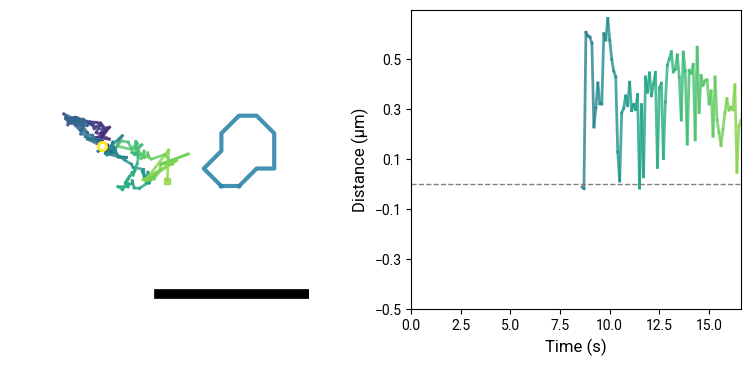

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-4_track_1052.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-4, Track ID: 1137
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-4
    ✅ 1/1 tracks interacting with 967 condensates
Length of exp_results: 2
⚠️ Mismatch in number of points: track_data has 9, trace_df has 7


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


First dwell time: 0.2, until 3.2
First time point int track_data: 0


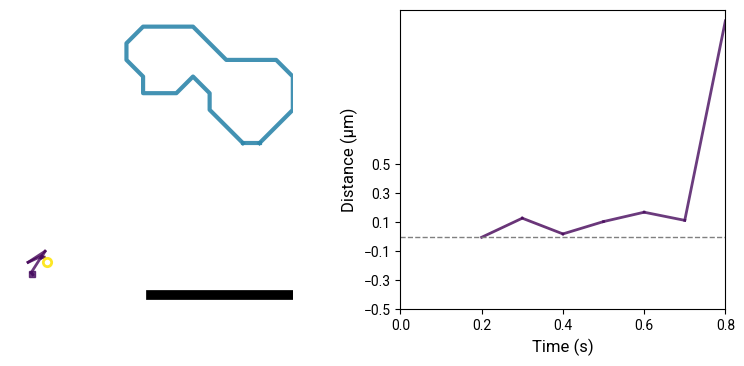

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-4_track_1137.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-4, Track ID: 1304
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-4
    ✅ 1/1 tracks interacting with 968 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 96, trace_df has 19
First dwell time: 8.0, until 11.0
First time point int track_data: 2


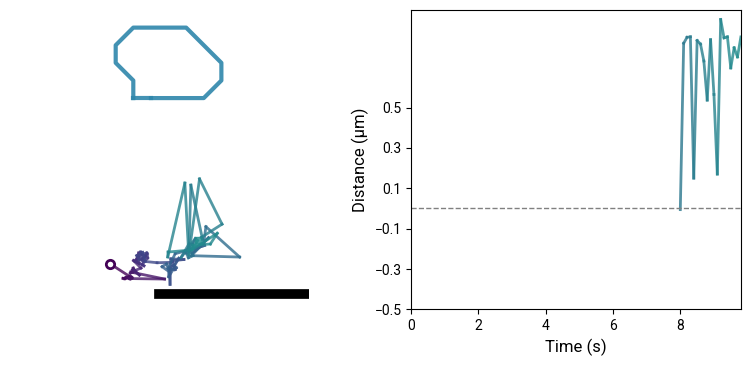

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-4_track_1304.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-4, Track ID: 1734
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-4
    ✅ 1/1 tracks interacting with 979 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 76, trace_df has 35
First dwell time: 5.1000000000000005, until 8.100000000000001
First time point int track_data: 10


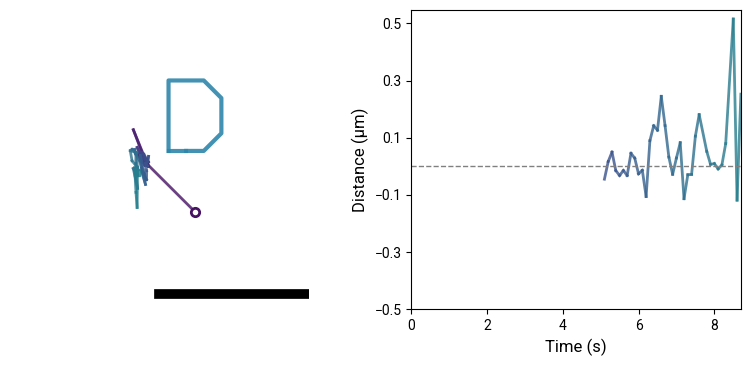

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-4_track_1734.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-4, Track ID: 2191
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-4
    ✅ 1/1 tracks interacting with 991 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 9, trace_df has 7
First dwell time: 2.3000000000000003, until 5.300000000000001
First time point int track_data: 21


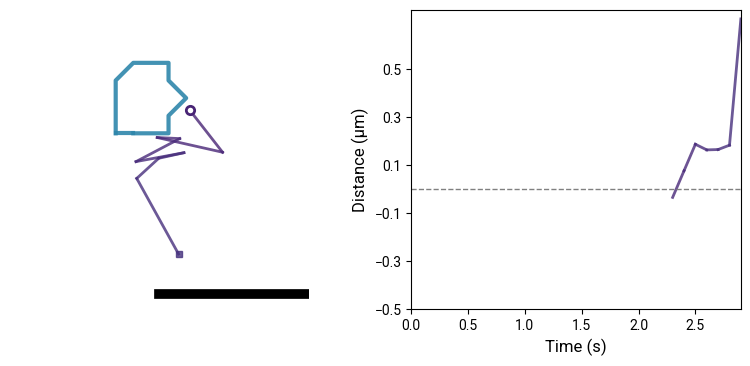

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-4_track_2191.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-4, Track ID: 2465
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-4
    ✅ 1/1 tracks interacting with 966 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


First dwell time: 2.3000000000000003, until 5.300000000000001
First time point int track_data: 23


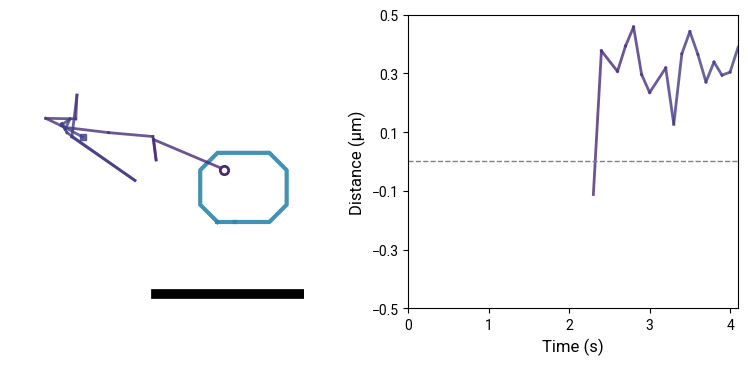

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-4_track_2465.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-4, Track ID: 4020
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-4
    ✅ 1/1 tracks interacting with 972 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 65, trace_df has 13
First dwell time: 10.8, until 13.8
First time point int track_data: 56


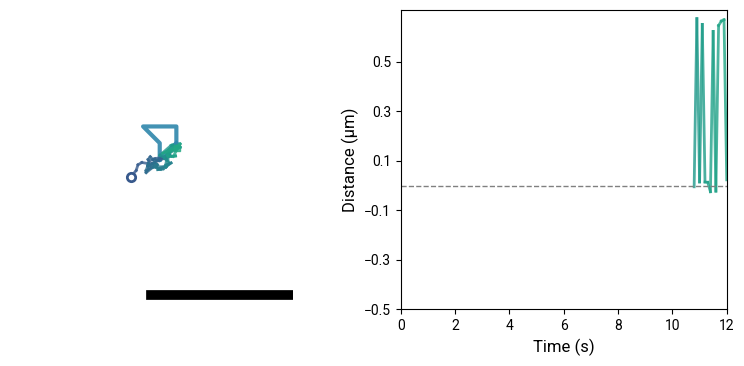

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-4_track_4020.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-4, Track ID: 4556
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-4
    ✅ 1/1 tracks interacting with 979 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 33, trace_df has 32
First dwell time: 7.0, until 10.0
First time point int track_data: 69


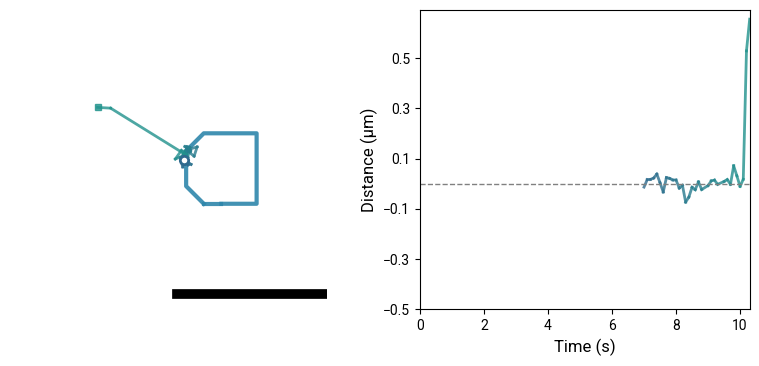

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-4_track_4556.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-4, Track ID: 4637
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-4
    ✅ 1/1 tracks interacting with 987 condensates
Length of exp_results: 2
First dwell time: 6.6000000000000005, until 9.600000000000001
First time point int track_data: 66


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


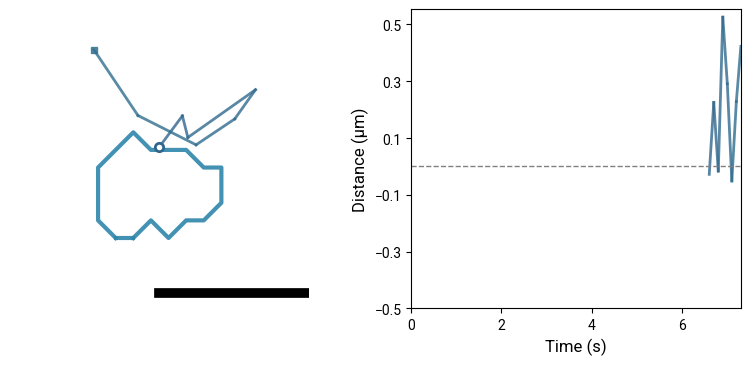

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-4_track_4637.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-4, Track ID: 5161
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-4
    ✅ 1/1 tracks interacting with 969 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 71, trace_df has 70
First dwell time: 7.5, until 10.5
First time point int track_data: 74


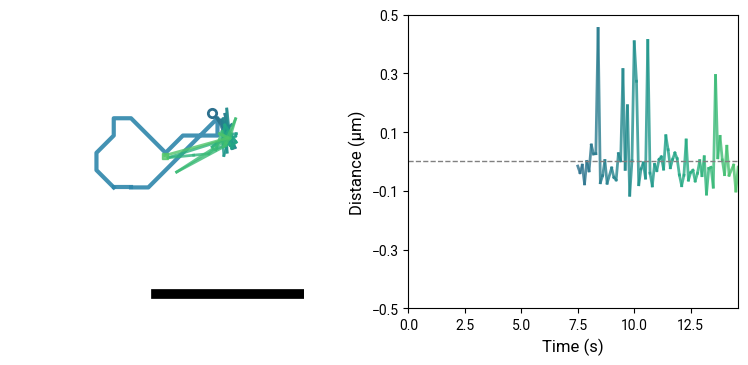

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-4_track_5161.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-4, Track ID: 5515
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-4
    ✅ 1/1 tracks interacting with 975 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


First dwell time: 8.6, until 11.6
First time point int track_data: 86


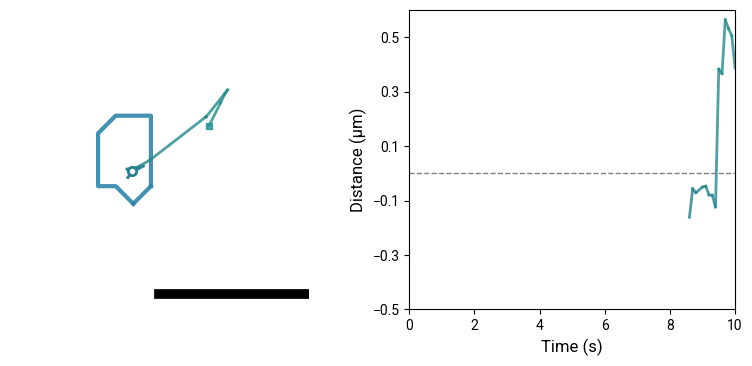

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-4_track_5515.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-4, Track ID: 5994
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-4
    ✅ 1/1 tracks interacting with 982 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 25, trace_df has 16
First dwell time: 11.4, until 14.4
First time point int track_data: 104


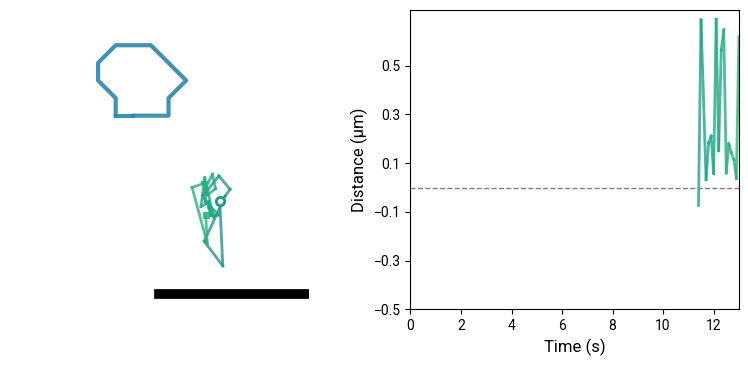

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-4_track_5994.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-4, Track ID: 6002
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-4
    ✅ 1/1 tracks interacting with 979 condensates
Length of exp_results: 2
⚠️ Mismatch in number of points: track_data has 16, trace_df has 14


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


First dwell time: 11.0, until 14.0
First time point int track_data: 108


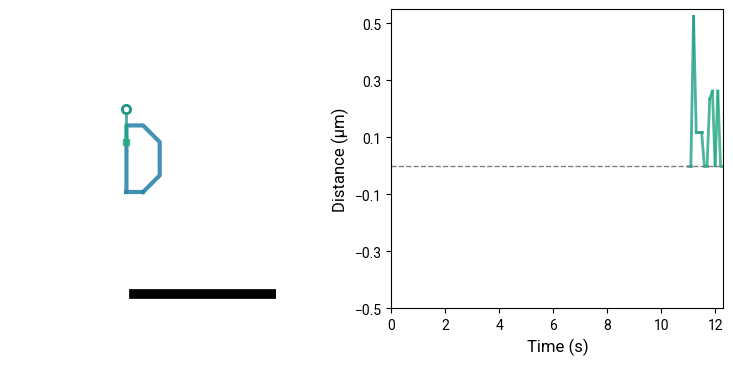

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-4_track_6002.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-4, Track ID: 7019
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-4
    ✅ 1/1 tracks interacting with 978 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


First dwell time: 12.0, until 15.0
First time point int track_data: 120


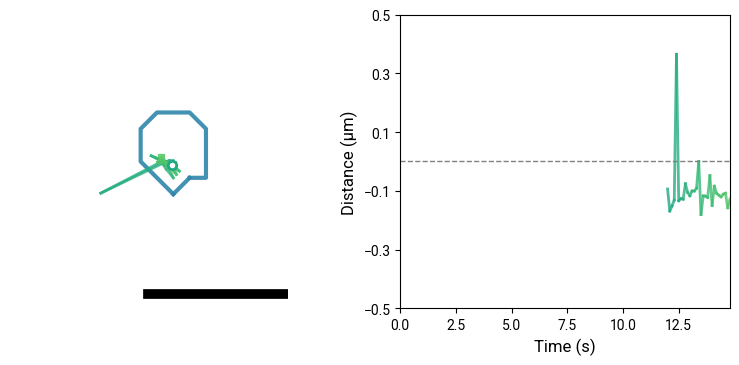

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-4_track_7019.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-4, Track ID: 8038
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-4
    ✅ 1/1 tracks interacting with 982 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


First dwell time: 14.7, until 17.7
First time point int track_data: 147


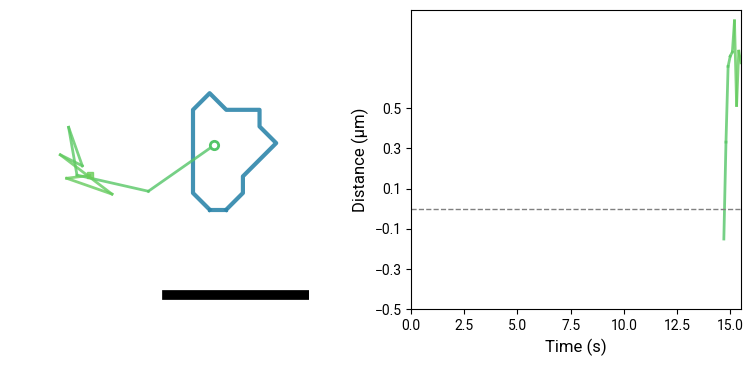

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-4_track_8038.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-4, Track ID: 8712
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-4
    ✅ 1/1 tracks interacting with 965 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 28, trace_df has 19
First dwell time: 18.1, until 21.1
First time point int track_data: 172


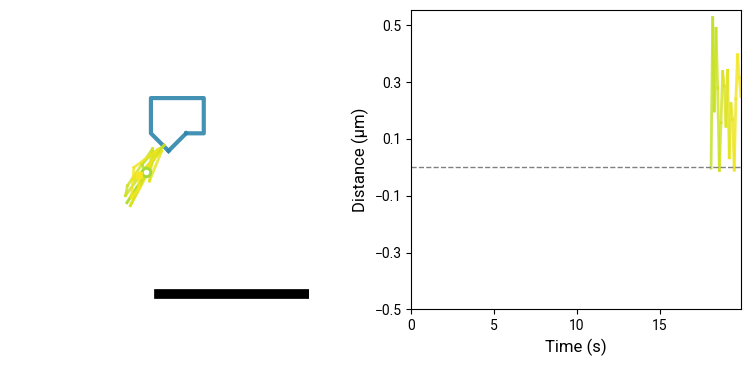

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-4_track_8712.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-16, Track ID: 90
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-16
    ✅ 1/1 tracks interacting with 374 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 64, trace_df has 42
First dwell time: 2.4000000000000004, until 5.4
First time point int track_data: 2


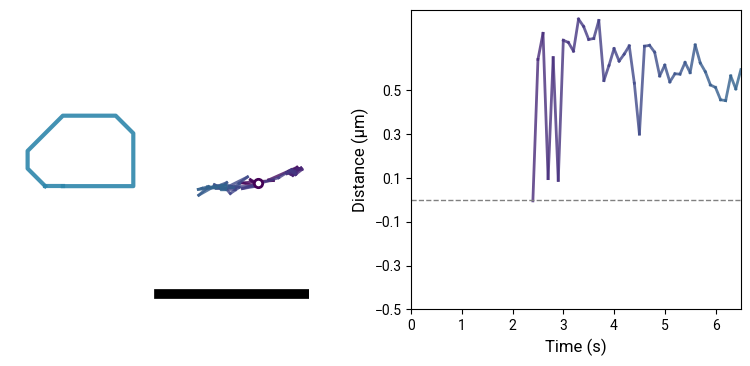

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-16_track_90.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-16, Track ID: 103
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-16
    ✅ 1/1 tracks interacting with 367 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 43, trace_df has 40
First dwell time: 0.4, until 3.4
First time point int track_data: 1


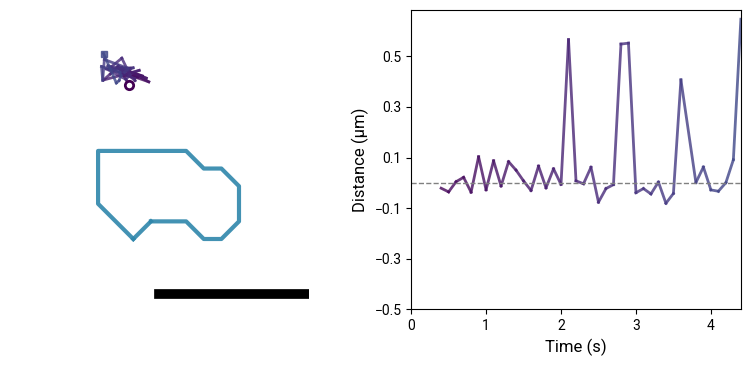

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-16_track_103.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-16, Track ID: 459
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-16
    ✅ 1/1 tracks interacting with 384 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


First dwell time: 0.0, until 3.0
First time point int track_data: 0


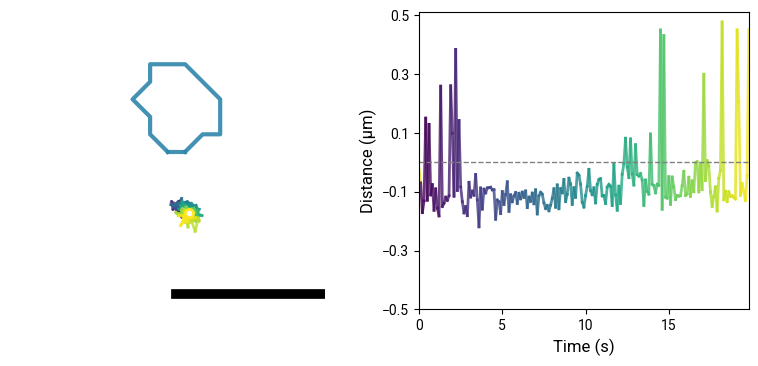

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-16_track_459.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-16, Track ID: 487
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-16
    ✅ 1/1 tracks interacting with 375 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 88, trace_df has 45
First dwell time: 4.3, until 7.3
First time point int track_data: 0


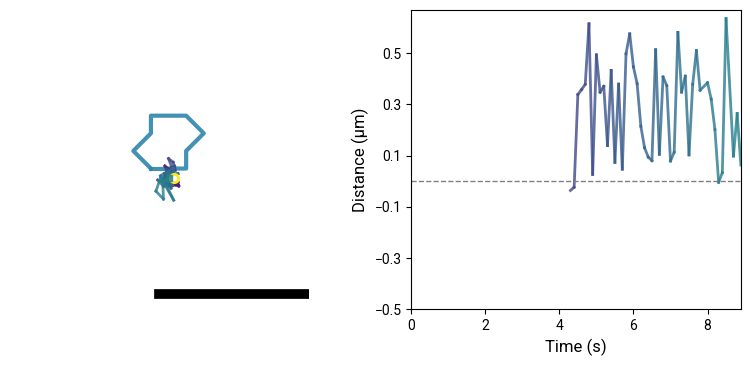

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-16_track_487.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-16, Track ID: 713
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-16
    ✅ 1/1 tracks interacting with 371 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 56, trace_df has 21
First dwell time: 3.5, until 6.5
First time point int track_data: 0


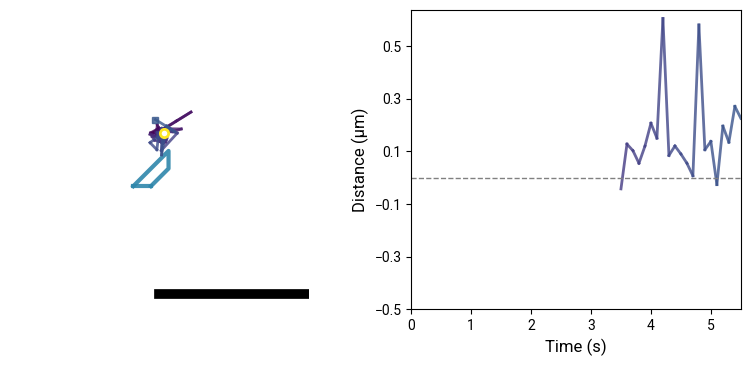

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-16_track_713.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-16, Track ID: 2238
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-16
    ✅ 1/1 tracks interacting with 370 condensates
Length of exp_results: 2
⚠️ Mismatch in number of points: track_data has 29, trace_df has 11


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


First dwell time: 5.4, until 8.4
First time point int track_data: 35


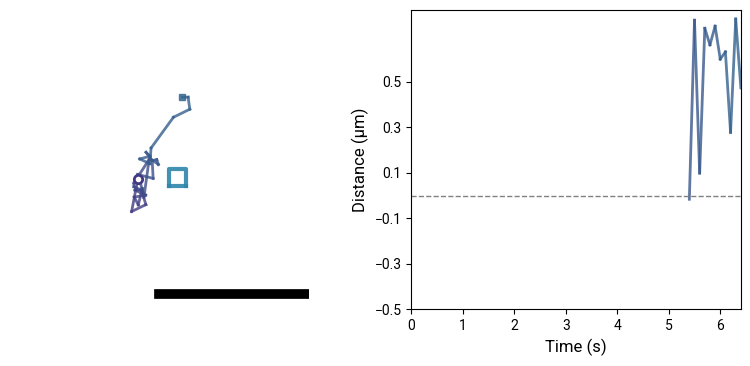

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-16_track_2238.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-16, Track ID: 2574
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-16
    ✅ 1/1 tracks interacting with 368 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


First dwell time: 4.3, until 7.3
First time point int track_data: 43


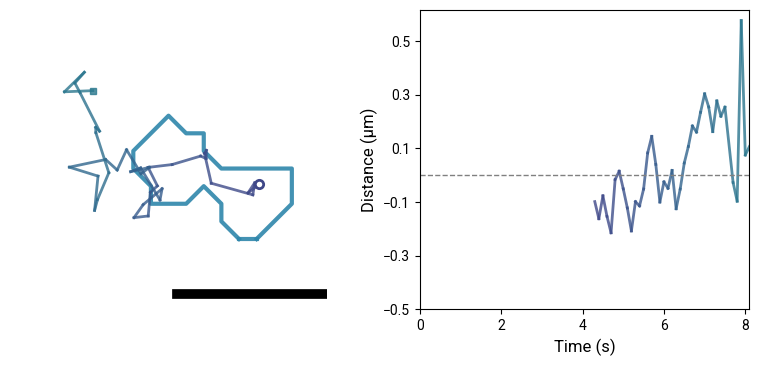

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-16_track_2574.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-16, Track ID: 2675
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-16
    ✅ 1/1 tracks interacting with 367 condensates
Length of exp_results: 2
⚠️ Mismatch in number of points: track_data has 16, trace_df has 7
First dwell time: 5.1000000000000005, until 8.100000000000001
First time point int track_data: 41


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


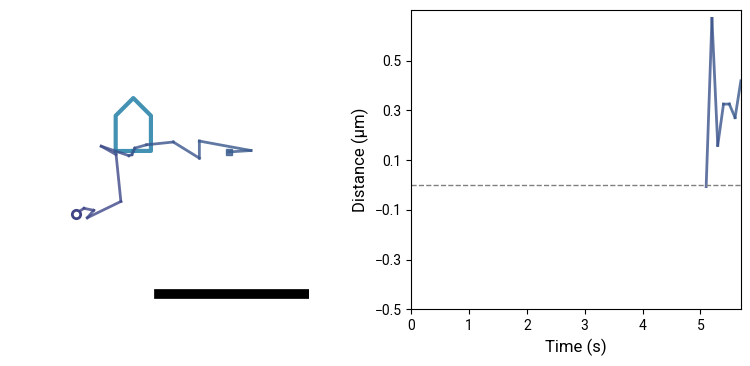

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-16_track_2675.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-16, Track ID: 2953
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-16
    ✅ 1/1 tracks interacting with 358 condensates
Length of exp_results: 2
⚠️ Mismatch in number of points: track_data has 26, trace_df has 25
First dwell time: 5.9, until 8.9
First time point int track_data: 58


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


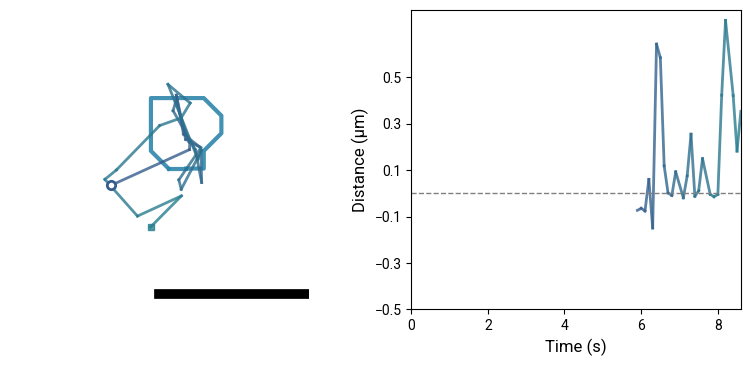

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-16_track_2953.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-16, Track ID: 3237
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-16
    ✅ 1/1 tracks interacting with 371 condensates
Length of exp_results: 2
First dwell time: 6.0, until 9.0
First time point int track_data: 60


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


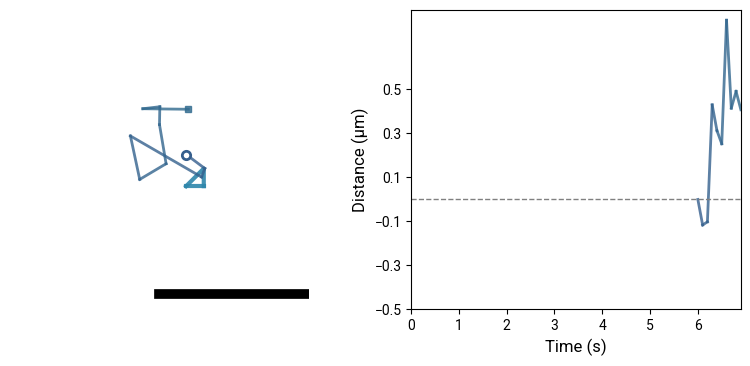

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-16_track_3237.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-16, Track ID: 3504
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-16
    ✅ 1/1 tracks interacting with 380 condensates
Length of exp_results: 2
⚠️ Mismatch in number of points: track_data has 9, trace_df has 6
First dwell time: 6.5, until 9.5
First time point int track_data: 62


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


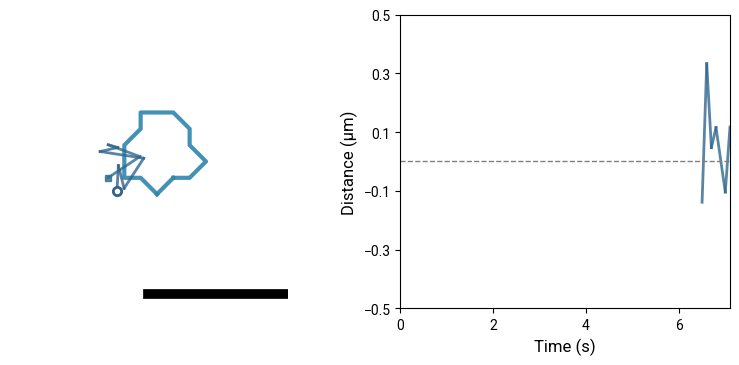

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-16_track_3504.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-16, Track ID: 4097
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-16
    ✅ 1/1 tracks interacting with 377 condensates
Length of exp_results: 2
⚠️ Mismatch in number of points: track_data has 37, trace_df has 36
First dwell time: 7.6, until 10.6
First time point int track_data: 75


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


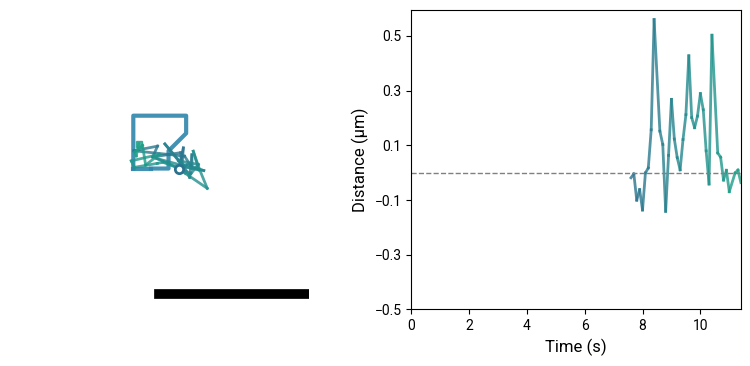

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-16_track_4097.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-16, Track ID: 4185
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-16
    ✅ 1/1 tracks interacting with 368 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 31, trace_df has 21
First dwell time: 7.800000000000001, until 10.8
First time point int track_data: 68


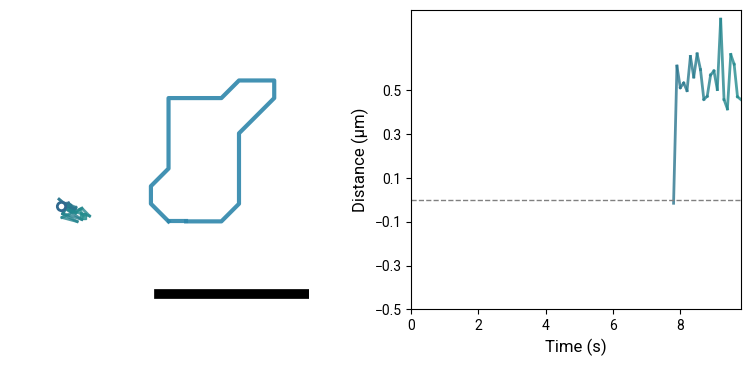

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-16_track_4185.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-16, Track ID: 4866
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-16
    ✅ 1/1 tracks interacting with 373 condensates
Length of exp_results: 2
First dwell time: 9.0, until 12.0
First time point int track_data: 90


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


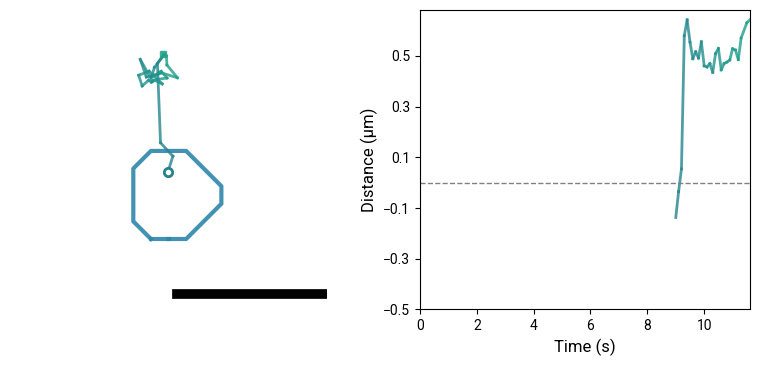

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-16_track_4866.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-16, Track ID: 5646
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-16
    ✅ 1/1 tracks interacting with 378 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 67, trace_df has 57
First dwell time: 11.6, until 14.6
First time point int track_data: 104


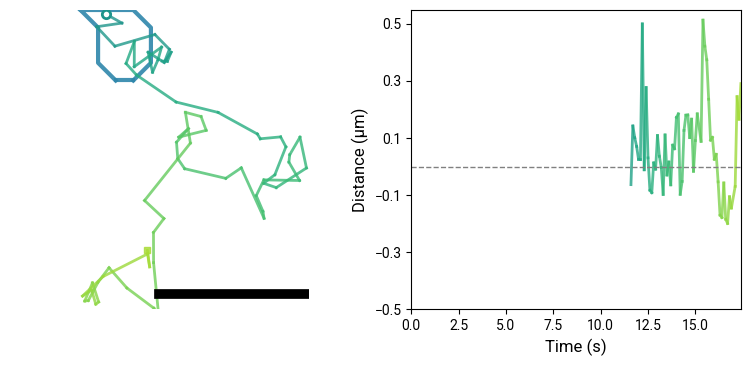

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-16_track_5646.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-16, Track ID: 5658
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-16
    ✅ 1/1 tracks interacting with 378 condensates
Length of exp_results: 2
⚠️ Mismatch in number of points: track_data has 20, trace_df has 14
First dwell time: 11.8, until 14.8
First time point int track_data: 112


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


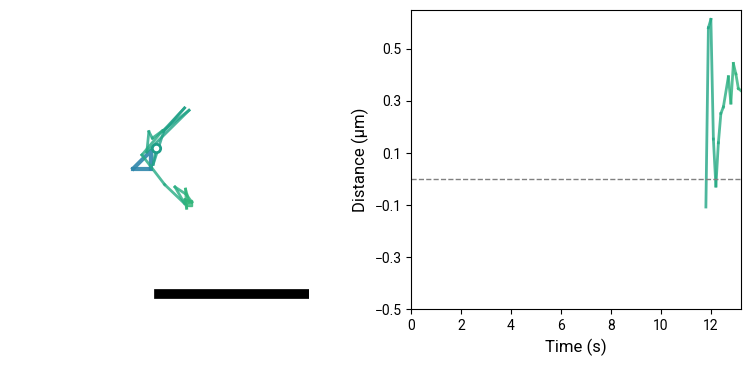

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-16_track_5658.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-16, Track ID: 5700
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-16
    ✅ 1/1 tracks interacting with 364 condensates
Length of exp_results: 2
⚠️ Mismatch in number of points: track_data has 13, trace_df has 6
First dwell time: 11.5, until 14.5
First time point int track_data: 107


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


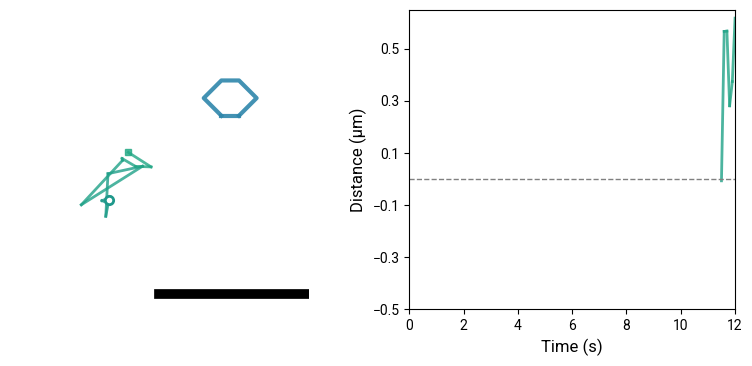

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-16_track_5700.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-16, Track ID: 7572
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-16
    ✅ 1/1 tracks interacting with 360 condensates
Length of exp_results: 2
⚠️ Mismatch in number of points: track_data has 14, trace_df has 13
First dwell time: 16.6, until 19.6
First time point int track_data: 165


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


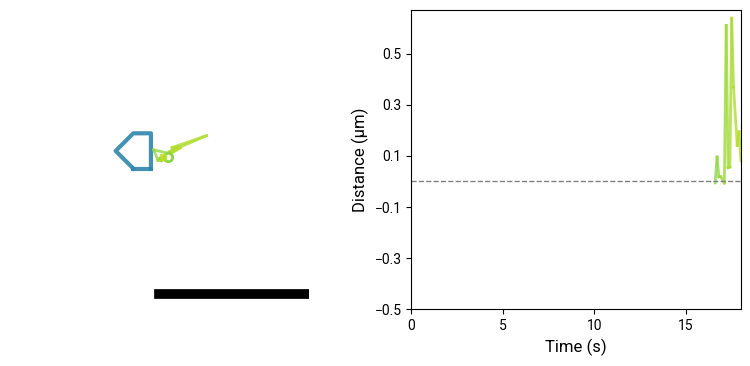

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-16_track_7572.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-16, Track ID: 7637
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-16
    ✅ 1/1 tracks interacting with 370 condensates
Length of exp_results: 2
⚠️ Mismatch in number of points: track_data has 9, trace_df has 3
First dwell time: 18.6, until 21.6
First time point int track_data: 179


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


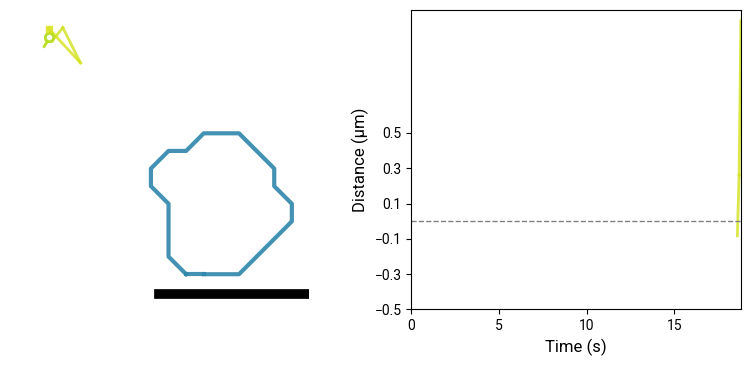

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-16_track_7637.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-16, Track ID: 8246
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-16
    ✅ 1/1 tracks interacting with 376 condensates
Length of exp_results: 2
First dwell time: 19.200000000000003, until 22.200000000000003
First time point int track_data: 192


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


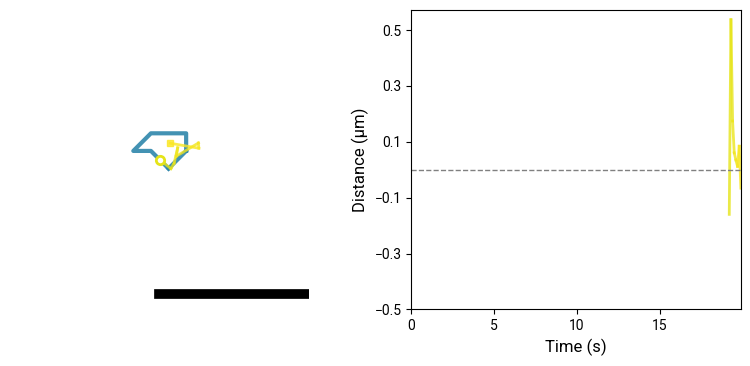

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-16_track_8246.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-6, Track ID: 342
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-6
    ✅ 1/1 tracks interacting with 619 condensates
Length of exp_results: 2
⚠️ Mismatch in number of points: track_data has 13, trace_df has 8
First dwell time: 0.5, until 3.5
First time point int track_data: 0


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


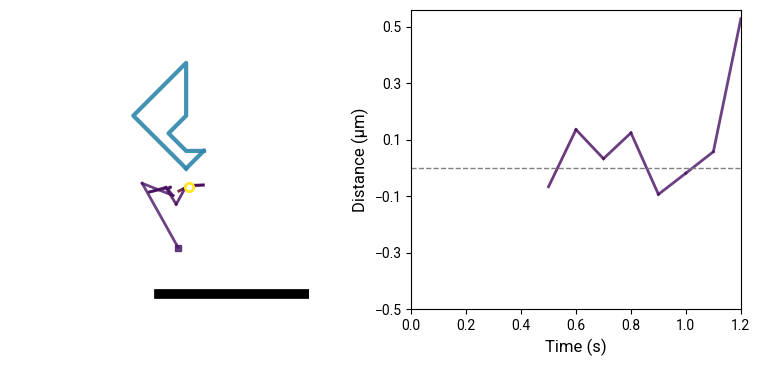

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-6_track_342.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-6, Track ID: 400
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-6
    ✅ 1/1 tracks interacting with 599 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 23, trace_df has 11
First dwell time: 1.2000000000000002, until 4.2
First time point int track_data: 0


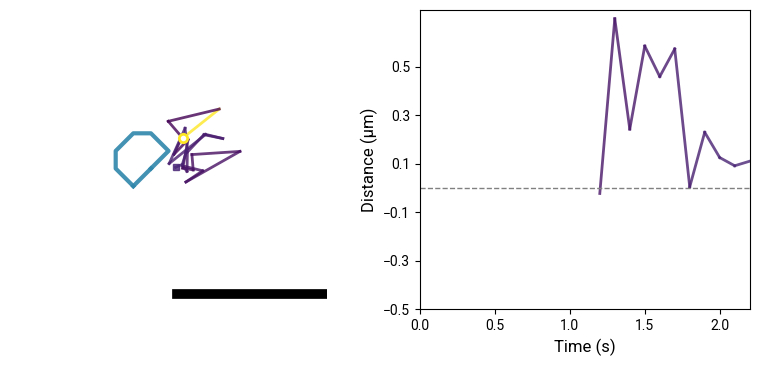

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-6_track_400.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-6, Track ID: 519
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-6
    ✅ 1/1 tracks interacting with 584 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 200, trace_df has 7
First dwell time: 19.3, until 22.3
First time point int track_data: 0


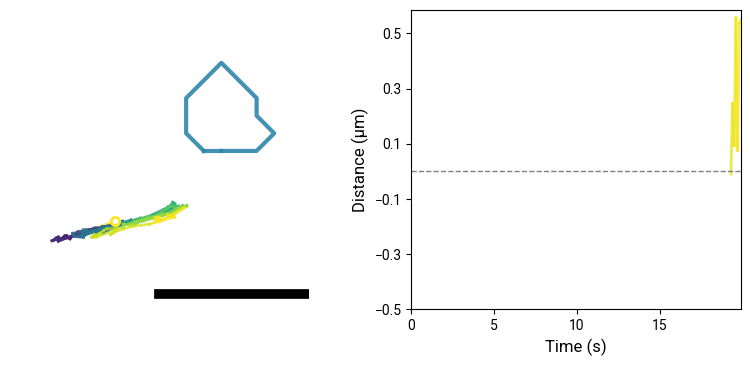

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-6_track_519.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-6, Track ID: 553
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-6
    ✅ 1/1 tracks interacting with 584 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 200, trace_df has 69
First dwell time: 13.1, until 16.1
First time point int track_data: 0


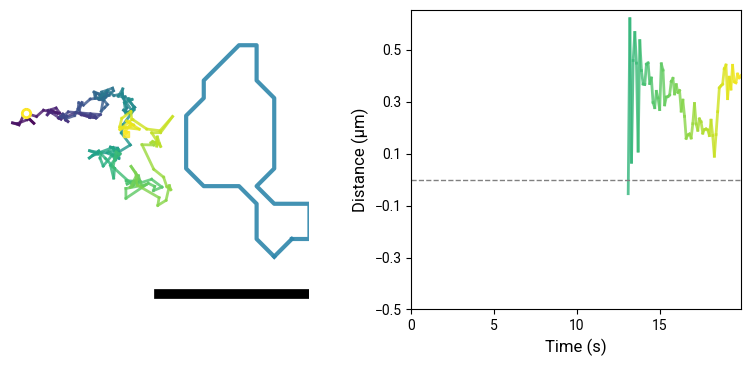

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-6_track_553.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-6, Track ID: 1050
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-6
    ✅ 1/1 tracks interacting with 607 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 61, trace_df has 59
First dwell time: 0.9, until 3.9
First time point int track_data: 7


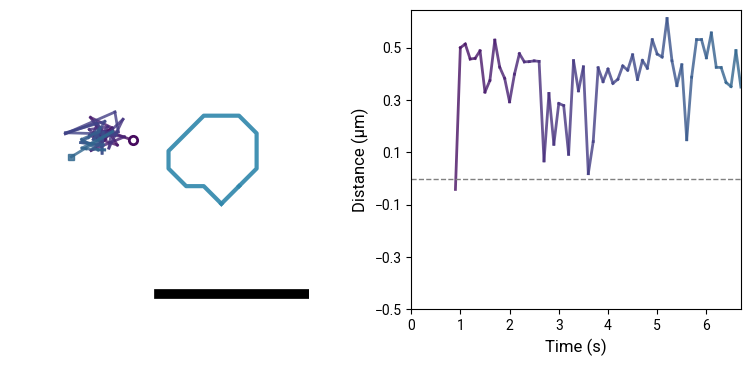

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-6_track_1050.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-6, Track ID: 1562
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-6
    ✅ 1/1 tracks interacting with 599 condensates
Length of exp_results: 2
⚠️ Mismatch in number of points: track_data has 12, trace_df has 3
First dwell time: 2.9000000000000004, until 5.9
First time point int track_data: 20


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


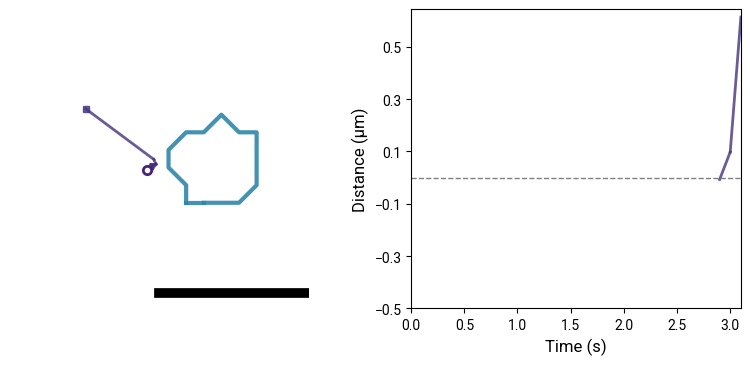

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-6_track_1562.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-6, Track ID: 1739
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-6
    ✅ 1/1 tracks interacting with 591 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 23, trace_df has 20
First dwell time: 2.9000000000000004, until 5.9
First time point int track_data: 26


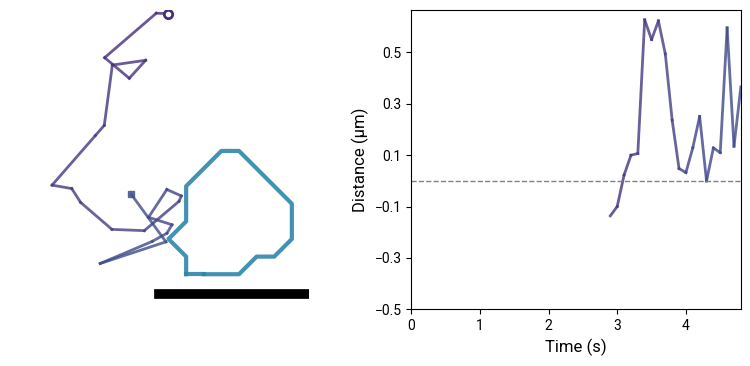

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-6_track_1739.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-6, Track ID: 2002
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-6
    ✅ 1/1 tracks interacting with 596 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


First dwell time: 4.5, until 7.5
First time point int track_data: 45


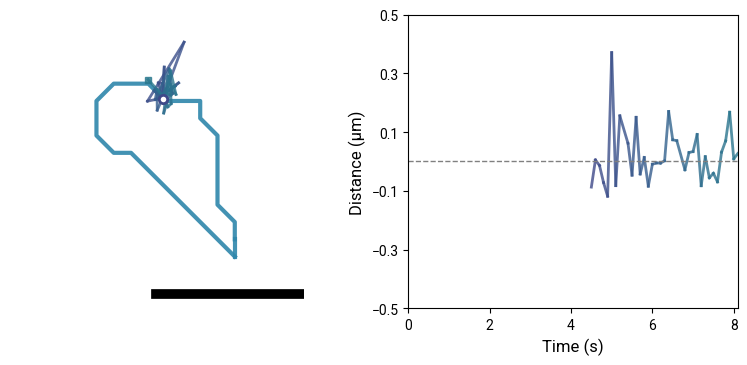

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-6_track_2002.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-6, Track ID: 2043
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-6
    ✅ 1/1 tracks interacting with 589 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 61, trace_df has 22
First dwell time: 8.0, until 11.0
First time point int track_data: 41


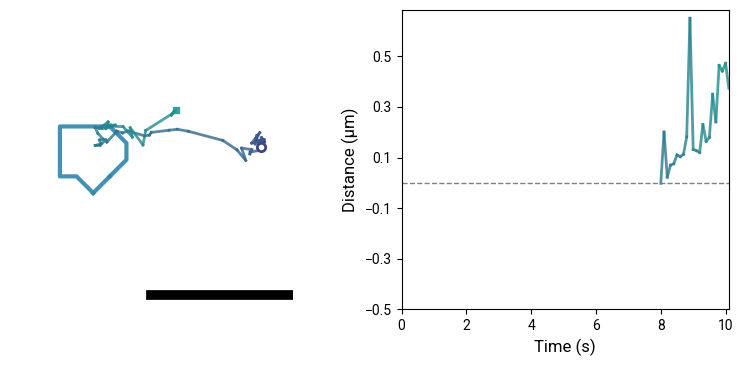

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-6_track_2043.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-6, Track ID: 2105
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-6
    ✅ 1/1 tracks interacting with 609 condensates
Length of exp_results: 2
⚠️ Mismatch in number of points: track_data has 10, trace_df has 2
First dwell time: 5.4, until 8.4
First time point int track_data: 44


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


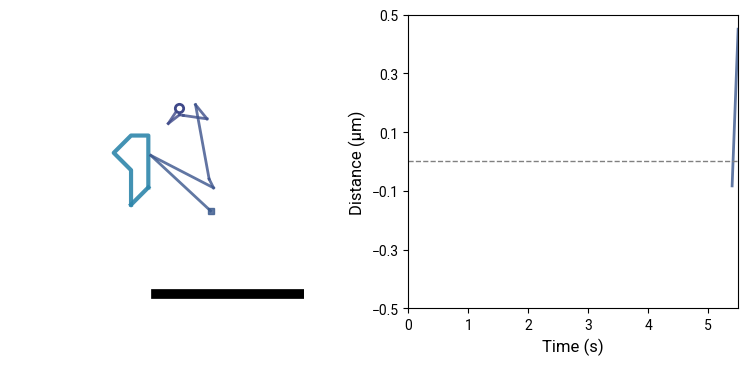

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-6_track_2105.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-6, Track ID: 2125
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-6
    ✅ 1/1 tracks interacting with 601 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 22, trace_df has 3
First dwell time: 6.4, until 9.4
First time point int track_data: 44


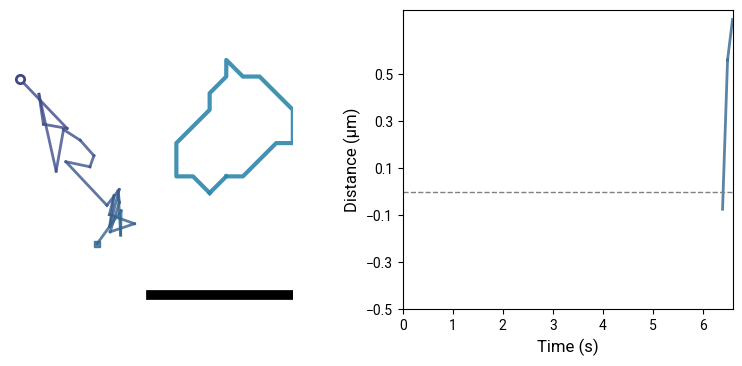

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-6_track_2125.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-6, Track ID: 2293
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-6
    ✅ 1/1 tracks interacting with 607 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 24, trace_df has 11
First dwell time: 6.4, until 9.4
First time point int track_data: 46


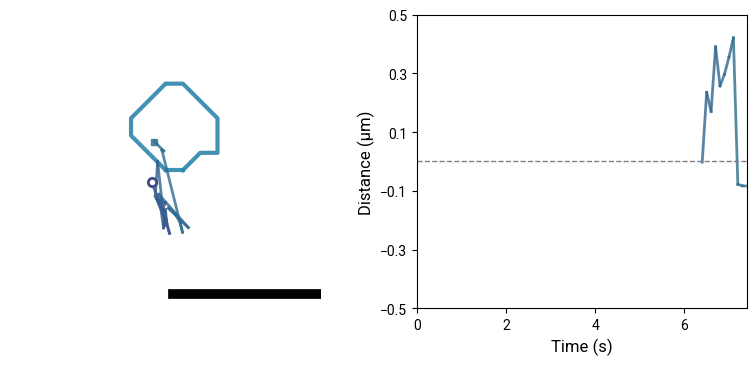

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-6_track_2293.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-6, Track ID: 2978
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-6
    ✅ 1/1 tracks interacting with 595 condensates
Length of exp_results: 2
⚠️ Mismatch in number of points: track_data has 8, trace_df has 6
First dwell time: 6.7, until 9.7
First time point int track_data: 65


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


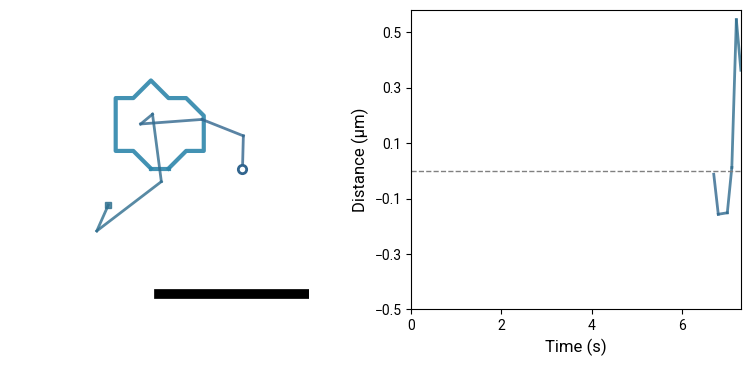

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-6_track_2978.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-6, Track ID: 3076
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-6
    ✅ 1/1 tracks interacting with 595 condensates
Length of exp_results: 2
⚠️ Mismatch in number of points: track_data has 9, trace_df has 4
First dwell time: 7.6, until 10.6
First time point int track_data: 70


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


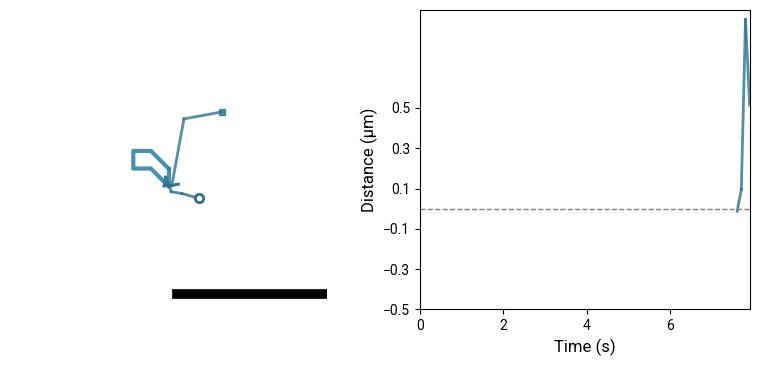

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-6_track_3076.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-6, Track ID: 3160
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-6
    ✅ 1/1 tracks interacting with 596 condensates
Length of exp_results: 2
First dwell time: 7.300000000000001, until 10.3
First time point int track_data: 73


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


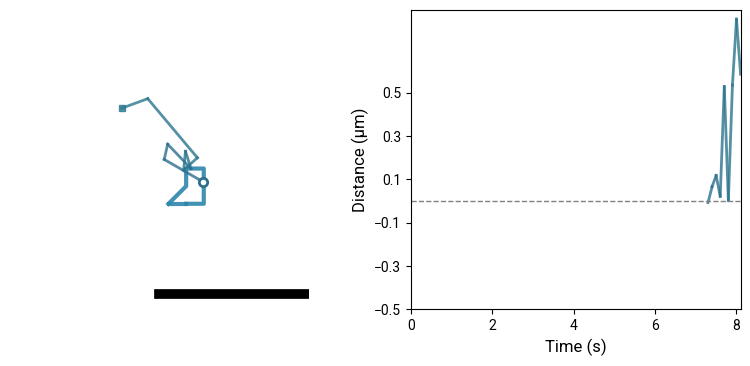

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-6_track_3160.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-6, Track ID: 3354
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-6
    ✅ 1/1 tracks interacting with 600 condensates
Length of exp_results: 2
⚠️ Mismatch in number of points: track_data has 11, trace_df has 9
First dwell time: 8.0, until 11.0
First time point int track_data: 78


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


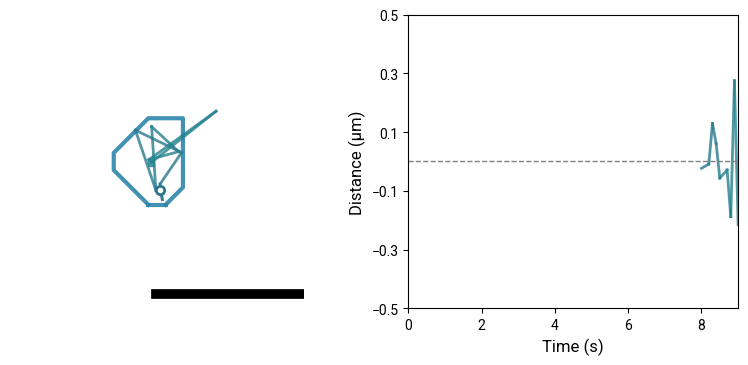

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-6_track_3354.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-6, Track ID: 3778
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-6
    ✅ 1/1 tracks interacting with 575 condensates
Length of exp_results: 2
⚠️ Mismatch in number of points: track_data has 10, trace_df has 8
First dwell time: 9.6, until 12.6
First time point int track_data: 94


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


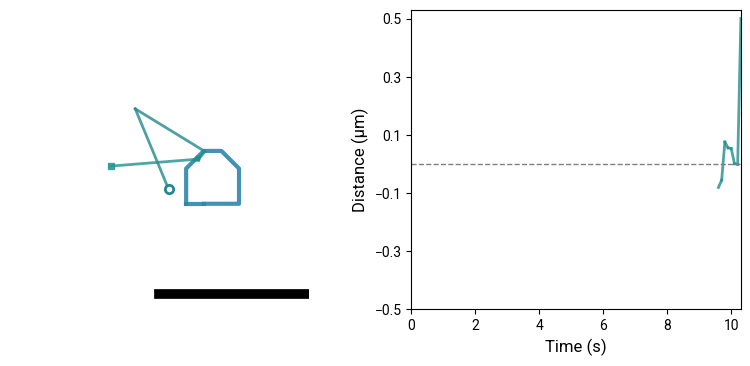

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-6_track_3778.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-6, Track ID: 4340
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-6
    ✅ 1/1 tracks interacting with 595 condensates
Length of exp_results: 2
⚠️ Mismatch in number of points: track_data has 9, trace_df has 8
First dwell time: 11.5, until 14.5
First time point int track_data: 114


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


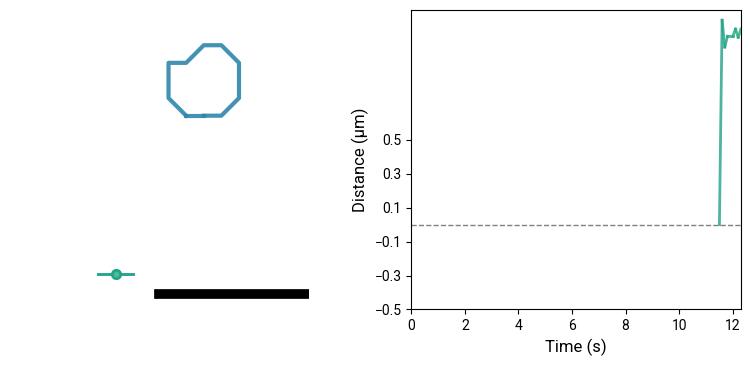

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-6_track_4340.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-6, Track ID: 4732
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-6
    ✅ 1/1 tracks interacting with 607 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 25, trace_df has 8
First dwell time: 15.0, until 18.0
First time point int track_data: 133


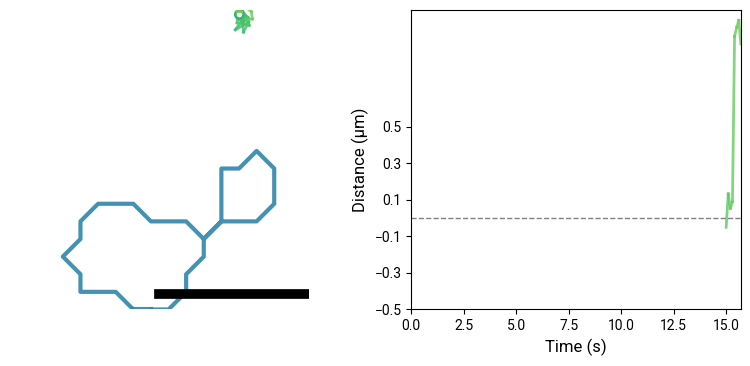

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-6_track_4732.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-6, Track ID: 4783
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-6
    ✅ 1/1 tracks interacting with 601 condensates
Length of exp_results: 2
First dwell time: 13.9, until 16.9
First time point int track_data: 139


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


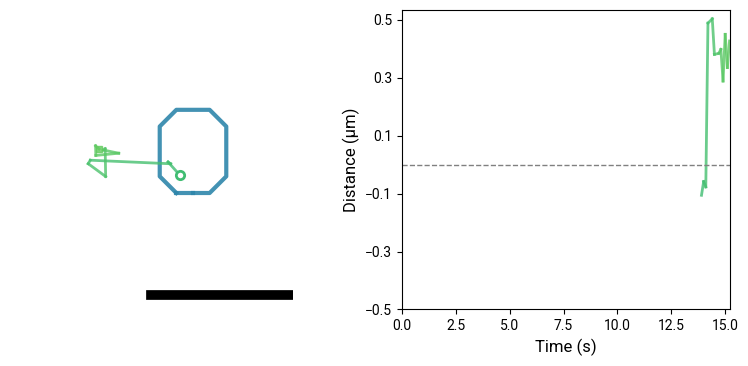

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-6_track_4783.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-6, Track ID: 5164
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-6
    ✅ 1/1 tracks interacting with 597 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


First dwell time: 14.8, until 17.8
First time point int track_data: 148


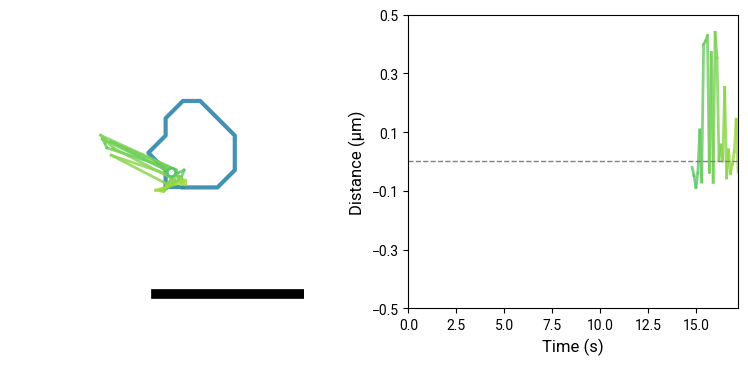

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-6_track_5164.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-14, Track ID: 51
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-14
    ✅ 1/1 tracks interacting with 411 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 119, trace_df has 118
First dwell time: 0.1, until 3.1
First time point int track_data: 0


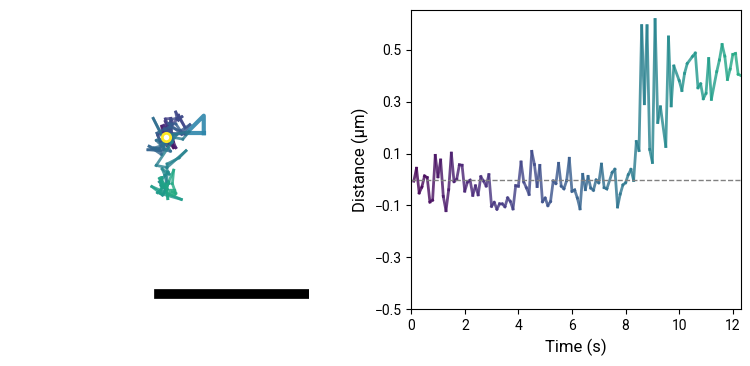

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-14_track_51.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-14, Track ID: 307
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-14
    ✅ 1/1 tracks interacting with 407 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


First dwell time: 0.0, until 3.0
First time point int track_data: 0


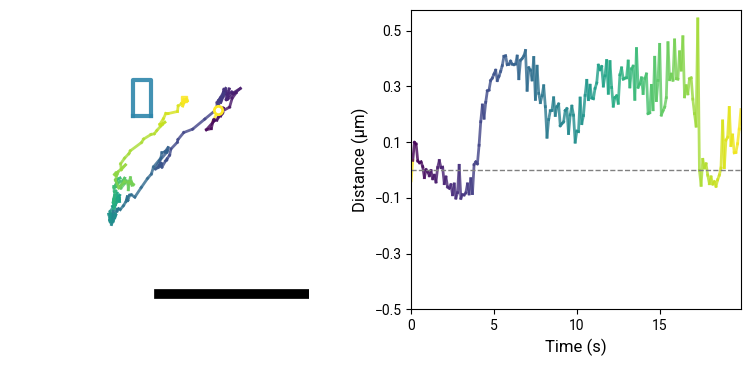

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-14_track_307.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-14, Track ID: 387
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-14
    ✅ 1/1 tracks interacting with 413 condensates
Length of exp_results: 2
First dwell time: 0.0, until 3.0
First time point int track_data: 0


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


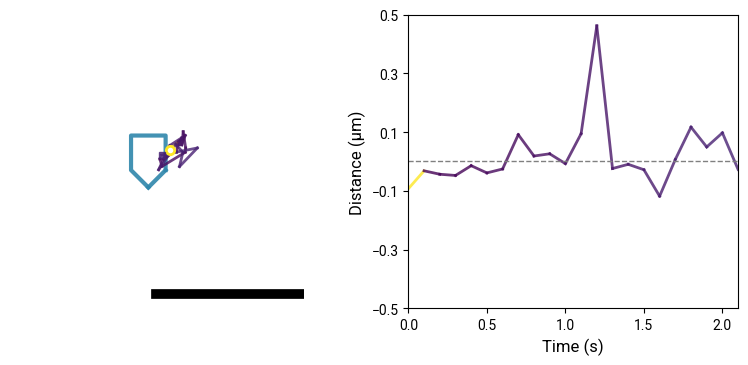

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-14_track_387.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-14, Track ID: 635
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-14
    ✅ 1/1 tracks interacting with 414 condensates
Length of exp_results: 2
⚠️ Mismatch in number of points: track_data has 17, trace_df has 7
First dwell time: 1.8, until 4.8
First time point int track_data: 6


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


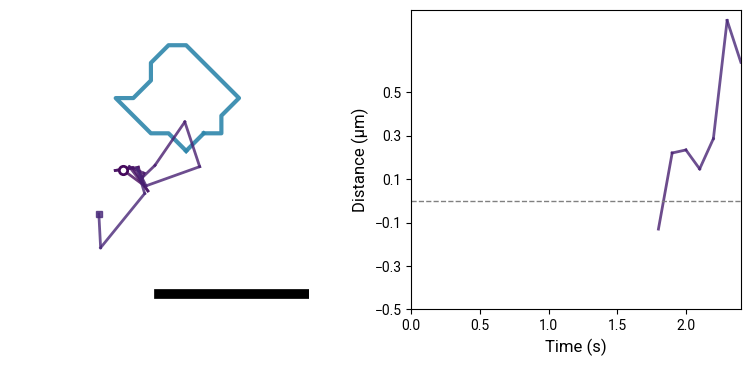

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-14_track_635.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-14, Track ID: 1208
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-14
    ✅ 1/1 tracks interacting with 409 condensates
Length of exp_results: 2
First dwell time: 2.6, until 5.6
First time point int track_data: 26


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


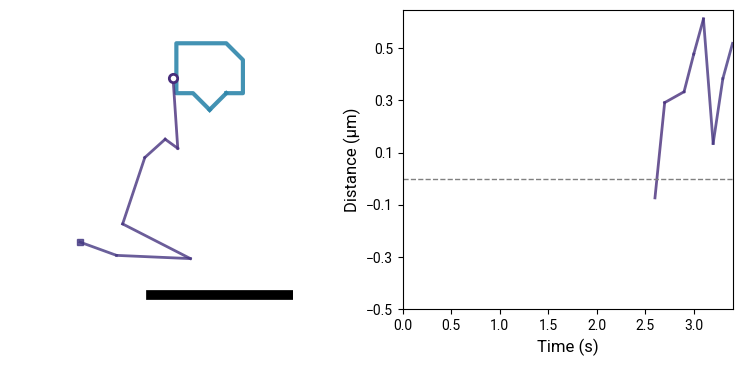

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-14_track_1208.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-14, Track ID: 1444
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-14
    ✅ 1/1 tracks interacting with 408 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


First dwell time: 3.1, until 6.1
First time point int track_data: 31


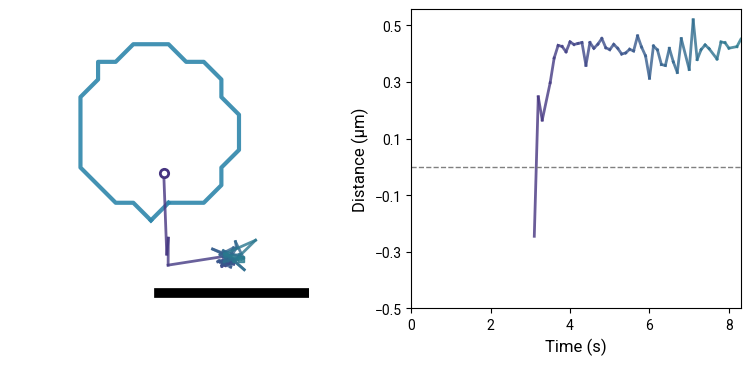

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-14_track_1444.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-14, Track ID: 1839
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-14
    ✅ 1/1 tracks interacting with 411 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 34, trace_df has 25
First dwell time: 5.300000000000001, until 8.3
First time point int track_data: 43


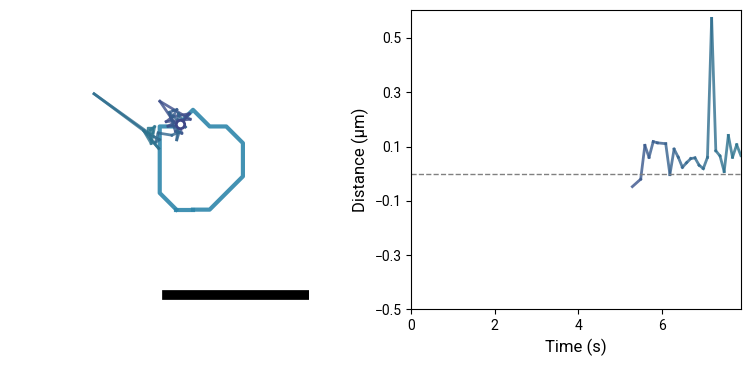

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-14_track_1839.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-14, Track ID: 3066
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-14
    ✅ 1/1 tracks interacting with 415 condensates
Length of exp_results: 2
⚠️ Mismatch in number of points: track_data has 16, trace_df has 15
First dwell time: 8.200000000000001, until 11.200000000000001
First time point int track_data: 81


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


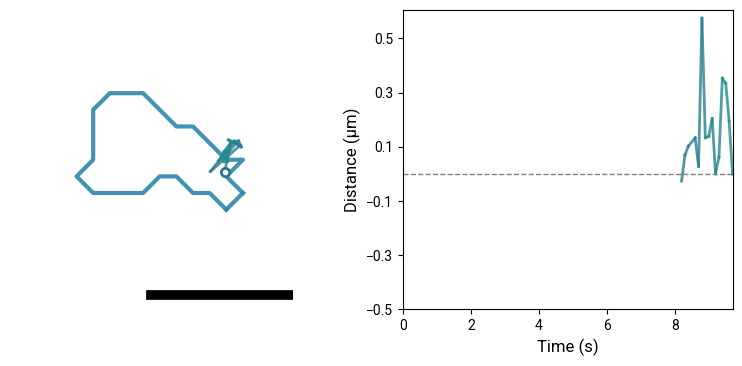

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-14_track_3066.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-14, Track ID: 3193
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-14
    ✅ 1/1 tracks interacting with 411 condensates
Length of exp_results: 2
⚠️ Mismatch in number of points: track_data has 28, trace_df has 27


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


First dwell time: 9.5, until 12.5
First time point int track_data: 94


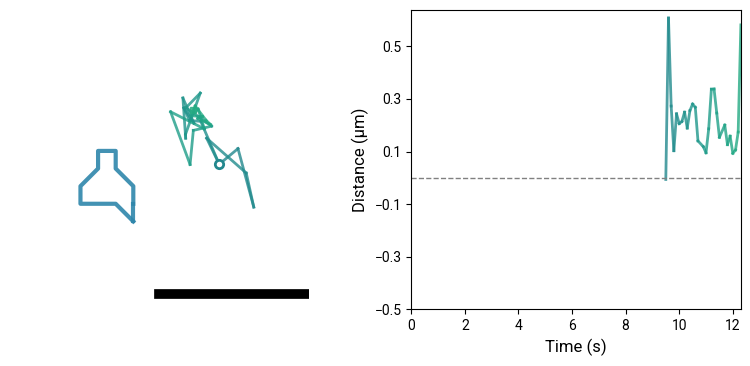

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-14_track_3193.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-14, Track ID: 3645
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-14
    ✅ 1/1 tracks interacting with 405 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 49, trace_df has 36
First dwell time: 12.2, until 15.2
First time point int track_data: 109


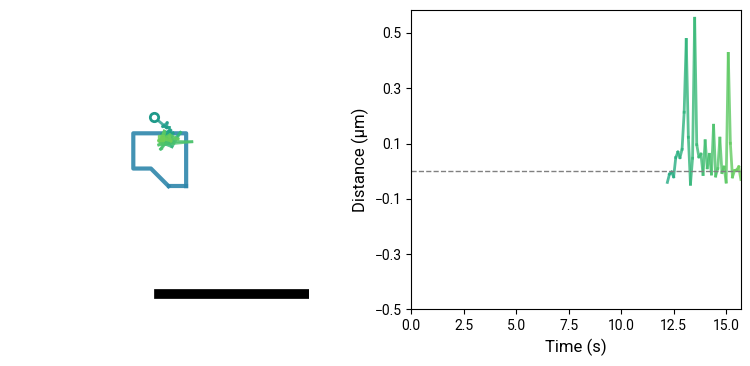

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-14_track_3645.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-14, Track ID: 4812
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-14
    ✅ 1/1 tracks interacting with 407 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 43, trace_df has 40
First dwell time: 16.0, until 19.0
First time point int track_data: 157


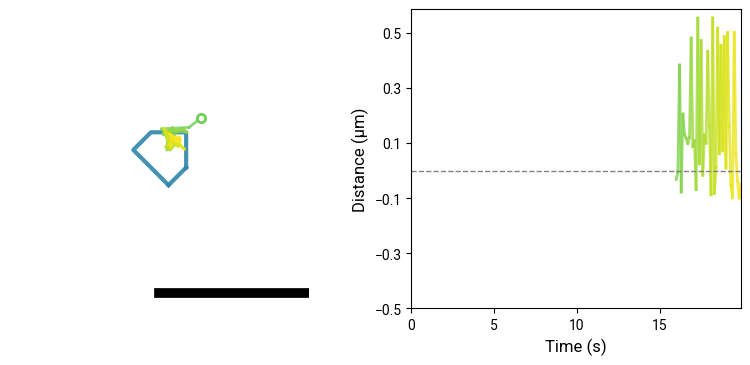

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-14_track_4812.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-8, Track ID: 52
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-8
    ✅ 1/1 tracks interacting with 672 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 175, trace_df has 101
First dwell time: 7.4, until 10.4
First time point int track_data: 0


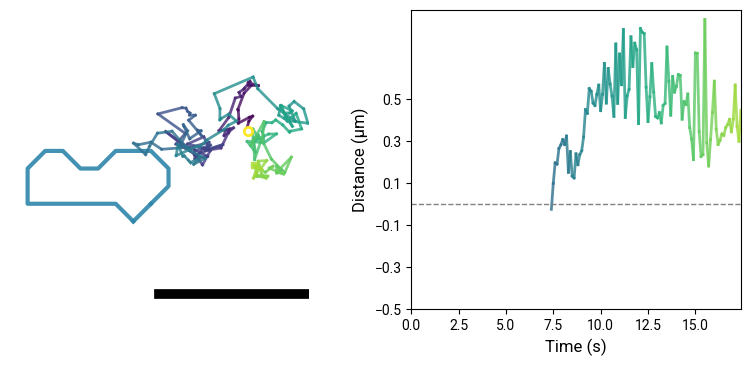

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-8_track_52.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-8, Track ID: 188
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-8
    ✅ 1/1 tracks interacting with 682 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


First dwell time: 0.0, until 3.0
First time point int track_data: 0


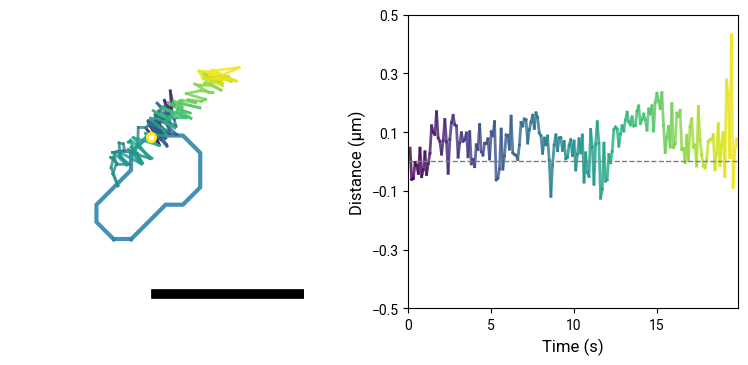

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-8_track_188.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-8, Track ID: 754
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-8
    ✅ 1/1 tracks interacting with 684 condensates
Length of exp_results: 2
⚠️ Mismatch in number of points: track_data has 9, trace_df has 8
First dwell time: 1.5, until 4.5
First time point int track_data: 14


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


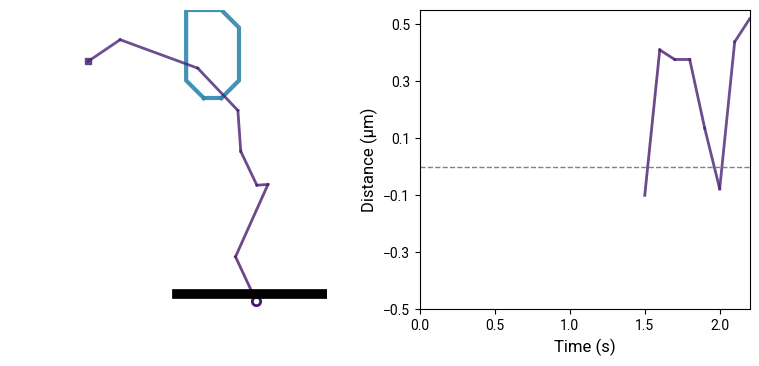

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-8_track_754.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-8, Track ID: 912
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-8
    ✅ 1/1 tracks interacting with 692 condensates
Length of exp_results: 2
⚠️ Mismatch in number of points: track_data has 8, trace_df has 6
First dwell time: 2.7, until 5.7
First time point int track_data: 25


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


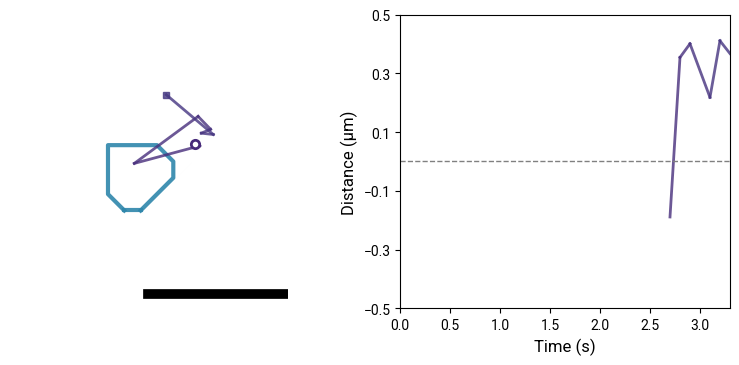

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-8_track_912.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-8, Track ID: 1630
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-8
    ✅ 1/1 tracks interacting with 679 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 64, trace_df has 55
First dwell time: 5.800000000000001, until 8.8
First time point int track_data: 49


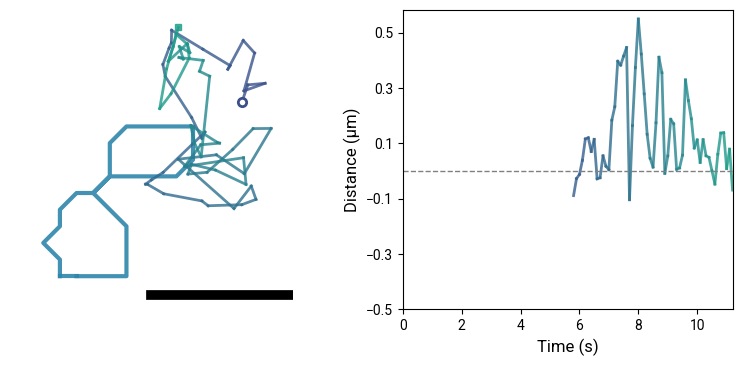

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-8_track_1630.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-8, Track ID: 1682
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-8
    ✅ 1/1 tracks interacting with 692 condensates
Length of exp_results: 2
⚠️ Mismatch in number of points: track_data has 11, trace_df has 6
First dwell time: 5.4, until 8.4
First time point int track_data: 49


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


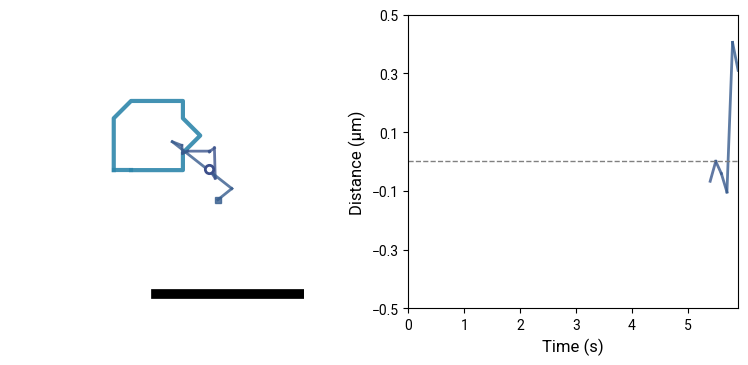

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-8_track_1682.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-8, Track ID: 1717
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-8
    ✅ 1/1 tracks interacting with 683 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


First dwell time: 4.4, until 7.4
First time point int track_data: 44


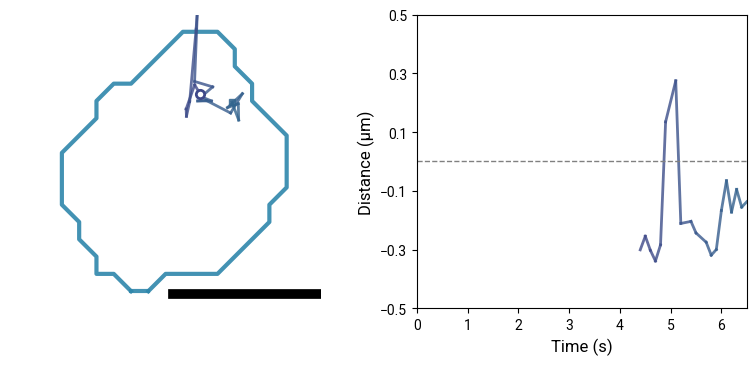

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-8_track_1717.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-12, Track ID: 77
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-12
    ✅ 1/1 tracks interacting with 721 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 182, trace_df has 179
First dwell time: 0.3, until 3.3
First time point int track_data: 0


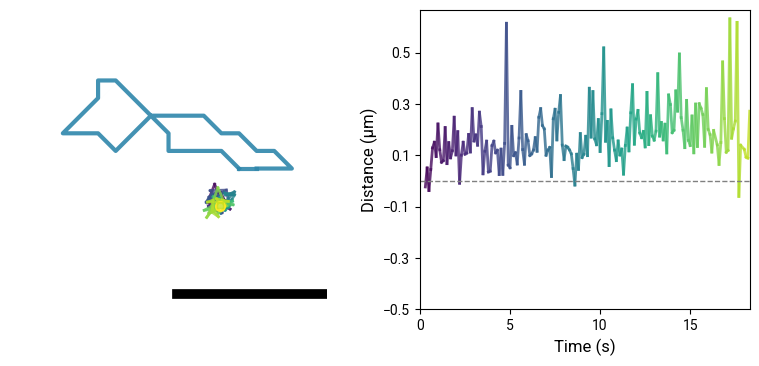

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-12_track_77.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-12, Track ID: 80
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-12
    ✅ 1/1 tracks interacting with 735 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


First dwell time: 0.0, until 3.0
First time point int track_data: 0


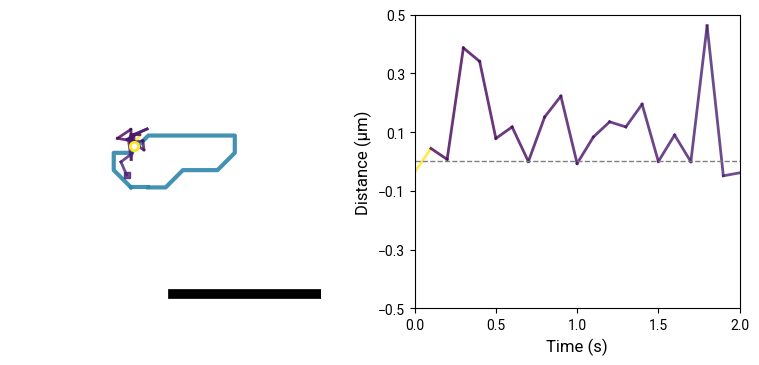

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-12_track_80.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-12, Track ID: 239
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-12
    ✅ 1/1 tracks interacting with 722 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 200, trace_df has 195
First dwell time: 0.5, until 3.5
First time point int track_data: 0


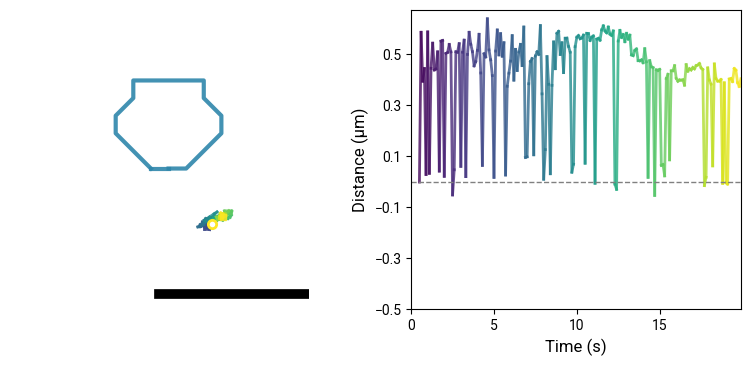

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-12_track_239.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-12, Track ID: 309
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-12
    ✅ 1/1 tracks interacting with 722 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 200, trace_df has 199
First dwell time: 0.1, until 3.1
First time point int track_data: 0


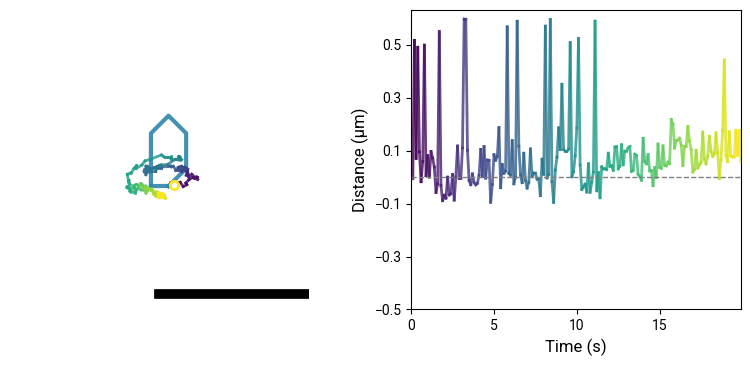

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-12_track_309.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-12, Track ID: 600
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-12
    ✅ 1/1 tracks interacting with 718 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 36, trace_df has 35
First dwell time: 0.1, until 3.1
First time point int track_data: 0


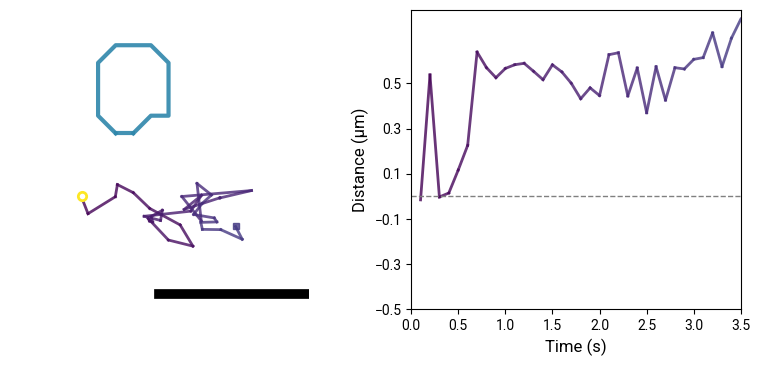

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-12_track_600.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-12, Track ID: 779
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-12
    ✅ 1/1 tracks interacting with 722 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


First dwell time: 0.0, until 3.0
First time point int track_data: 0


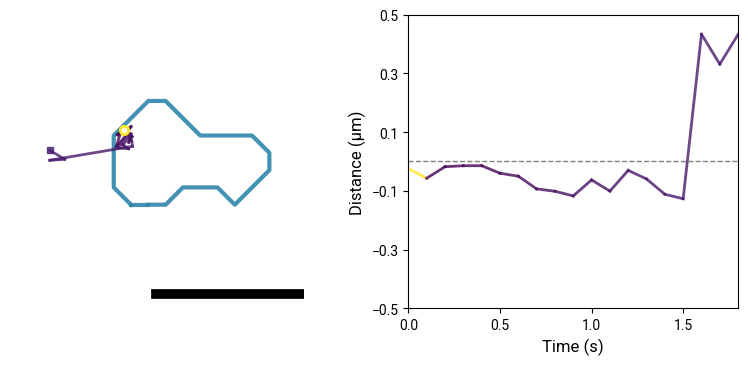

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-12_track_779.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-12, Track ID: 2530
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-12
    ✅ 1/1 tracks interacting with 732 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 20, trace_df has 3
First dwell time: 6.5, until 9.5
First time point int track_data: 47


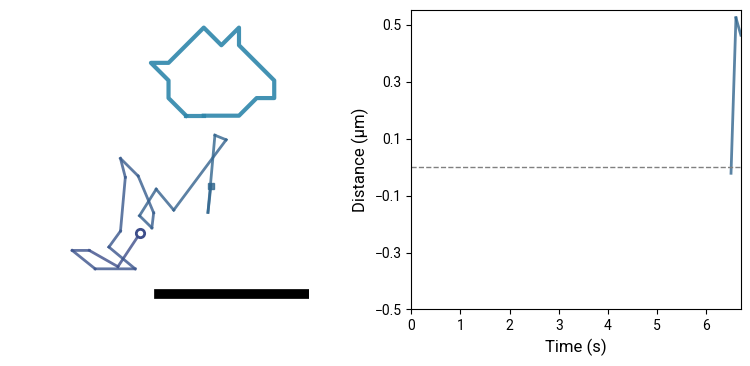

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-12_track_2530.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-12, Track ID: 3061
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-12
    ✅ 1/1 tracks interacting with 723 condensates
Length of exp_results: 2
⚠️ Mismatch in number of points: track_data has 13, trace_df has 8
First dwell time: 7.4, until 10.4
First time point int track_data: 69


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


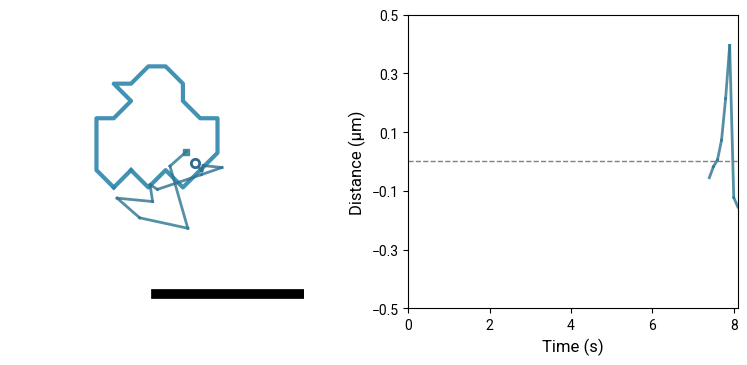

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-12_track_3061.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-20, Track ID: 7
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-20
    ✅ 1/1 tracks interacting with 208 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 200, trace_df has 199
First dwell time: 0.1, until 3.1
First time point int track_data: 0


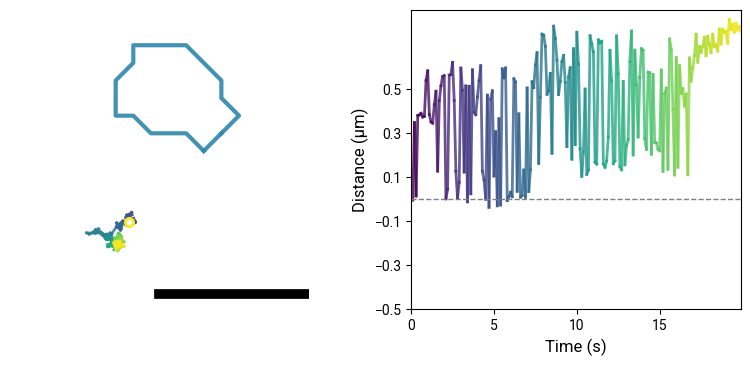

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-20_track_7.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-20, Track ID: 988
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-20
    ✅ 1/1 tracks interacting with 200 condensates
Length of exp_results: 2
⚠️ Mismatch in number of points: track_data has 11, trace_df has 2
First dwell time: 2.3000000000000003, until 5.300000000000001
First time point int track_data: 13


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


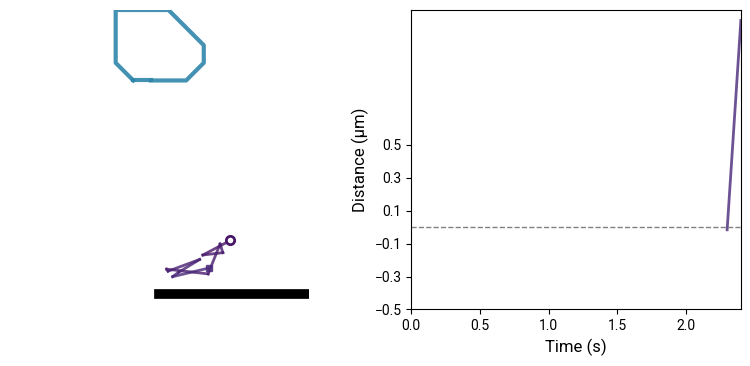

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-20_track_988.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-20, Track ID: 1729
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-20
    ✅ 1/1 tracks interacting with 201 condensates
Length of exp_results: 2
⚠️ Mismatch in number of points: track_data has 19, trace_df has 3
First dwell time: 5.300000000000001, until 8.3
First time point int track_data: 37


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


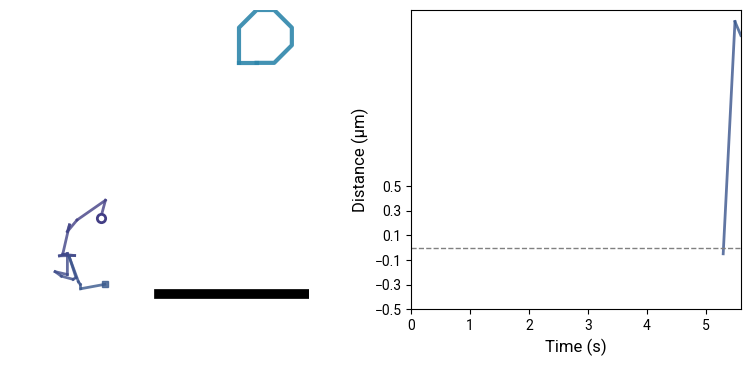

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-20_track_1729.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-20, Track ID: 4107
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-20
    ✅ 1/1 tracks interacting with 204 condensates
Length of exp_results: 2
⚠️ Mismatch in number of points: track_data has 27, trace_df has 24
First dwell time: 13.7, until 16.7
First time point int track_data: 134


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


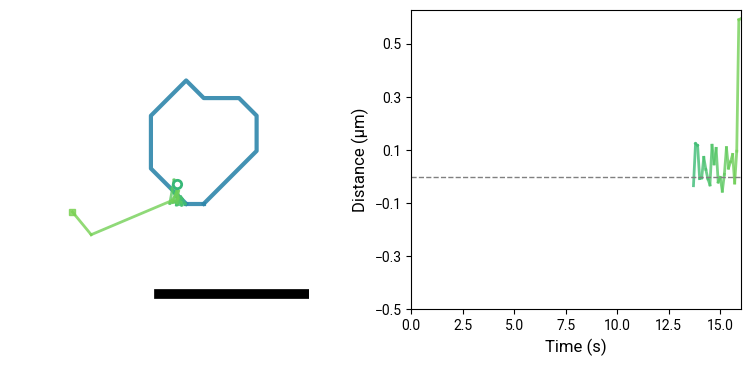

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-20_track_4107.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-10, Track ID: 124
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-10
    ✅ 1/1 tracks interacting with 421 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 22, trace_df has 13
First dwell time: 1.0, until 4.0
First time point int track_data: 0


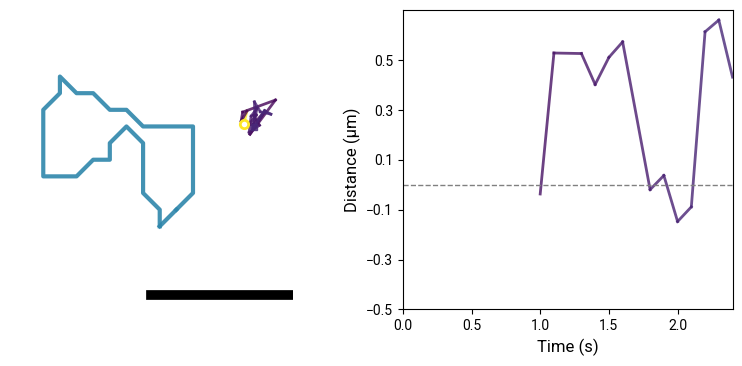

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-10_track_124.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-10, Track ID: 856
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-10
    ✅ 1/1 tracks interacting with 426 condensates
Length of exp_results: 2
⚠️ Mismatch in number of points: track_data has 15, trace_df has 14
First dwell time: 2.5, until 5.5
First time point int track_data: 24


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


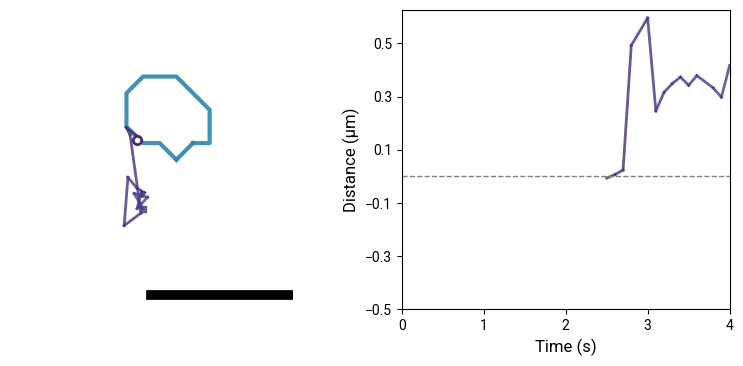

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-10_track_856.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-10, Track ID: 1084
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-10
    ✅ 1/1 tracks interacting with 413 condensates
Length of exp_results: 2
First dwell time: 3.0, until 6.0
First time point int track_data: 30


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


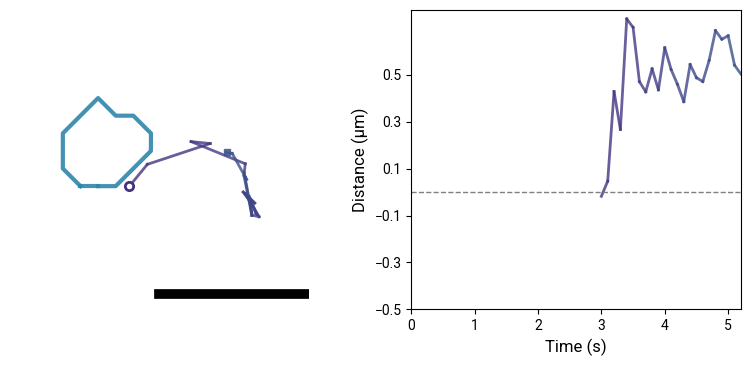

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-10_track_1084.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-10, Track ID: 2019
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-10
    ✅ 1/1 tracks interacting with 425 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 41, trace_df has 5
First dwell time: 11.6, until 14.6
First time point int track_data: 80


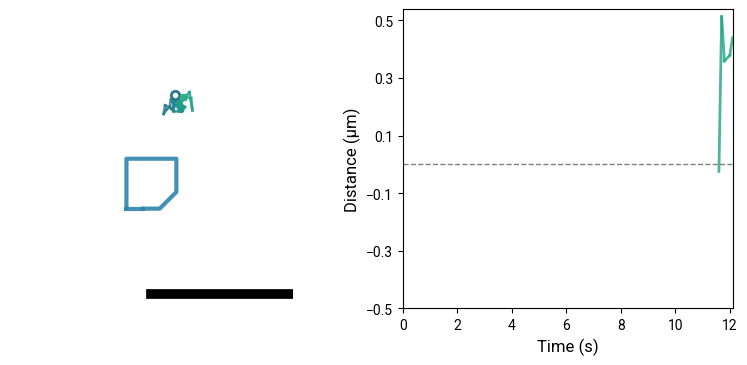

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-10_track_2019.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-18, Track ID: 237
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-18
    ✅ 1/1 tracks interacting with 220 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 200, trace_df has 177
First dwell time: 2.3000000000000003, until 5.300000000000001
First time point int track_data: 0


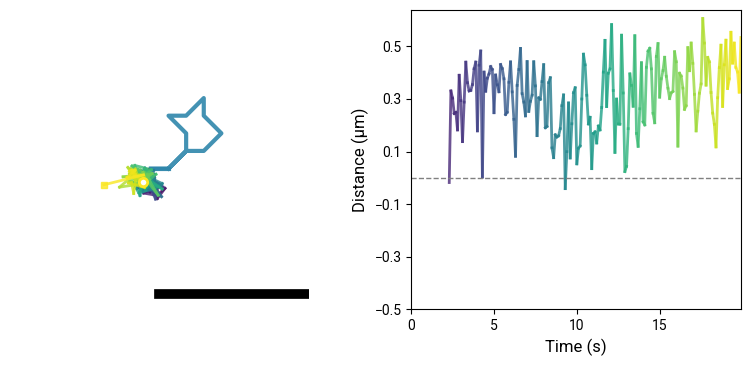

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-18_track_237.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-18, Track ID: 876
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-18
    ✅ 1/1 tracks interacting with 220 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 51, trace_df has 44
First dwell time: 2.8000000000000003, until 5.800000000000001
First time point int track_data: 21


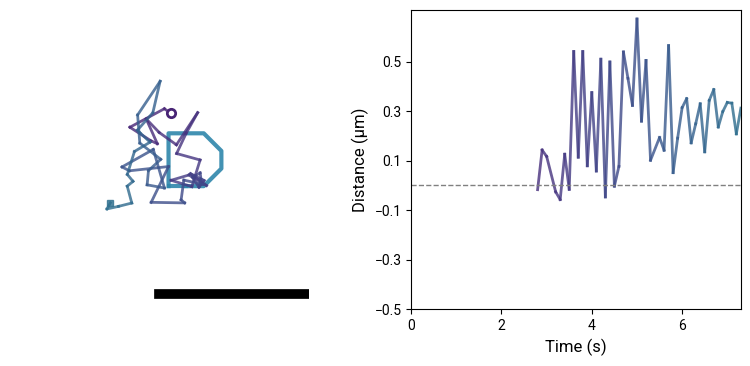

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-18_track_876.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-18, Track ID: 1199
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-18
    ✅ 1/1 tracks interacting with 224 condensates
Length of exp_results: 2
First dwell time: 3.4000000000000004, until 6.4
First time point int track_data: 34


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


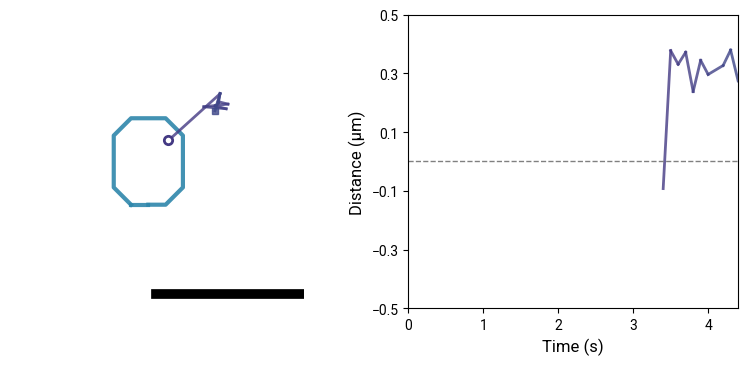

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-18_track_1199.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-18, Track ID: 2132
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-18
    ✅ 1/1 tracks interacting with 218 condensates
Length of exp_results: 2
⚠️ Mismatch in number of points: track_data has 22, trace_df has 10
First dwell time: 9.1, until 12.1
First time point int track_data: 79


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


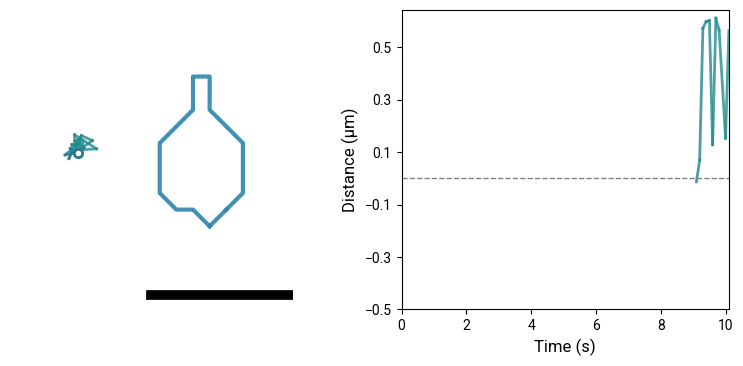

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-18_track_2132.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-18, Track ID: 2283
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-18
    ✅ 1/1 tracks interacting with 213 condensates
Length of exp_results: 2
First dwell time: 6.9, until 9.9
First time point int track_data: 69


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


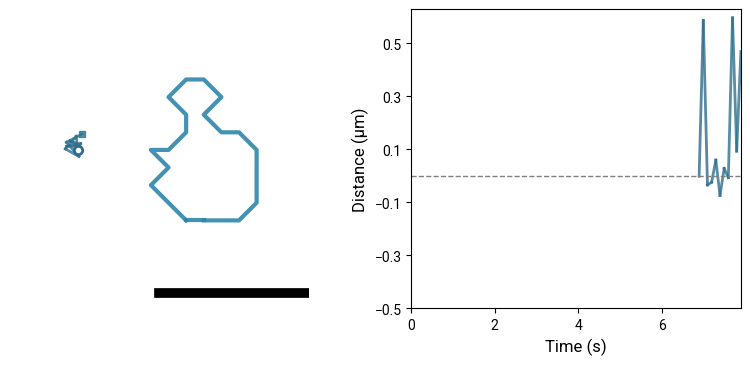

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-18_track_2283.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-18, Track ID: 3851
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-18
    ✅ 1/1 tracks interacting with 220 condensates
Length of exp_results: 2
First dwell time: 16.2, until 19.2
First time point int track_data: 162


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


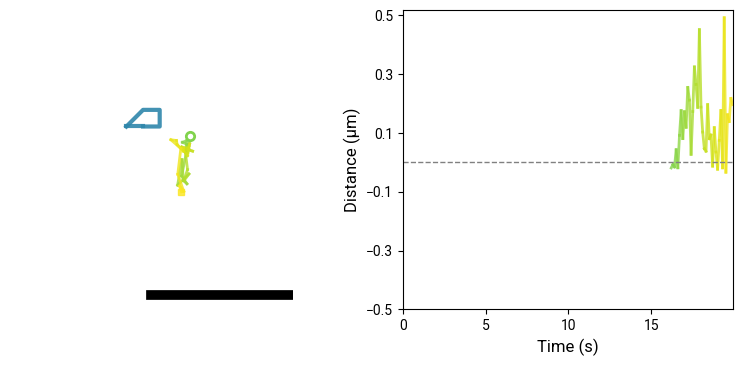

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-18_track_3851.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-18, Track ID: 4160
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-18
    ✅ 1/1 tracks interacting with 220 condensates
Length of exp_results: 2
First dwell time: 19.0, until 22.0
First time point int track_data: 190


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


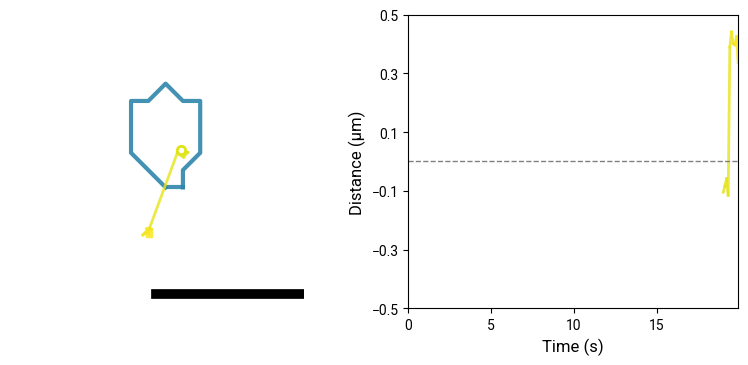

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-18_track_4160.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-22, Track ID: 103
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-22
    ✅ 1/1 tracks interacting with 589 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 200, trace_df has 173
First dwell time: 2.7, until 5.7
First time point int track_data: 0


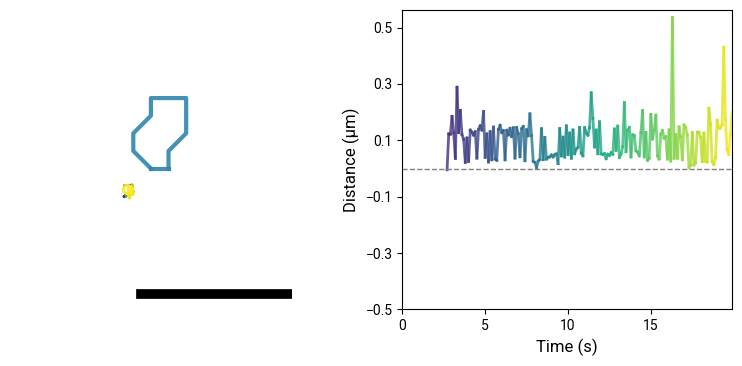

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-22_track_103.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-22, Track ID: 347
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-22
    ✅ 1/1 tracks interacting with 589 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 200, trace_df has 55
First dwell time: 14.5, until 17.5
First time point int track_data: 0


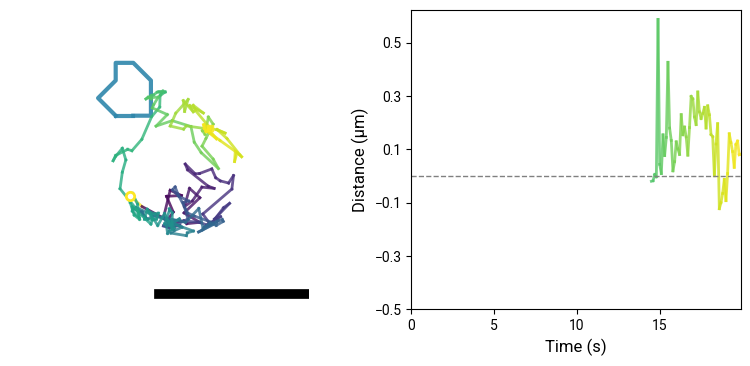

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-22_track_347.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-22, Track ID: 419
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-22
    ✅ 1/1 tracks interacting with 595 condensates
Length of exp_results: 2
⚠️ Mismatch in number of points: track_data has 36, trace_df has 6
First dwell time: 3.6, until 6.6
First time point int track_data: 6


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


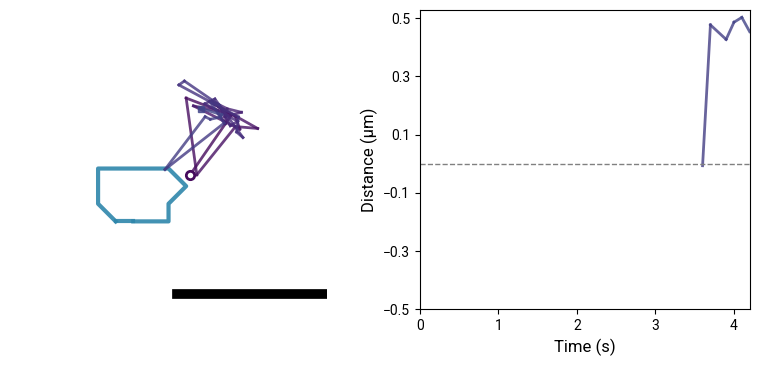

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-22_track_419.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-22, Track ID: 420
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-22
    ✅ 1/1 tracks interacting with 573 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 100, trace_df has 94
First dwell time: 0.6000000000000001, until 3.6
First time point int track_data: 0


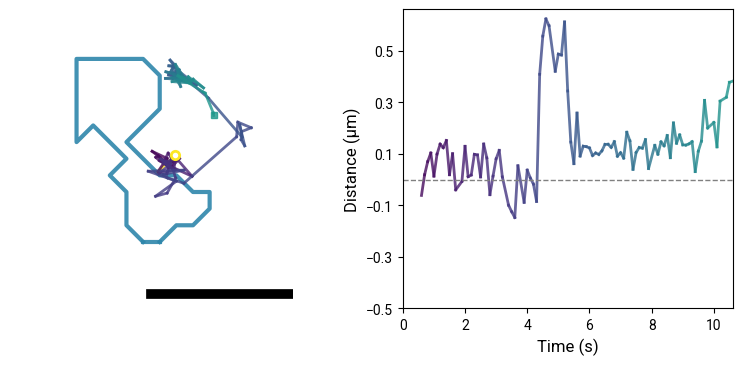

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-22_track_420.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-22, Track ID: 656
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-22
    ✅ 1/1 tracks interacting with 590 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


First dwell time: 0.5, until 3.5
First time point int track_data: 5


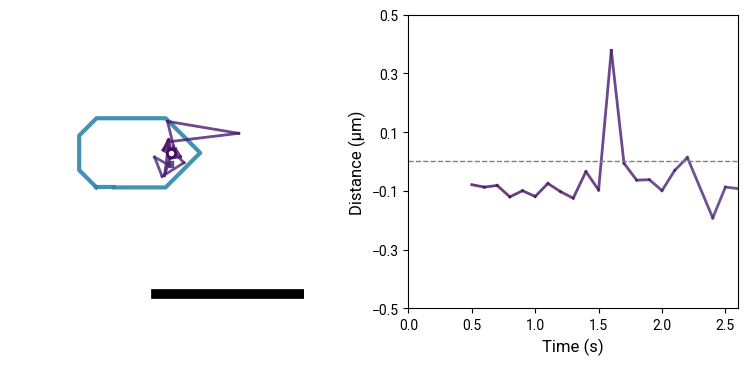

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-22_track_656.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-22, Track ID: 837
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-22
    ✅ 1/1 tracks interacting with 597 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


First dwell time: 1.0, until 4.0
First time point int track_data: 10


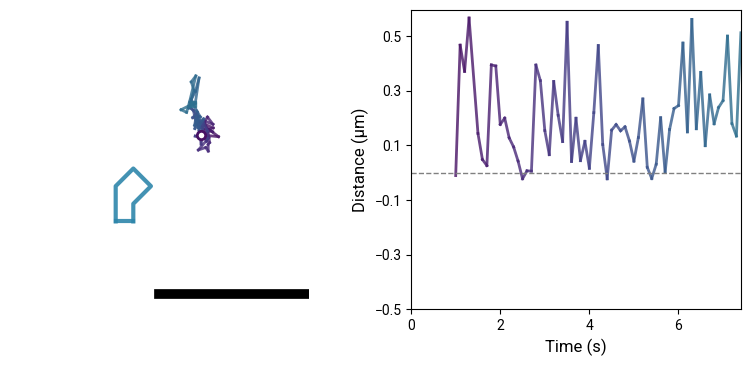

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-22_track_837.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-22, Track ID: 2403
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-22
    ✅ 1/1 tracks interacting with 599 condensates
Length of exp_results: 2
First dwell time: 4.5, until 7.5
First time point int track_data: 45


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


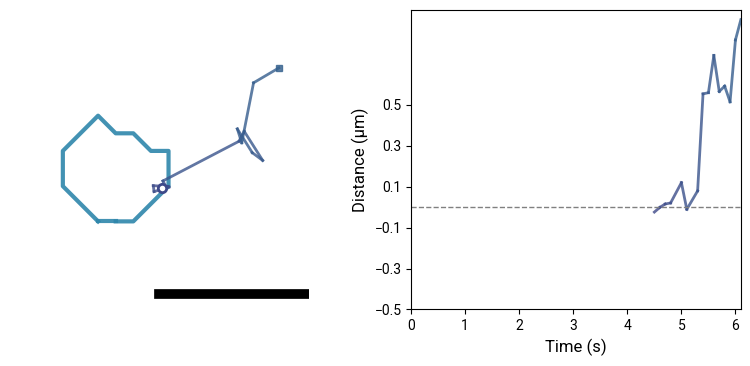

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-22_track_2403.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-22, Track ID: 2744
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-22
    ✅ 1/1 tracks interacting with 585 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


First dwell time: 6.5, until 9.5
First time point int track_data: 65


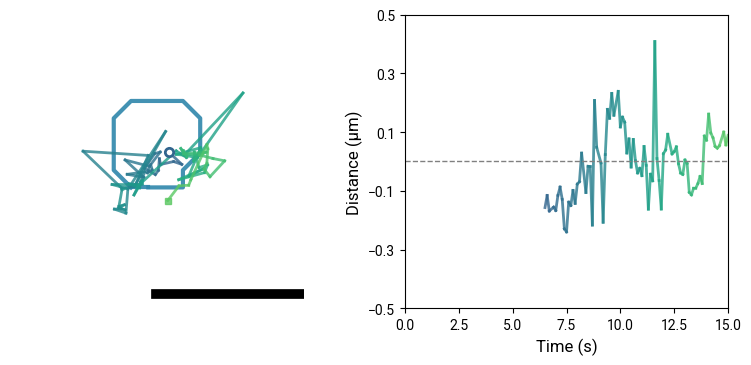

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-22_track_2744.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-22, Track ID: 4060
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-22
    ✅ 1/1 tracks interacting with 592 condensates
Length of exp_results: 2
⚠️ Mismatch in number of points: track_data has 10, trace_df has 7
First dwell time: 12.1, until 15.1
First time point int track_data: 118


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


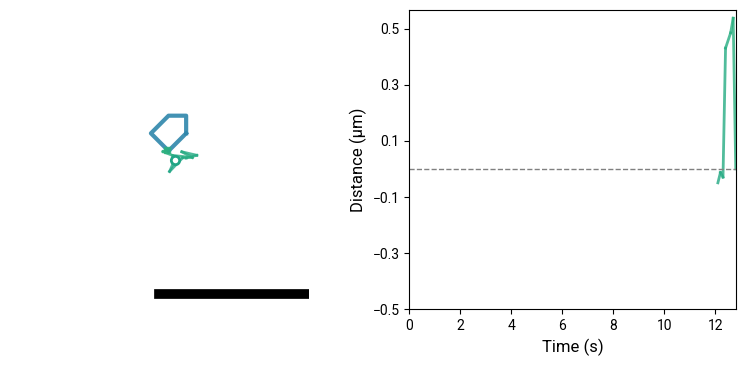

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-22_track_4060.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-22, Track ID: 4184
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-22
    ✅ 1/1 tracks interacting with 585 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 21, trace_df has 13
First dwell time: 13.8, until 16.8
First time point int track_data: 130


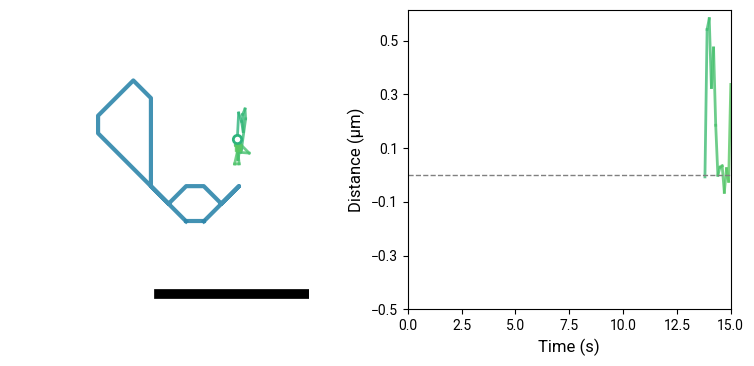

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-22_track_4184.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-2, Track ID: 477
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-2
    ✅ 1/1 tracks interacting with 713 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


First dwell time: 0.0, until 3.0
First time point int track_data: 0


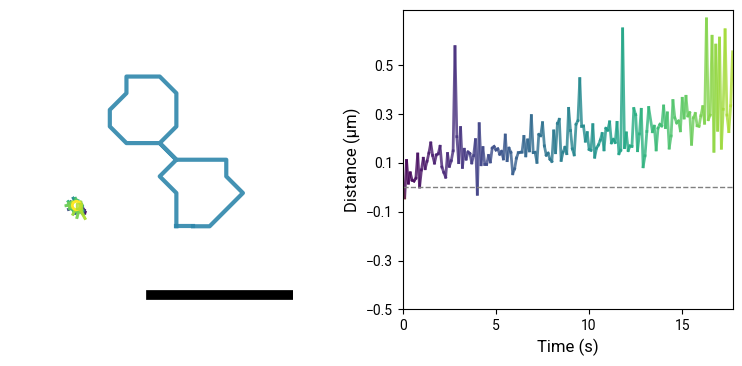

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-2_track_477.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-2, Track ID: 805
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-2
    ✅ 1/1 tracks interacting with 732 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 49, trace_df has 29
First dwell time: 2.4000000000000004, until 5.4
First time point int track_data: 4


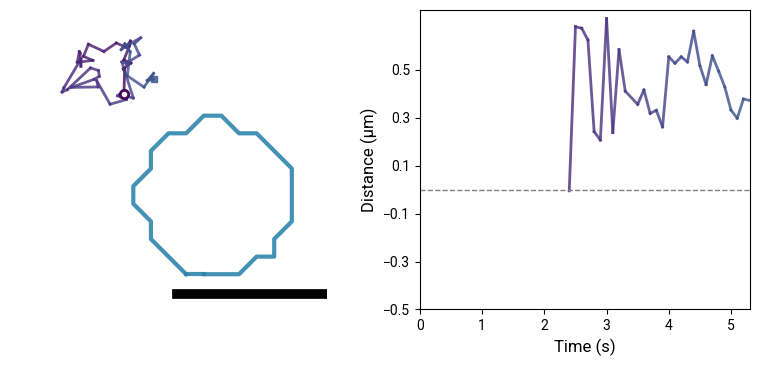

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-2_track_805.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-2, Track ID: 1350
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-2
    ✅ 1/1 tracks interacting with 734 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 25, trace_df has 24
First dwell time: 2.6, until 5.6
First time point int track_data: 25


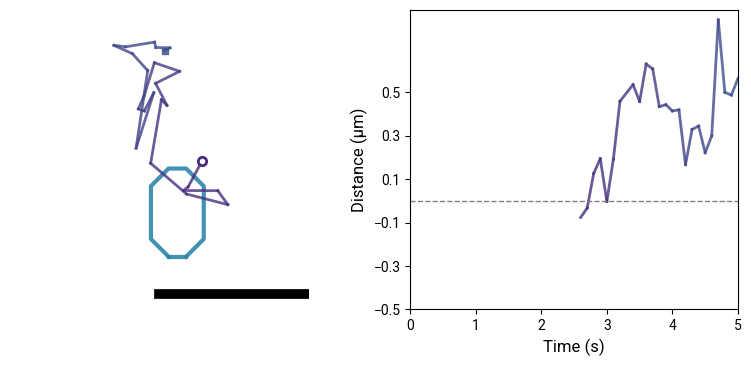

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-2_track_1350.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-2, Track ID: 1429
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-2
    ✅ 1/1 tracks interacting with 731 condensates
Length of exp_results: 2


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


⚠️ Mismatch in number of points: track_data has 95, trace_df has 73
First dwell time: 5.300000000000001, until 8.3
First time point int track_data: 31


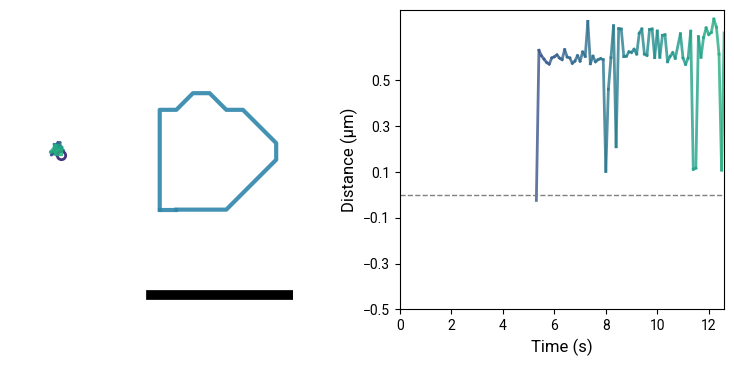

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-2_track_1429.png
  • Creating snapshot for outlier track: 20220508-FLmRNA_2x_FOV-2, Track ID: 2961
🔍 Analyzing interactions for each experiment using Shapely:
  Processing: 20220508-FLmRNA_2x_FOV-2
    ✅ 1/1 tracks interacting with 723 condensates
Length of exp_results: 2
⚠️ Mismatch in number of points: track_data has 8, trace_df has 2
First dwell time: 10.5, until 13.5
First time point int track_data: 98


/var/folders/zn/d5287x751ps3r9ryzqsyb84h0000gn/T/ipykernel_22317/2168680630.py:83: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_df.loc[:, 't_original'] = trace_df['t'].values


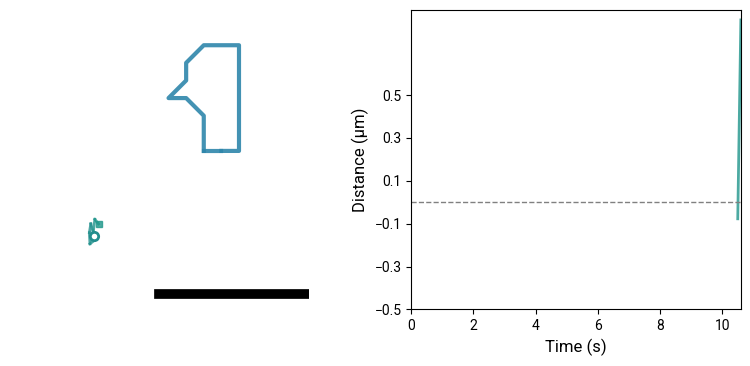

      ✅ Saved snapshot: snapshot_20220508-FLmRNA_2x_FOV-2_track_2961.png
🎉 Finished creating outlier snapshots.


In [11]:
### Added section to create a separate plot for tracks with peak detection errors
# Create the plot for tracks with peak detection errors
if not df_outlier.empty:
    all_tracks = []
    for exp in df_outlier['experiment'].unique():
        exp_data = df_outlier[df_outlier['experiment'] == exp]
        for track in exp_data['trackID'].unique():
            all_tracks.append((exp, track))

    plot_count = 0
    for i in range(0, len(all_tracks), 50):
        plot_count += 1
        chunk_of_tracks = all_tracks[i:i + 50]
        
        fig, ax = plt.subplots(figsize=(10, 7))
        
        # Get unique experiment names for this chunk for the filename
        chunk_experiments = set()

        for exp, track_id in chunk_of_tracks:
            track_data = df_outlier[(df_outlier['experiment'] == exp) & (df_outlier['trackID'] == track_id)]
            x = np.array(track_data['t'] - track_data['t_dwell'])
            y = np.array(track_data['distance_um'])
            ax.plot(x, y, alpha=0.5, linewidth=1.5, label=f"Track {track_id}")
            chunk_experiments.add(exp)

        ax.set_xlabel("Time since first dwell (s)", fontsize=12, fontweight='bold')
        ax.set_ylabel("Distance to condensate boundary (μm)", fontsize=12, fontweight='bold')
        ax.set_title(f"RNA Distance from Condensate Boundary Over Time\n(Outlier Tracks, Part {plot_count})", 
                    fontsize=14, fontweight='bold')
        ax.grid(True, linestyle='--', alpha=0.3)
        
        plt.tight_layout()

        # Create a safe filename for the plot
        error_exp_names = "_".join(sorted([str(e).replace(" ", "_").replace("/", "_").replace("\\", "_") for e in chunk_experiments]))
        
        # Make sure the outliers directory exists
        outlier_img_path = os.path.join(img_path, "outliers")
        os.makedirs(outlier_img_path, exist_ok=True)
        
        error_output_png_filename = f"outliers_{error_exp_names}_part_{plot_count}.png"
        output_png = os.path.join(outlier_img_path, error_output_png_filename)
        
        fig.savefig(output_png, dpi=300, bbox_inches='tight')
        print(f"      ✅ Saved: {error_output_png_filename}")

        plt.close()  # Close to free memory
    
    # Plot the snapshot
    # Create snapshots for outlier tracks
    snapshot_save_path = os.path.join(img_path, "outliers", "snapshots")
    os.makedirs(snapshot_save_path, exist_ok=True)

    for exp, track_id in all_tracks:
        print(f"  • Creating snapshot for outlier track: {exp}, Track ID: {track_id}")
        
        # Get the full track data from the combined dataframe
        track_df = df_tracks_combined[(df_tracks_combined['experiment'] == exp) & (df_tracks_combined['trackID'] == track_id)]
        
        # Get the condensate data for the experiment
        condensate_df = df_condensates_combined[df_condensates_combined['experiment'] == exp]
        
        # Get the outlier trace data
        trace_df = df_outlier[(df_outlier['experiment'] == exp) & (df_outlier['trackID'] == track_id)]
        
        if track_df.empty or condensate_df.empty or trace_df.empty:
            print(f"      ⚠️ Could not find all necessary data for outlier track {track_id} in {exp}. Skipping snapshot.")
            continue
            
        # Analyze interactions
        try:
            experiment_result = analyze_interactions(track_df, condensate_df, proximity_threshold=1)
        except Exception as e:
            print(f"      ❌ Error analyzing interactions for outlier track {track_id} in {exp}: {e}")
            continue

        # Create the snapshot
        try:
            safe_exp_name = exp.replace(" ", "_").replace("/", "_").replace("\\", "_")
            snapshot_filename = f"snapshot_{safe_exp_name}_track_{track_id}.png"
            save_path = os.path.join(snapshot_save_path, snapshot_filename)
            trace_df.loc[:, 't_original'] = trace_df['t'].values
            plot_trajectory_snapshots(df_tracks=track_df,
                                      exp_results=experiment_result,
                                      trace_df=trace_df,
                                      window_size_um=2,
                                      um_per_pixel=um_per_pixel,
                                      gradient_color=True,
                                      save_path=save_path)
            print(f"      ✅ Saved snapshot: {snapshot_filename}")
        except Exception as e:
            print(f"      ❌ Error creating snapshot for outlier track {track_id} in {exp}: {e}")
            
    print("🎉 Finished creating outlier snapshots.")

In [15]:
if not df_error.empty:
    all_tracks = []
    for exp in df_error['experiment'].unique():
        exp_data = df_error[df_error['experiment'] == exp]
        for track in exp_data['trackID'].unique():
            all_tracks.append((exp, track))

    plot_count = 0
    for i in range(0, len(all_tracks), 50):
        plot_count += 1
        chunk_of_tracks = all_tracks[i:i + 50]
        
        fig, ax = plt.subplots(figsize=(10, 7))
        
        # Get unique experiment names for this chunk for the filename
        chunk_experiments = set()

        for exp, track_id in chunk_of_tracks:
            track_data = df_error[(df_error['experiment'] == exp) & (df_error['trackID'] == track_id)]
            x = np.array(track_data['t'] - track_data['t_dwell'])
            y = np.array(track_data['distance_um'])
            ax.plot(x, y, alpha=0.5, linewidth=1.5, label=f"Track {track_id}")
            chunk_experiments.add(exp)

        ax.set_xlabel("Time since first dwell (s)", fontsize=12, fontweight='bold')
        ax.set_ylabel("Distance to condensate boundary (μm)", fontsize=12, fontweight='bold')
        ax.set_title(f"RNA Distance from Condensate Boundary Over Time\n(Tracks with Peak Detection Errors, Part {plot_count})", 
                    fontsize=14, fontweight='bold')
        ax.grid(True, linestyle='--', alpha=0.3)
        
        plt.tight_layout()

        # Create a safe filename for the plot
        error_exp_names = "_".join(sorted([str(e).replace(" ", "_").replace("/", "_").replace("\\", "_") for e in chunk_experiments]))
        
        # Make sure the errors directory exists
        error_img_path = os.path.join(img_path, "errors")
        os.makedirs(error_img_path, exist_ok=True)
        
        error_output_png_filename = f"peak_detection_errors_{error_exp_names}_part_{plot_count}.png"
        output_png = os.path.join(error_img_path, error_output_png_filename)
        
        fig.savefig(output_png, dpi=300, bbox_inches='tight')
        print(f"      ✅ Saved: {error_output_png_filename}")

        plt.close()  # Close to free memory

      ✅ Saved: peak_detection_errors_20220508-FLmRNA_2x_FOV-15_20220508-FLmRNA_2x_FOV-17_20220508-FLmRNA_2x_FOV-25_20220508-FLmRNA_2x_FOV-5_20220508-FLmRNA_2x_FOV-7_part_1.png
      ✅ Saved: peak_detection_errors_20220508-FLmRNA_2x_FOV-1_20220508-FLmRNA_2x_FOV-13_20220508-FLmRNA_2x_FOV-19_20220508-FLmRNA_2x_FOV-21_20220508-FLmRNA_2x_FOV-7_20220508-FLmRNA_2x_FOV-9_part_2.png
      ✅ Saved: peak_detection_errors_20220508-FLmRNA_2x_FOV_20220508-FLmRNA_2x_FOV-19_20220508-FLmRNA_2x_FOV-3_part_3.png
      ✅ Saved: peak_detection_errors_20220508-FLmRNA_2x_FOV-11_20220508-FLmRNA_2x_FOV-23_20220508-FLmRNA_2x_FOV-24_20220508-FLmRNA_2x_FOV-3_part_4.png
      ✅ Saved: peak_detection_errors_20220508-FLmRNA_2x_FOV-16_20220508-FLmRNA_2x_FOV-24_20220508-FLmRNA_2x_FOV-4_part_5.png
      ✅ Saved: peak_detection_errors_20220508-FLmRNA_2x_FOV-16_20220508-FLmRNA_2x_FOV-6_part_6.png
      ✅ Saved: peak_detection_errors_20220508-FLmRNA_2x_FOV-10_20220508-FLmRNA_2x_FOV-12_20220508-FLmRNA_2x_FOV-14_20220508-FL

In [17]:
# Save the filtered data into CSV files based on their types
experiments_list = df_filtered['experiment'].unique()
unique_exp_list = []
for exp in experiments_list:
    # Extract part before '_FOV' or '-FOV'
    if '_FOV' in exp:
        exp_str = exp.split('_FOV')[0]
    elif '-FOV' in exp:
        exp_str = exp.split('-FOV')[0]
    else:
        exp_str = exp

    unique_exp_list.append(exp_str)

unique_exp_list = list(set(unique_exp_list))

for exp in unique_exp_list:
    print(f"  • Found unique experiment: {exp}")
    # Create a filtered DataFrame for the current experiment
    df_exp = df_filtered[df_filtered['experiment'].str.contains(exp)]
     
    # Save to CSV
    print(f"    → Saving data for experiment: {exp}")
    df_exp = df_filtered[df_filtered['experiment'].str.contains(exp)]
    output_csv = os.path.join(result_path, f"{exp}.csv")

    # Check if csv already exists
    if os.path.exists(output_csv):
        print(f"    ⚠️ File already exists, skipping: {output_csv}")
    else:
        df_exp.to_csv(output_csv, index=False)
    
df_filtered.to_csv(os.path.join(result_path, f"{data_name}_filtered_rna_condensate_distances.csv"), index=False)

print(f"Number of tracks with peak detection errors: {error_count} ({error_count/len(df_plot['trackID'].unique())*100:.1f}%)")

  • Found unique experiment: 20220508-FLmRNA_2x
    → Saving data for experiment: 20220508-FLmRNA_2x
    ⚠️ File already exists, skipping: /Users/samm/Documents/Coding/github/RNA_SPT_in_cellular_condensates/result/20220508-FLmRNA_2x.csv
Number of tracks with peak detection errors: 366 (8.5%)
